In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import json
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import pickle
from collections import Counter, defaultdict
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from scipy.stats import pearsonr, spearmanr
from scipy import spatial
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns

from Feature_extraction.feature_extractor import FeatureExtractor
from Embeddings.Models.embedding_generator import EmbeddingGenerator
from Embeddings.Semantics.descriptions import get_descriptions
from Model.model import IP_SAE_MODEL
from Utils.split_strategies import ClassSplitter

In [2]:
DATASET_PATH = r"../Data/UiS4ADL/Processed/UiS4ADL_100hz.csv"
ADL_DICT_PATH = '../Data/adl_dict.json'

RESULTS_DIR = "../Results"

# Parameters
FS = 100
WINDOW_SECONDS = 4.0
OVERLAP_RATIO = 0.0
METHOD = 'temporal_frequency'

EMBEDDING_MODEL = 'all-MiniLM-L6-v2'
DESCRIPTION_TYPE = 'original_fadi'
USE_PROMPT = True

LAMBDA = 0.001
N_SEEN_CLASSES = [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
N_REPEATS = 50
RANDOM_SEED = 22
np.random.seed(RANDOM_SEED)

In [3]:
print("Loading dataset:")
data = pd.read_csv(DATASET_PATH)
print(f"Loaded dataset: {data.shape}")
print(f"Columns: {list(data.columns)}")
all_classes = sorted(np.unique(data['adl']))

Loading dataset:
Loaded dataset: (8424664, 28)
Columns: ['timestamp', 'accX[mg]', 'accY[mg]', 'accZ[mg]', 'gyroX[mdps]', 'gyroY[mdps]', 'gyroZ[mdps]', 'magnX[mG]', 'magnY[mG]', 'magnZ[mG]', 'fxQ1', 'fxQ2', 'fxQ3', 'fxQ4', 'fxYaw[deg]', 'fxPitch[deg]', 'fxRoll[deg]', 'fxGravityX[g]', 'fxGravityY[g]', 'fxGravityZ[g]', 'fxLinAccX[g]', 'fxLinAccY[g]', 'fxLinAccZ[g]', 'fxHeading[deg]', 'adl', 'session', 'subject', 'fileID']


In [4]:
with open(ADL_DICT_PATH, 'r') as f:
    adl_dict_raw = json.load(f)

In [5]:
print("Loading semantic embeddings:")
embedding_generator = EmbeddingGenerator(output_dir="../Data/Embeddings")

try:
    embeddings = embedding_generator.load_embeddings(
        model_name=EMBEDDING_MODEL,
        desc_type=DESCRIPTION_TYPE,
        use_prompt=USE_PROMPT,
        dataset='fadi'
    )
    
    activity_descriptions = get_descriptions(DESCRIPTION_TYPE)
    activity_labels = sorted(activity_descriptions.keys())
        
except Exception as e:
    print(f"Error loading embeddings: {e}")
    raise

class_to_embedding_idx = {label: idx for idx, label in enumerate(activity_labels)}

Loading semantic embeddings:
Loaded embeddings from: ../Data/Embeddings/all_minilm_l6_v2_original_fadi_prompt_fadi.npz
Model: all-MiniLM-L6-v2
Shape: (24, 384)


In [6]:
print("Extracting features...")
feature_extractor = FeatureExtractor()

sensor_cols_to_load = [col for col in data.columns if col not in
                       ['timestamp', 'adl', 'session', 'subject', 'fileID']]

X, y, fileIDs, subjects = feature_extractor.extract_features(
        data=data, method=METHOD, sensor_columns=sensor_cols_to_load,
        window_seconds=WINDOW_SECONDS, overlap_ratio=OVERLAP_RATIO, fs=FS, strategy="retain_short"
    )

Extracting features...

Extracting features: temporal_frequency
  Window: 4.0s
  Overlap: 0.0 (400 stride)
  Sampling rate: 100 Hz

Creating windows per fileID...
  Found 1445 files that are too short (30.94% of the available files)
  Created 20103 windows

Extracting features using method: temporal_frequency...
  Processing window 0/20103
                    1000/20103
                    2000/20103
                    3000/20103
                    4000/20103
                    5000/20103
                    6000/20103
                    7000/20103
                    8000/20103
                    9000/20103
                    10000/20103
                    11000/20103
                    12000/20103
                    13000/20103
                    14000/20103
                    15000/20103
                    16000/20103
                    17000/20103
                    18000/20103
                    19000/20103
                    20000/20103
  Feature shape: (20103, 27

In [7]:
print("Samples per class after windowing:")
class_counts = Counter(y)
for cls, count in sorted(class_counts.items()): # Checking class distribution
    print(f"Class {cls:>2}: {count:>6} samples")

print(f"\nMin samples: {min(class_counts.values())}")
print(f"Max samples: {max(class_counts.values())}")

Samples per class after windowing:
Class  1:    605 samples
Class  2:   1414 samples
Class  3:    539 samples
Class  4:    518 samples
Class  5:   1396 samples
Class  6:   1118 samples
Class  7:    470 samples
Class  8:    502 samples
Class  9:    425 samples
Class 10:    370 samples
Class 11:    324 samples
Class 12:    315 samples
Class 13:    262 samples
Class 14:    277 samples
Class 15:   1311 samples
Class 16:    558 samples
Class 17:   1325 samples
Class 18:    671 samples
Class 19:    298 samples
Class 20:    526 samples
Class 21:    972 samples
Class 22:   2065 samples
Class 23:   2016 samples
Class 24:   1826 samples

Min samples: 262
Max samples: 2065


In [8]:
results_dict = {
    'split_ratio': [], 
    'n_seen_classes': [], 
    'n_unseen_classes': [], 
    'accuracy_mean': [], 
    'accuracy_std': [], 
    'accuracy_all': [],
    'unseen_all': [],
    'best_acc': [],
    'worst_acc': [],
    'best_unseen_classes': [],
    'worst_unseen_classes': [],
    'best_y_test': [],
    'best_y_pred': [],
    'worst_y_test': [],
    'worst_y_pred': []}

### Run split selection experiment

In [ ]:
experiment_counter = 0
total_experiments = len(N_SEEN_CLASSES) * N_REPEATS

for seen_idx, n_seen in enumerate(N_SEEN_CLASSES):
    ratio = n_seen / len(all_classes)
    n_unseen = len(all_classes) - n_seen
    
    print(f"\nSplit {seen_idx + 1}/{len(N_SEEN_CLASSES)}: {n_seen} seen / {n_unseen} unseen ({ratio:.1%} / {1-ratio:.1%})")
    
    accuracies_for_ratio = []
    unseen_for_ratio = []
    all_y_test = []
    all_y_pred = []
    
    for repeat in range(N_REPEATS):
        experiment_counter += 1
        
        # Create new random split for each repeat
        splitter_temp = ClassSplitter(random_seed=repeat + RANDOM_SEED)
        seen_classes, unseen_classes = splitter_temp.split_random(all_classes, seen_ratio=ratio)
        
        if len(unseen_classes) == 0:
            print(f" Repeat {repeat+1}/{N_REPEATS}: Skipped (no unseen classes) [{experiment_counter}/{total_experiments}]")
            continue
        
        # Create train/test split
        seen_mask = np.isin(y, seen_classes)
        unseen_mask = np.isin(y, unseen_classes)
        
        X_train = X[seen_mask]
        y_train = np.array(y)[seen_mask]
        X_test = X[unseen_mask]
        y_test = np.array(y)[unseen_mask]
        
        # Prepare embeddings
        seen_class_indices = [class_to_embedding_idx[cls] for cls in seen_classes]
        unseen_class_indices = [class_to_embedding_idx[cls] for cls in unseen_classes]
        seen_embeddings = embeddings[seen_class_indices]
        unseen_embeddings = embeddings[unseen_class_indices]
        
        # Create indexed embeddings for IP_SAE_MODEL
        max_class_id = max(all_classes)
        all_embeddings_indexed = np.zeros((max_class_id + 1, embeddings.shape[1]))
        for cls, idx in class_to_embedding_idx.items():
            if cls in all_classes:
                all_embeddings_indexed[cls] = embeddings[idx]

        model = IP_SAE_MODEL(lambda_reg=LAMBDA, scale_features=True)
        model.fit(X_train, y_train, all_embeddings_indexed, verbose=0)
        
        # Predict
        y_pred = model.predict_zsl(X_test, unseen_embeddings, unseen_classes, n_runs=35)
         
        # Store predictions for later analysis
        all_y_test.append(y_test.copy())
        all_y_pred.append(y_pred.copy())
        
        # Evaluate
        acc = balanced_accuracy_score(y_test, y_pred)
        accuracies_for_ratio.append(acc)
        unseen_for_ratio.append(unseen_classes.copy())
        
        print(f" Repeat {repeat+1}/{N_REPEATS}: {len(seen_classes)} seen, {len(unseen_classes)} unseen → Acc: {acc:.2%} [{experiment_counter}/{total_experiments}]")
    
    # Store aggregated results
    if len(accuracies_for_ratio) > 0:
        idx_best = np.argmax(accuracies_for_ratio)
        idx_worst = np.argmin(accuracies_for_ratio)
        best_acc = accuracies_for_ratio[idx_best]
        worst_acc = accuracies_for_ratio[idx_worst]
        best_unseen = unseen_for_ratio[idx_best]
        worst_unseen = unseen_for_ratio[idx_worst]
        
        results_dict['split_ratio'].append(ratio)
        results_dict['n_seen_classes'].append(n_seen)
        results_dict['n_unseen_classes'].append(n_unseen)
        results_dict['accuracy_mean'].append(np.mean(accuracies_for_ratio))
        results_dict['accuracy_std'].append(np.std(accuracies_for_ratio))
        results_dict['accuracy_all'].append(accuracies_for_ratio)
        results_dict['unseen_all'].append(unseen_for_ratio)
        results_dict['best_acc'].append(best_acc)
        results_dict['worst_acc'].append(worst_acc)
        results_dict['best_unseen_classes'].append(best_unseen)
        results_dict['worst_unseen_classes'].append(worst_unseen)
        results_dict['best_y_test'].append(all_y_test[idx_best])
        results_dict['best_y_pred'].append(all_y_pred[idx_best])
        results_dict['worst_y_test'].append(all_y_test[idx_worst])
        results_dict['worst_y_pred'].append(all_y_pred[idx_worst])
        
        print(f" Stored: Mean = {np.mean(accuracies_for_ratio):.2%} ± {np.std(accuracies_for_ratio):.2%}")

print(f"{len(results_dict['split_ratio'])} data points collected")


Split 1/13: 9 seen / 15 unseen (37.5% / 62.5%)
 Repeat 1/50: 9 seen, 15 unseen → Acc: 15.24% [1/650]
 Repeat 2/50: 9 seen, 15 unseen → Acc: 10.64% [2/650]
 Repeat 3/50: 9 seen, 15 unseen → Acc: 17.24% [3/650]
 Repeat 4/50: 9 seen, 15 unseen → Acc: 17.34% [4/650]
 Repeat 5/50: 9 seen, 15 unseen → Acc: 21.98% [5/650]
 Repeat 6/50: 9 seen, 15 unseen → Acc: 19.32% [6/650]
 Repeat 7/50: 9 seen, 15 unseen → Acc: 20.31% [7/650]
 Repeat 8/50: 9 seen, 15 unseen → Acc: 11.89% [8/650]
 Repeat 9/50: 9 seen, 15 unseen → Acc: 18.41% [9/650]
 Repeat 10/50: 9 seen, 15 unseen → Acc: 13.81% [10/650]
 Repeat 11/50: 9 seen, 15 unseen → Acc: 11.87% [11/650]
 Repeat 12/50: 9 seen, 15 unseen → Acc: 14.42% [12/650]
 Repeat 13/50: 9 seen, 15 unseen → Acc: 14.96% [13/650]
 Repeat 14/50: 9 seen, 15 unseen → Acc: 11.95% [14/650]
 Repeat 15/50: 9 seen, 15 unseen → Acc: 13.32% [15/650]
 Repeat 16/50: 9 seen, 15 unseen → Acc: 17.62% [16/650]
 Repeat 17/50: 9 seen, 15 unseen → Acc: 16.67% [17/650]
 Repeat 18/50: 9 s

In [11]:
results_dict

{'split_ratio': [0.375,
  0.4166666666666667,
  0.4583333333333333,
  0.5,
  0.5416666666666666,
  0.5833333333333334,
  0.625,
  0.6666666666666666,
  0.7083333333333334,
  0.75,
  0.7916666666666666,
  0.8333333333333334,
  0.875],
 'n_seen_classes': [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21],
 'n_unseen_classes': [15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3],
 'accuracy_mean': [0.16377673572577617,
  0.17440763987245703,
  0.19426987930043293,
  0.20760358815357452,
  0.23204838405099185,
  0.26150618308256945,
  0.26501921302629305,
  0.2970598943521283,
  0.3269450539524399,
  0.37416128008861427,
  0.410590463213546,
  0.4878944350416009,
  0.5608152367850051],
 'accuracy_std': [0.041889018416040986,
  0.04350612350950947,
  0.04833135351529954,
  0.054754368214695474,
  0.05428693807857614,
  0.05770048890070815,
  0.05864441564726906,
  0.07176182683977171,
  0.07632588361158549,
  0.08217524935997175,
  0.08664355821971588,
  0.11441087393372727,
  0.13283377868979265

In [ ]:
# Save results
results_file = RESULTS_DIR + f"/Others/Split_Protocol/experimental_baseline_results.pkl"
with open(results_file, "wb") as f:
    pickle.dump(results_dict, f)

metadata = {
    "FS": FS,
    "WINDOW_SECONDS": WINDOW_SECONDS,
    "OVERLAP_RATIO": OVERLAP_RATIO,
    "METHOD": METHOD,
    "EMBEDDING_MODEL": EMBEDDING_MODEL,
    "DESCRIPTION_TYPE": DESCRIPTION_TYPE,
    "USE_PROMPT": USE_PROMPT,
    "LAMBDA": LAMBDA,
    "N_SEEN_CLASSES": N_SEEN_CLASSES,
    "N_REPEATS": N_REPEATS,
    "RANDOM_SEED": RANDOM_SEED
}

metadata_file = RESULTS_DIR + f"/Others/Split_Protocol/metadata.json"
with open(metadata_file, "w") as f:
    json.dump(metadata, f, indent=4)

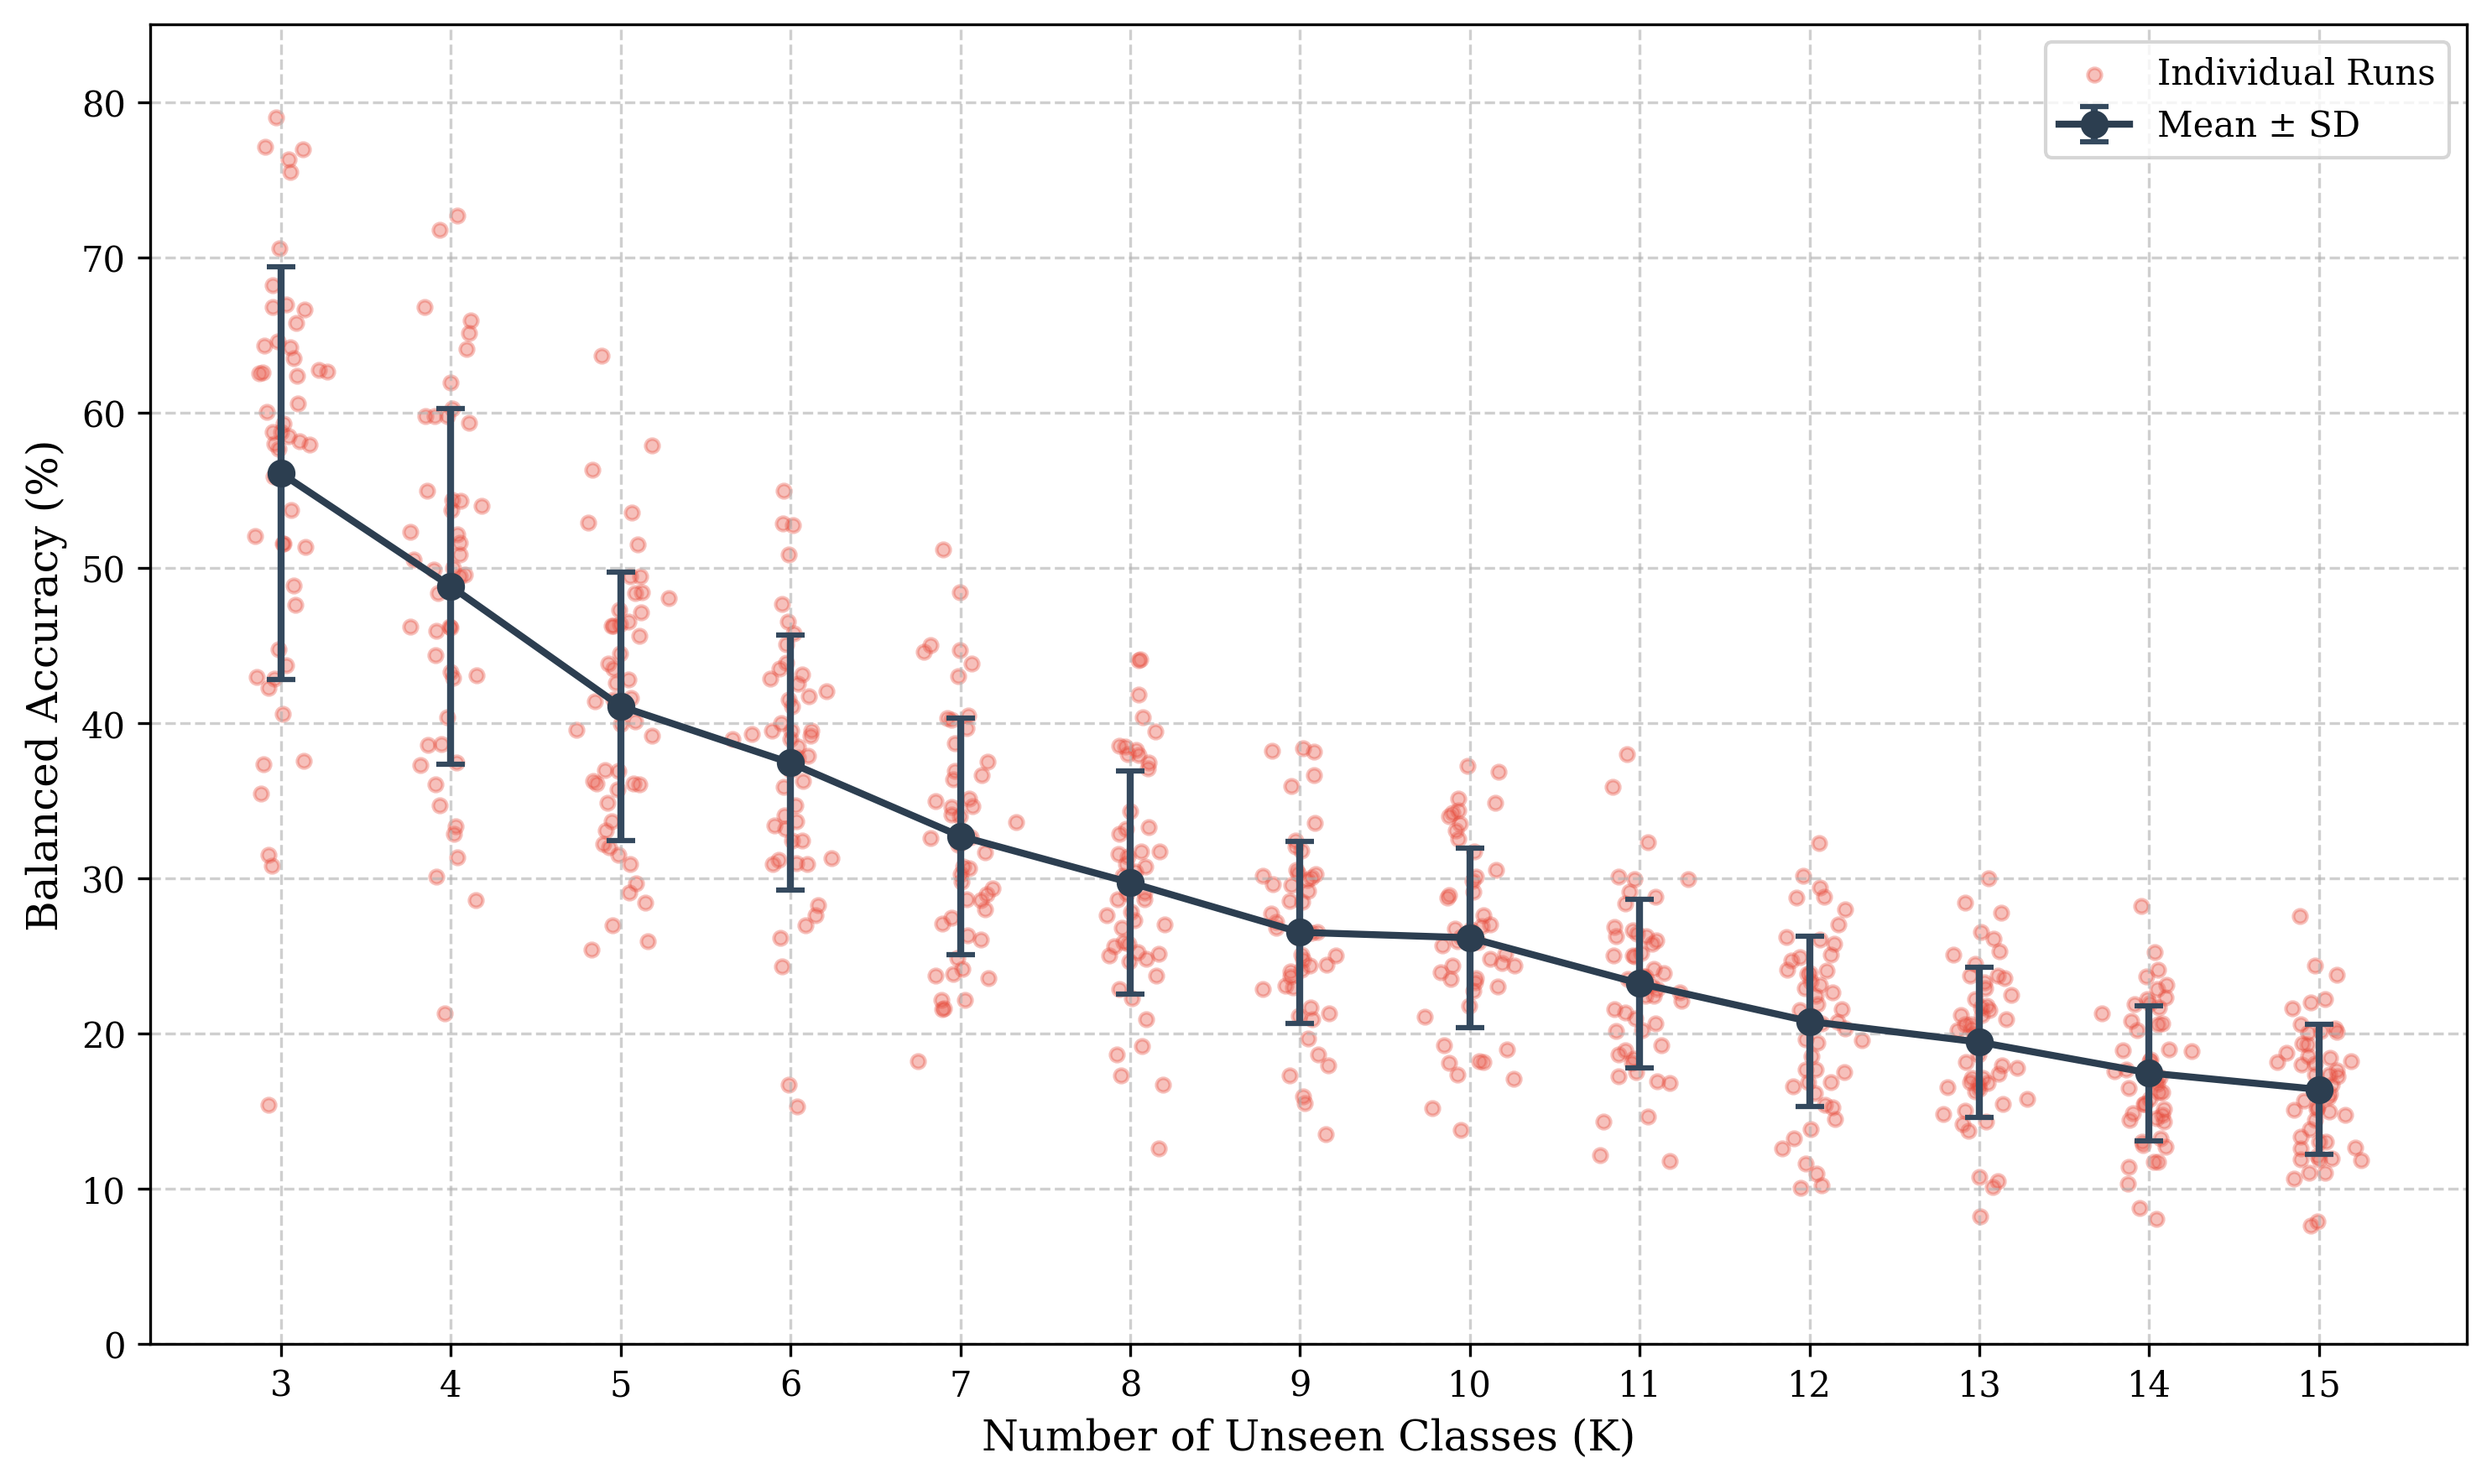

In [12]:
# Plot how ZSL performance changes as the number of unseen classes increases, and how variable it is across random splits

means = np.array(results_dict['accuracy_mean']) * 100
stds = np.array(results_dict['accuracy_std']) * 100

plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Plot individual runs with slight horizontal jitter for clarity
for i, (k, runs) in enumerate(zip(results_dict['n_unseen_classes'], results_dict['accuracy_all'])):
    jitter = np.random.normal(0, 0.1, len(runs))
    ax.scatter(k + jitter, np.array(runs) * 100, 
               alpha=0.35, color='#e74c3c', s=15, label='Individual Runs' if i == 0 else "")

# Plot Mean line with error bars
ax.errorbar(results_dict['n_unseen_classes'], means, yerr=stds, 
            fmt='o-', color='#2c3e50', linewidth=2, markersize=7, 
            capsize=4, capthick=1.5, ecolor='#34495e', label='Mean ± SD')

# Formatting
ax.set_xlabel('Number of Unseen Classes (K)', fontsize=12)
ax.set_ylabel('Balanced Accuracy (%)', fontsize=12)

# Axis limits and grid
ax.set_xticks(results_dict['n_unseen_classes'])
ax.set_ylim(0, 85)
ax.grid(True, linestyle='--', alpha=0.6)

ax.legend(loc='upper right', frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/Figures/Figure_5_1_Stability_Analysis_new.pdf", bbox_inches='tight')
plt.show()

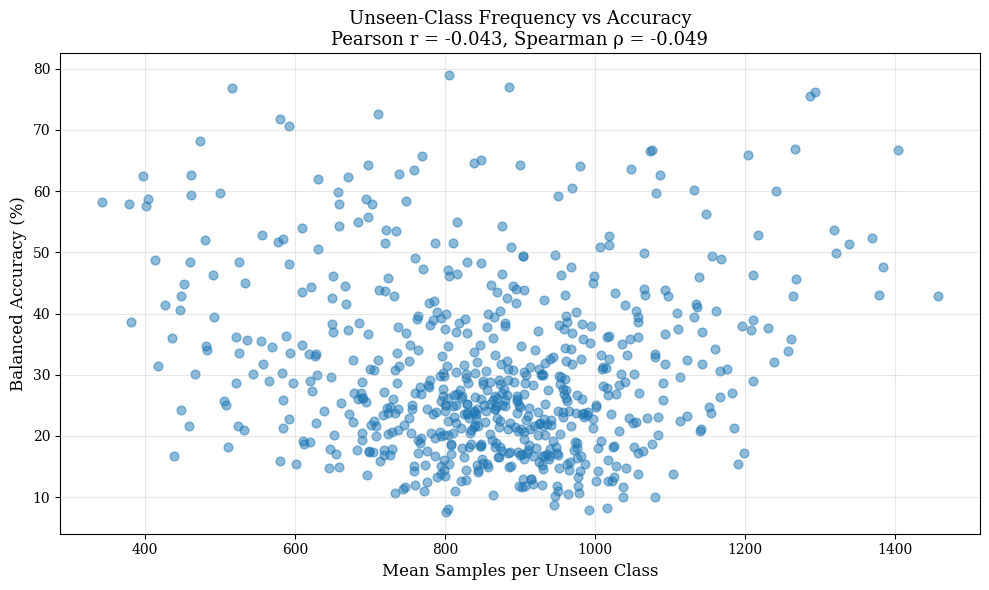

In [13]:
# Check if balanced accuracy tend to be higher when the unseen classes have higher average sample counts (across runs)
mean_unseen_counts = []
min_unseen_counts = []
total_unseen_counts = []
accuracies = []
n_unseen_list = []

for split_idx in range(len(results_dict['n_unseen_classes'])):
    for run_idx, unseen_classes in enumerate(results_dict['unseen_all'][split_idx]):
        counts = [class_counts[cls] for cls in unseen_classes]
        acc = results_dict['accuracy_all'][split_idx][run_idx]

        mean_unseen_counts.append(np.mean(counts))
        min_unseen_counts.append(np.min(counts))
        total_unseen_counts.append(np.sum(counts))
        n_unseen_list.append(len(unseen_classes))
        accuracies.append(acc)

pearson_mean, _ = pearsonr(mean_unseen_counts, accuracies)
spearman_mean, _ = spearmanr(mean_unseen_counts, accuracies)
accuracies_pct = np.array(accuracies) * 100

plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(mean_unseen_counts, accuracies_pct, alpha=0.5, s=40)
ax.set_xlabel('Mean Samples per Unseen Class', fontsize=12)
ax.set_ylabel('Balanced Accuracy (%)', fontsize=12)
ax.set_title(
    f'Unseen-Class Frequency vs Accuracy\n'
    f'Pearson r = {pearson_mean:.3f}, Spearman ρ = {spearman_mean:.3f}',
    fontsize=13
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Divergence method: E[acc | c unseen] - E[acc | c seen]
# Computed within each unseen split size (K) and averaged across K

class_divergence_per_split = defaultdict(list)

for split_idx in range(len(results_dict['n_unseen_classes'])):
    accuracies = results_dict['accuracy_all'][split_idx]
    unseen_sets = results_dict['unseen_all'][split_idx]
    
    # For this split size, collect accuracies for each class
    unseen_accs_this_n = defaultdict(list)  # Accuracies when class is unseen
    seen_accs_this_n = defaultdict(list)     # Accuracies when class is seen
    
    for run_idx, unseen_set in enumerate(unseen_sets):
        acc = accuracies[run_idx]
        seen_set = set(all_classes) - set(unseen_set)
        
        # Record this accuracy for all classes in their respective groups
        for cls in unseen_set:
            unseen_accs_this_n[cls].append(acc)
        for cls in seen_set:
            seen_accs_this_n[cls].append(acc)
    
    # Calculate divergence for this split size
    for cls in all_classes:
        if cls in unseen_accs_this_n and cls in seen_accs_this_n:
            mean_when_unseen = np.mean(unseen_accs_this_n[cls])
            mean_when_seen = np.mean(seen_accs_this_n[cls])
            divergence = mean_when_unseen - mean_when_seen
            class_divergence_per_split[cls].append(divergence)

# Average divergence across all split sizes
divergence = {}
for cls in all_classes:
    if cls in class_divergence_per_split and len(class_divergence_per_split[cls]) > 0:
        divergence[cls] = np.mean(class_divergence_per_split[cls])
    else:
        divergence[cls] = 0

# Sort by divergence
sorted_divergence = sorted(divergence.items(), key=lambda x: x[1], reverse=True)


print(f"DIVERGENCE RANKING")

for rank, (cls, div) in enumerate(sorted_divergence, 1):
    samples = class_counts[cls]
    activity = adl_dict_raw.get(str(cls), "Unknown")[:18]
    
    
    print(f"{rank:>2}. Class {cls:>2} ({activity:<18}): {div*100:>7.2f}  |  {samples:>4} samples")

ranking = [cls for cls, _ in sorted_divergence]
print(f"\nRanking list {ranking}")

DIVERGENCE RANKING
 1. Class 17 (type on keyboard  ):    4.02  |  1325 samples
 2. Class 14 (stand up          ):    1.74  |   277 samples
 3. Class 11 (put on glasses    ):    1.56  |   324 samples
 4. Class  9 (put on shoe       ):    1.45  |   425 samples
 5. Class 24 (washing dishes    ):    1.35  |  1826 samples
 6. Class  5 (brush teeth       ):    1.26  |  1396 samples
 7. Class  7 (take off jacket   ):    1.15  |   470 samples
 8. Class 12 (take off glasses  ):    1.06  |   315 samples
 9. Class 10 (take off shoe     ):    0.68  |   370 samples
10. Class  8 (put on jacket     ):    0.53  |   502 samples
11. Class  6 (brush hair        ):    0.46  |  1118 samples
12. Class 21 (washing hands     ):    0.45  |   972 samples
13. Class 23 (ironing           ):    0.39  |  2016 samples
14. Class 20 (blow nose         ):    0.12  |   526 samples
15. Class 22 (dusting           ):   -0.00  |  2065 samples
16. Class 15 (writing           ):   -0.35  |  1311 samples
17. Class 13 (sit dow

In [16]:
K = 6 # Number of classes to highlight as most divergent
K_min = 3
K_max = 12 # 50% unseen classes

k_vals = list(range(K_min, K_max+1))

In [17]:
idx = results_dict['n_unseen_classes'].index(K)
acc_list = results_dict['accuracy_all'][idx]

mean_val = np.mean(acc_list) * 100
std_val = np.std(acc_list) * 100
min_val = np.min(acc_list) * 100
max_val = np.max(acc_list) * 100

print(f"Results for K={K} (experimental baseline:)")
print(f"{'-'*45}")
print(f"Mean: {mean_val:.2f}%")
print(f"SD:   {std_val:.2f} pp")
print(f"Min:  {min_val:.2f}%")
print(f"Max:  {max_val:.2f}%")

Results for K=6 (experimental baseline:)
---------------------------------------------
Mean: 37.42%
SD:   8.22 pp
Min:  15.26%
Max:  54.96%


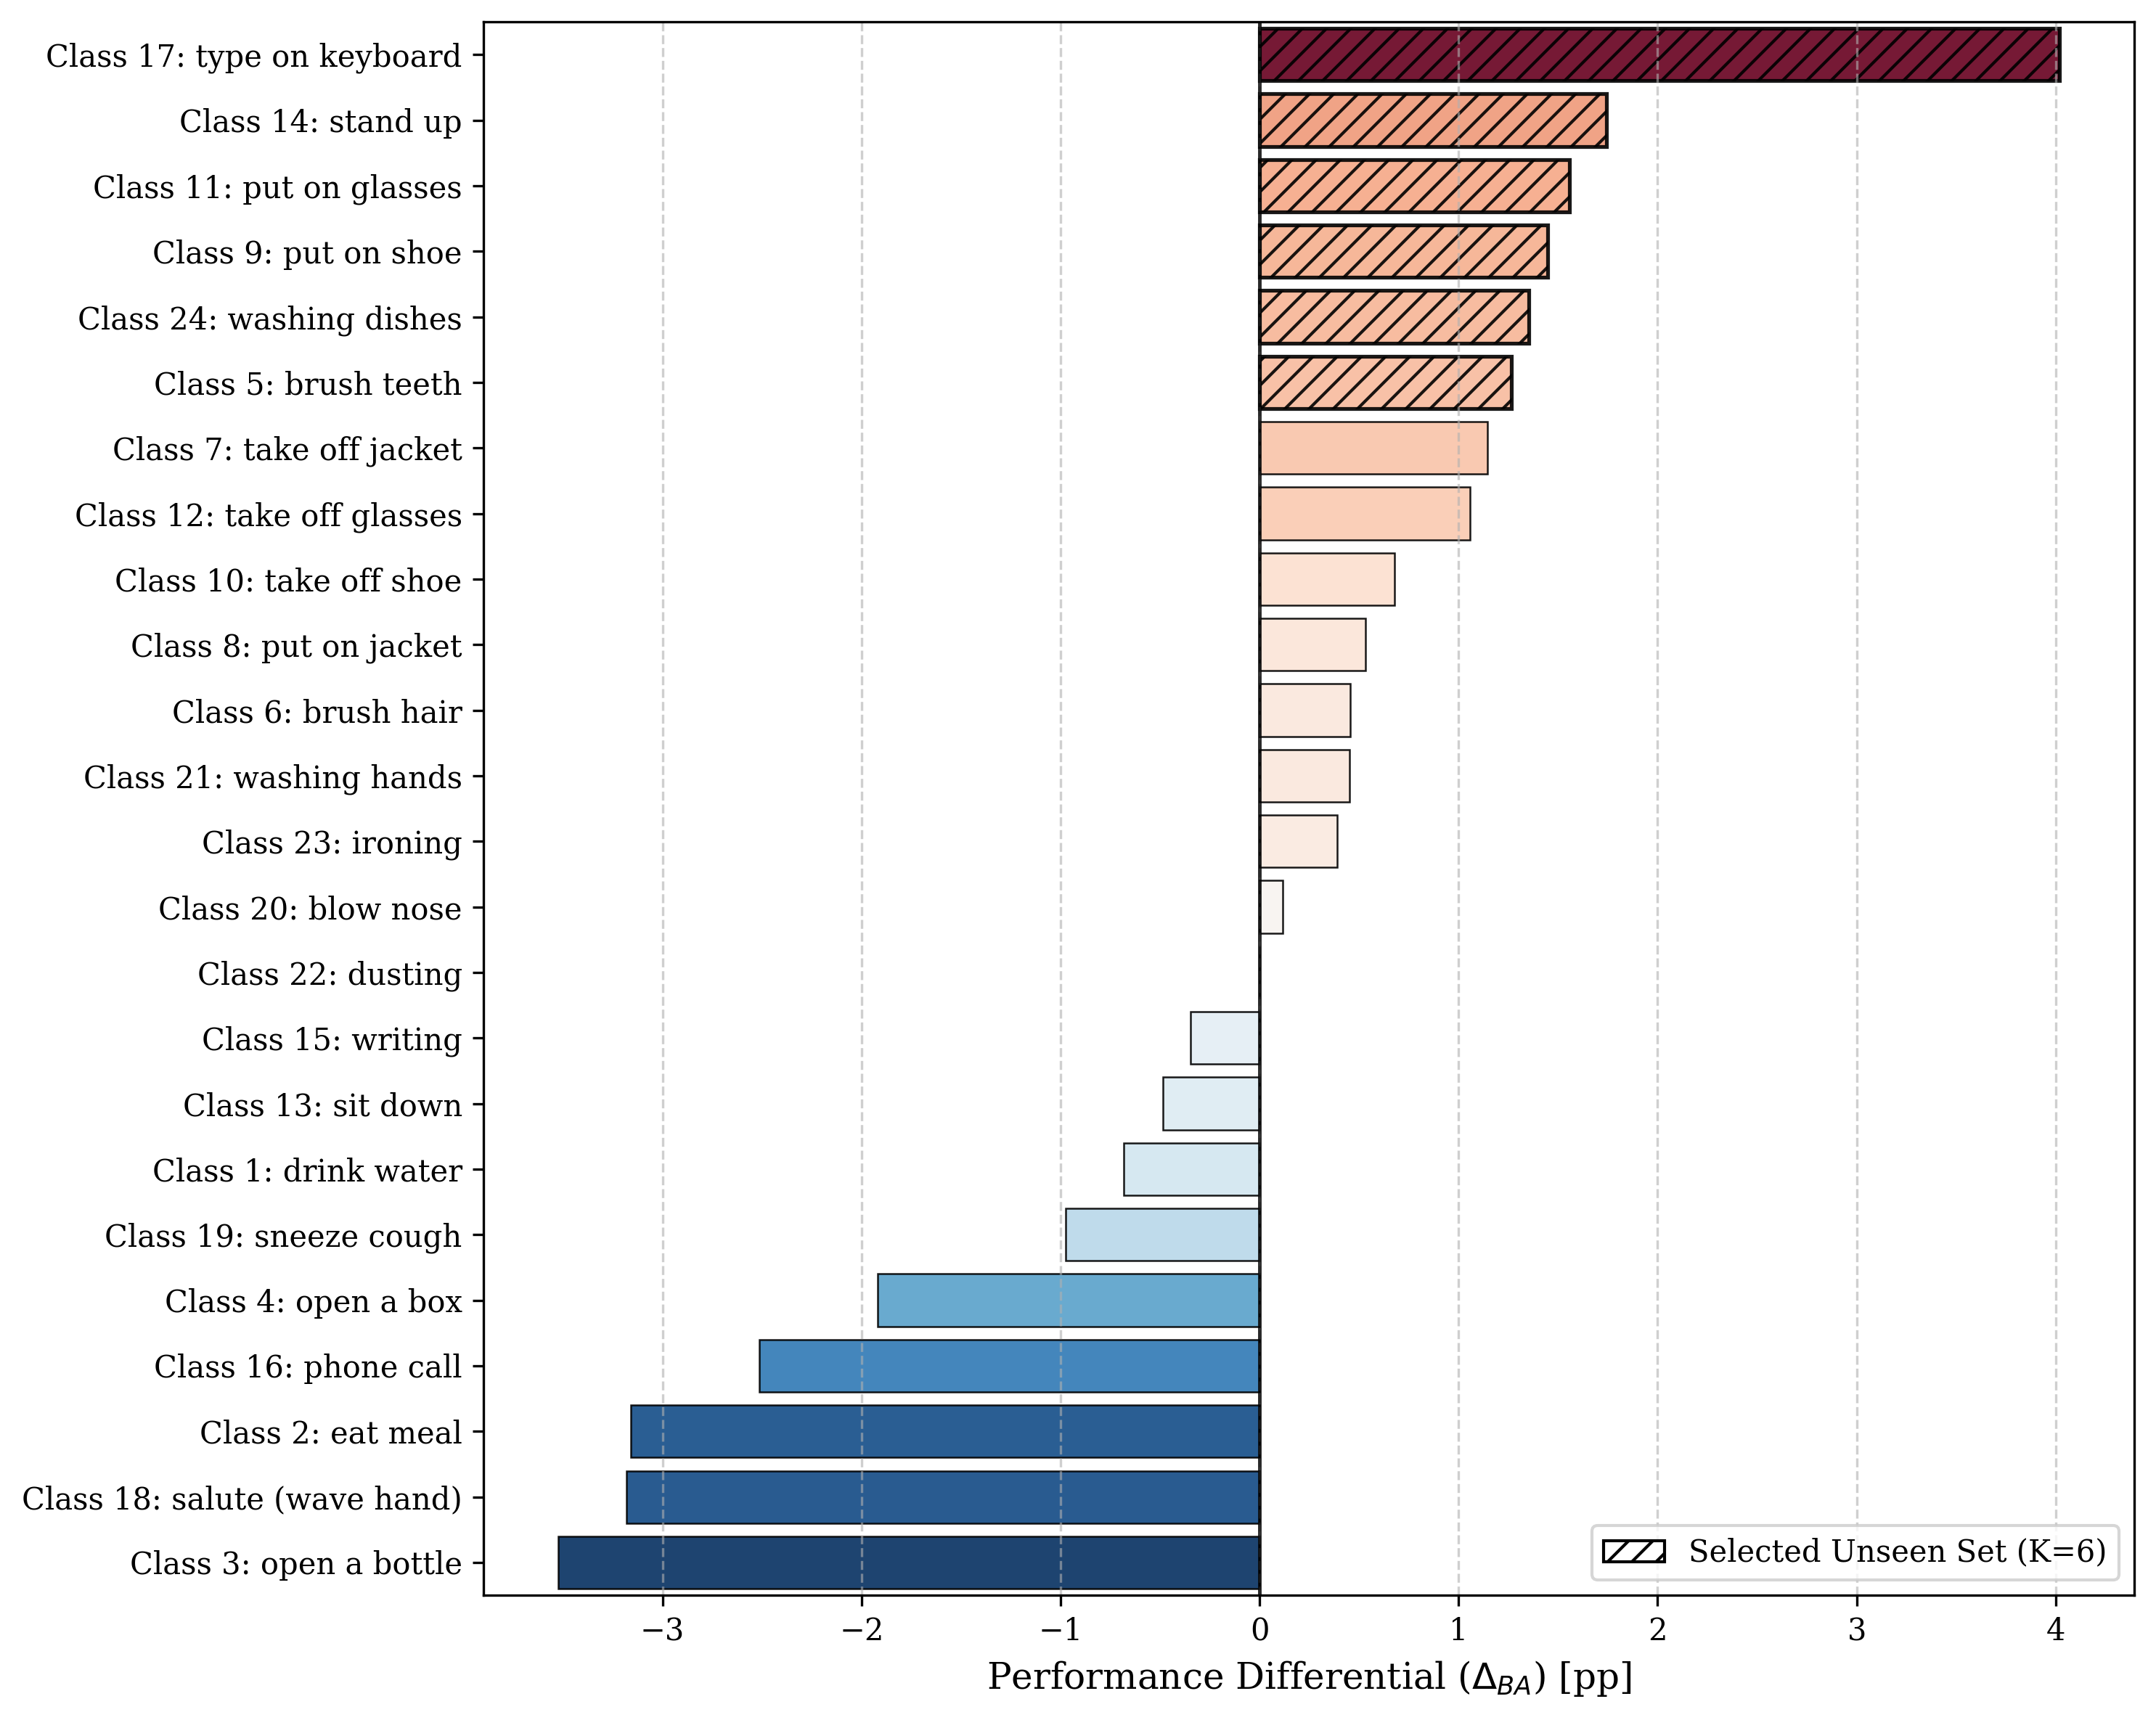

In [18]:
div_values = [divergence[cls] * 100 for cls in ranking]
labels = [f"Class {cls}: {adl_dict_raw.get(str(cls), 'Unknown')}" for cls in ranking]

plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

cmap = cm.get_cmap('RdBu_r')
# Lock the neutral center exactly to 0.0
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=min(div_values), vmax=max(div_values))
bar_colors = [cmap(norm(v)) for v in div_values]

bars = ax.barh(range(len(ranking)), div_values, color=bar_colors, 
               edgecolor='black', linewidth=0.6, alpha=0.9)

for i in range(K):
    bars[i].set_hatch('///') # Diagonal lines
    bars[i].set_edgecolor('black')
    bars[i].set_linewidth(1.25)

# Add a legend entry for the selection
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='white', edgecolor='black', hatch='///',
                         label=f'Selected Unseen Set (K={K})')]
ax.legend(handles=legend_elements, loc='lower right', frameon=True)

ax.set_yticks(range(len(ranking)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_ylim(len(ranking) - 0.5, -0.5) 
ax.set_xlabel('Performance Differential ($\Delta_{BA}$) [pp]', fontsize=12)

ax.axvline(x=0, color='black', linestyle='-', linewidth=1.2, alpha=0.8)
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.margins(x=0.05) 

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/Figures/Figure_5_2_Divergence_Ranking_new.pdf", bbox_inches='tight')
plt.show()

In [19]:
# Check whether class ranking is influenced by class frequency
class_ids = [cls for cls, _ in sorted_divergence]
div_values = [divergence[cls] for cls in class_ids]
sample_counts = [class_counts[cls] for cls in class_ids]

corr, p_val = spearmanr(sample_counts, div_values)

print(f"Spearman Rho (ρ): {corr:.3f}")
print(f"P-value:           {p_val:.3f}")

Spearman Rho (ρ): -0.132
P-value:           0.538


In [20]:
print(ranking)

[17, 14, 11, 9, 24, 5, 7, 12, 10, 8, 6, 21, 23, 20, 22, 15, 13, 1, 19, 4, 16, 2, 18, 3]


### Split evaluation experiments

In [21]:
# Get baselines from previous experiment data)
experiment_baselines = {}
for k in k_vals:
    # Find the index where n_unseen matches K
    idx = results_dict['n_unseen_classes'].index(k)
    experiment_baselines[k] = results_dict['accuracy_mean'][idx]
    
# Theoretical random guessing (1/K)
random_guessing = {k: round(1.0 / k, 3) for k in k_vals}

In [22]:
# Run experiment for each K of unseen classes, using the top-K from the divergence ranking
experiment_results = {}
confusion_matrices = {}

header = f"{'K':<2} | {'Observed':<8} | {'Exp. Baseline':<13} | {'Random Guessing':<15} | {'Obs. vs. Exp.':<13} | {'Obs. vs. Guess':<13}"
print(header)
print(f"{'-'*4}-{'-'*14}-{'-'*14}-{'-'*12}-{'-'*17}-{'-'*15}")

for n_unseen in k_vals:
    unseen_classes = ranking[:n_unseen]
    seen_classes = [cls for cls in all_classes if cls not in unseen_classes]
    
    seen_mask = np.isin(y, seen_classes)
    unseen_mask = np.isin(y, unseen_classes)
    X_train, y_train = X[seen_mask], np.array(y)[seen_mask]
    X_test, y_test = X[unseen_mask], np.array(y)[unseen_mask]
    
    unseen_indices = [class_to_embedding_idx[cls] for cls in unseen_classes]
    
    all_embeddings_indexed = np.zeros((max(all_classes) + 1, embeddings.shape[1]))
    for cls, idx in class_to_embedding_idx.items():
        if cls in all_classes:
            all_embeddings_indexed[cls] = embeddings[idx]
    
    model = IP_SAE_MODEL(lambda_reg=LAMBDA, scale_features=True)
    model.fit(X_train, y_train, all_embeddings_indexed, verbose=0)
    y_pred = model.predict_zsl(X_test, embeddings[unseen_indices], unseen_classes, n_runs=35)
    
    acc = balanced_accuracy_score(y_test, y_pred)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=unseen_classes)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    class_recalls = {}
    for i, cls in enumerate(unseen_classes):
        class_recall = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
        samples = cm[i].sum()
        class_recalls[cls] = {
            'recall': class_recall,
            'samples': samples,
            'divergence': divergence[cls]
        }
    
    # Store results
    experiment_results[n_unseen] = {
        'unseen': unseen_classes,
        'seen': seen_classes,
        'accuracy': acc,
        'n_test': len(y_test),
        'class_recalls': class_recalls,
        'experiment_baseline': experiment_baselines[n_unseen],
        'random_guessing': random_guessing[n_unseen]
    }
    
    confusion_matrices[n_unseen] = {
        'cm': cm,
        'cm_normalized': cm_normalized,
        'unseen_classes': unseen_classes
    }
    
    exp_base = experiment_baselines[n_unseen]
    rand_guess = random_guessing[n_unseen]
    obs_vs_exp = (acc - exp_base) * 100
    obs_vs_guess = (acc - rand_guess) * 100
    
    print(f"{n_unseen:<2} | "
          f"{acc:>8.2%} | "
          f"{exp_base:>12.2%} | "
          f"{rand_guess:>15.2%} | "
          f"{'+' if obs_vs_exp > 0 else '':>8}{obs_vs_exp:>6.2f} | "
          f"{'+' if obs_vs_guess > 0 else '':>8}{obs_vs_guess:>6.2f}")

K  | Observed | Exp. Baseline | Random Guessing | Obs. vs. Exp. | Obs. vs. Guess
---------------------------------------------------------------------------------
3  |   85.39% |       56.08% |          33.30% |        + 29.30 |        + 52.09
4  |   65.38% |       48.79% |          25.00% |        + 16.59 |        + 40.38
5  |   67.25% |       41.06% |          20.00% |        + 26.19 |        + 47.25
6  |   71.34% |       37.42% |          16.70% |        + 33.93 |        + 54.64
7  |   57.16% |       32.69% |          14.30% |        + 24.46 |        + 42.86
8  |   47.32% |       29.71% |          12.50% |        + 17.61 |        + 34.82
9  |   38.86% |       26.50% |          11.10% |        + 12.36 |        + 27.76
10 |   25.92% |       26.15% |          10.00% |          -0.23 |        + 15.92
11 |   23.17% |       23.20% |           9.10% |          -0.04 |        + 14.07
12 |   18.00% |       20.76% |           8.30% |          -2.76 |        +  9.70


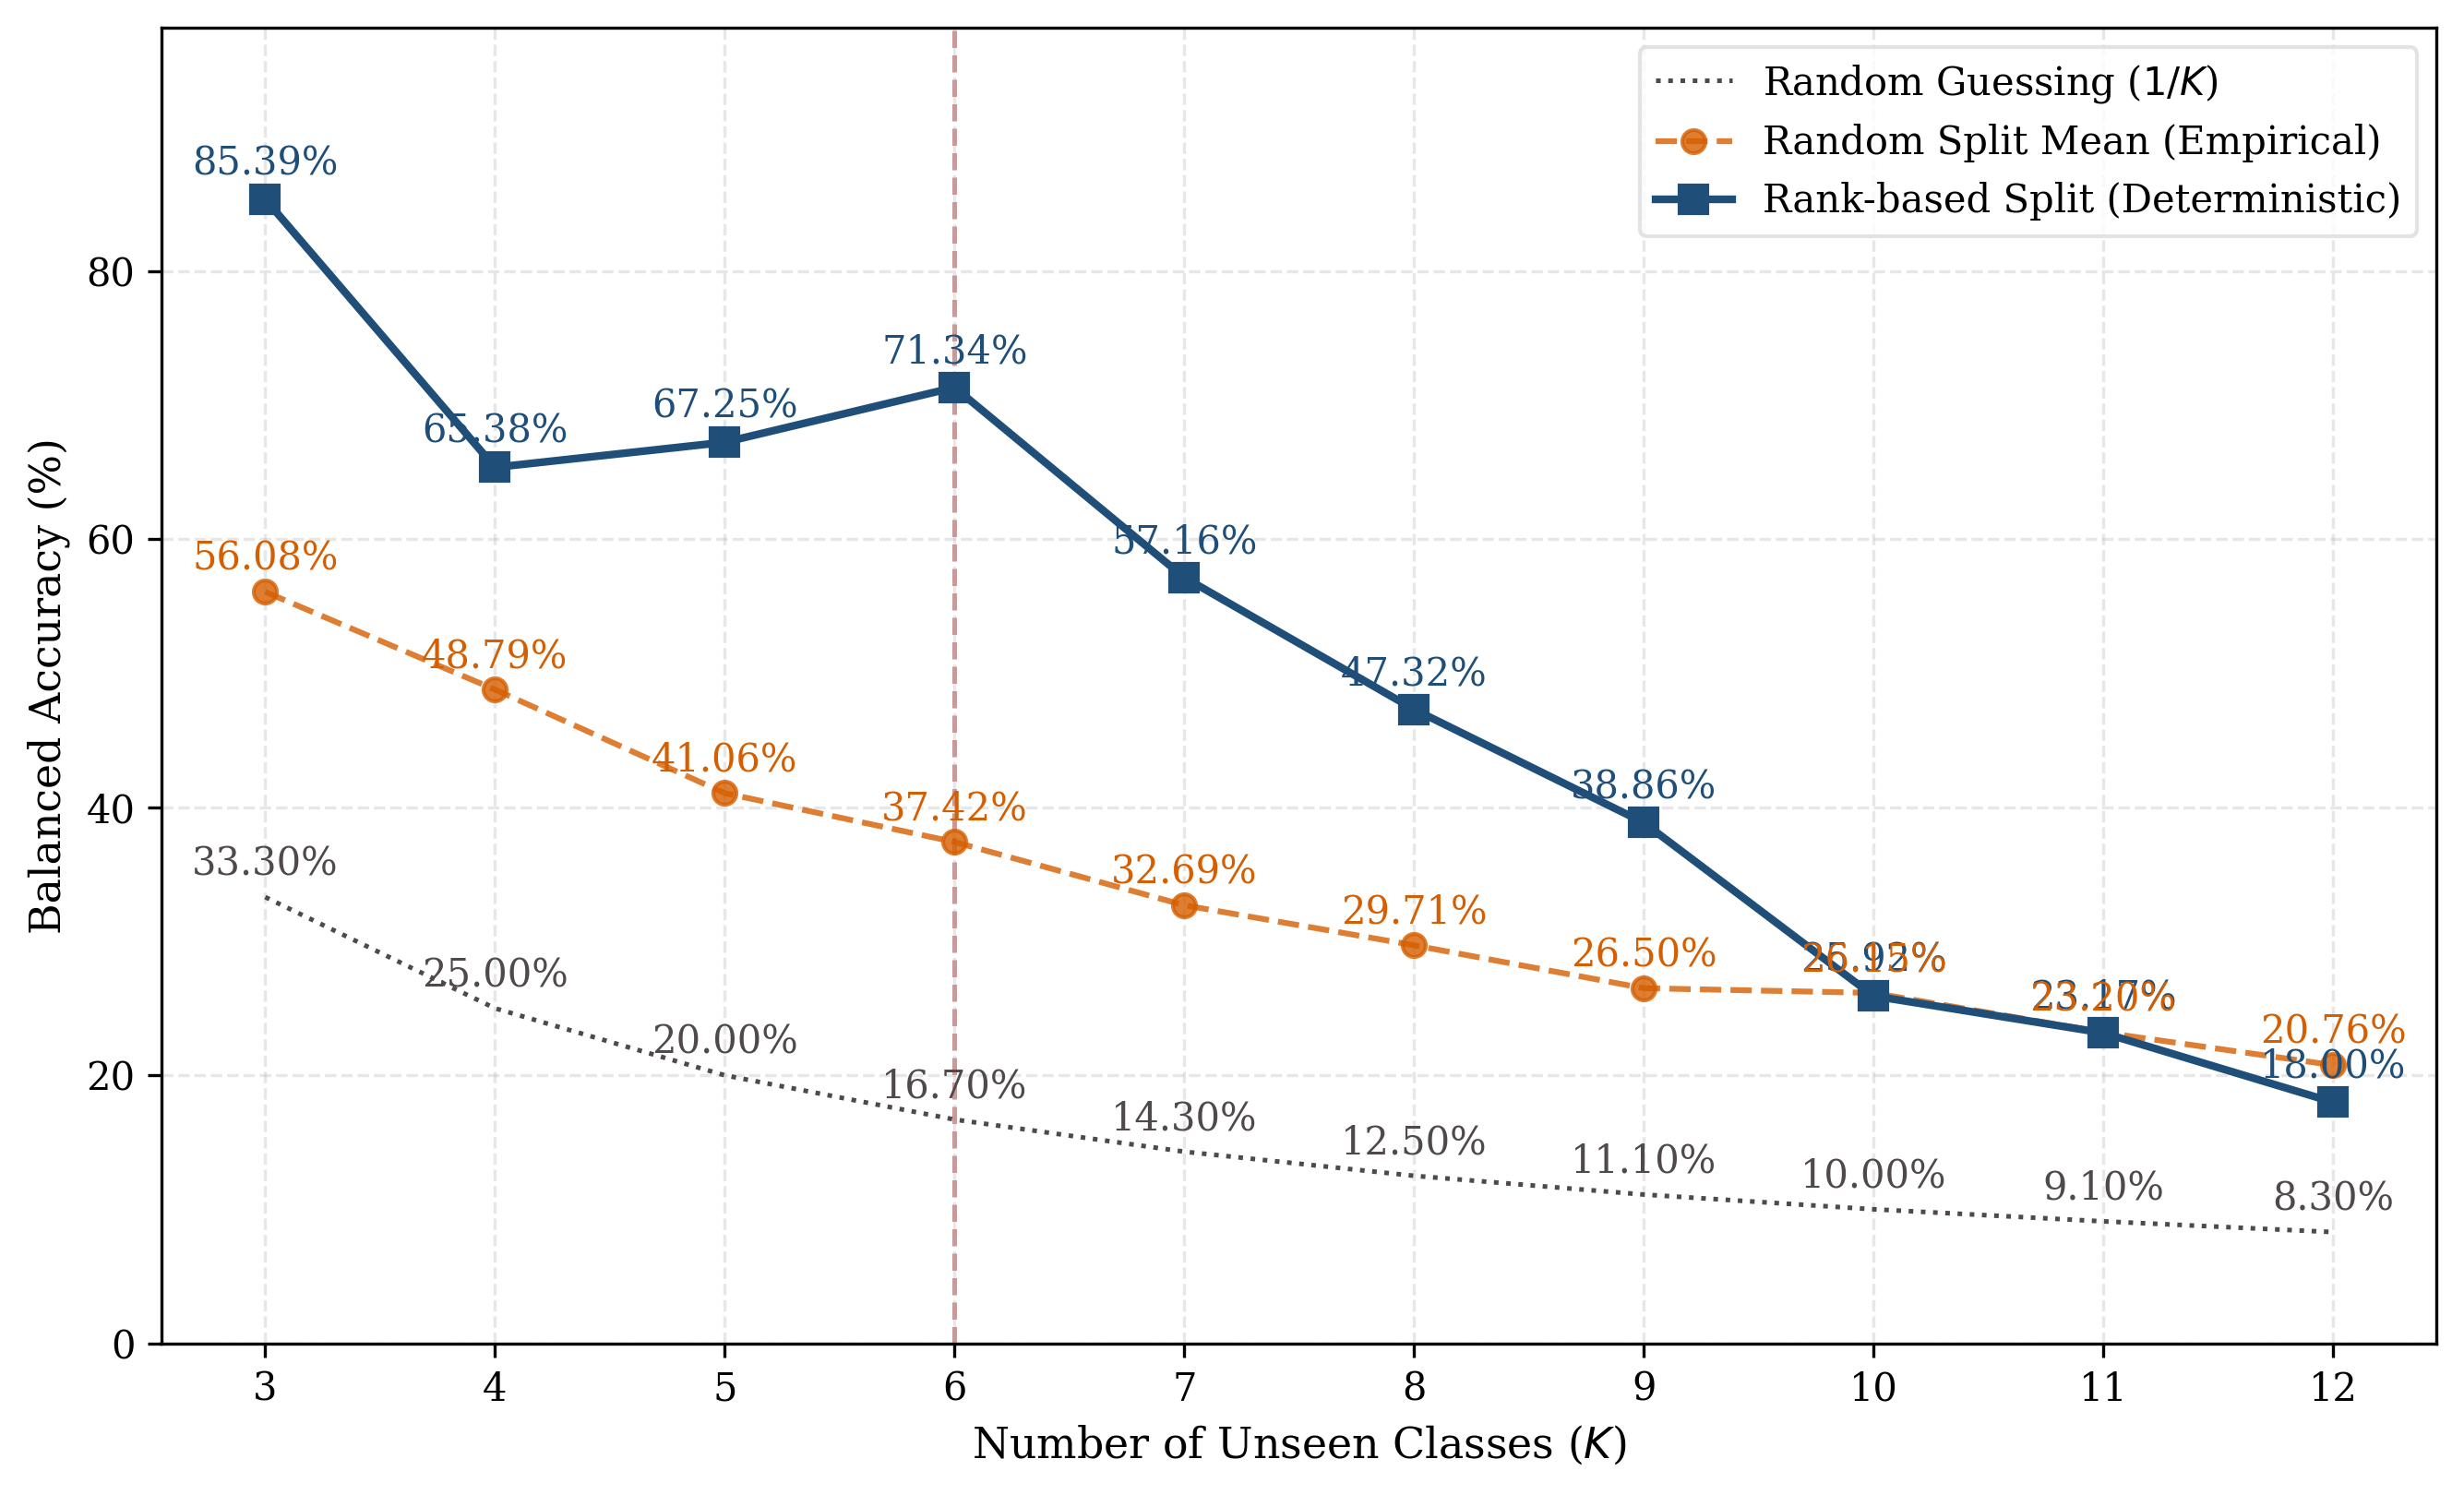

In [23]:
observed_ba     = [experiment_results[k]['accuracy'] * 100 for k in k_vals]
experiment_ba  = [experiment_results[k]['experiment_baseline'] * 100 for k in k_vals]
guessing_ba    = [experiment_results[k]['random_guessing'] * 100 for k in k_vals]

plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)

# Random Guessing
ax.plot(k_vals, guessing_ba, ':', color="#504949", linewidth=1.2, 
        label='Random Guessing ($1/K$)')

# Experimental Baseline
ax.plot(k_vals, experiment_ba, 'o--', color='#d55e00', linewidth=1.5, 
        markersize=6, alpha=0.8, label='Random Split Mean (Empirical)')

# Observed Rank-based Split
ax.plot(k_vals, observed_ba, 's-', color='#1f4e79', linewidth=2.0, 
        markersize=7, label='Rank-based Split (Deterministic)')

ax.set_xlabel('Number of Unseen Classes ($K$)', fontsize=11)
ax.set_ylabel('Balanced Accuracy (%)', fontsize=11)
ax.set_xticks(k_vals)

ax.set_ylim(0, max(observed_ba) * 1.15)
ax.grid(True, linestyle='--', alpha=0.3)
ax.axvline(x=K, color="#983333", linestyle='--', linewidth=1.2, alpha=0.5, zorder=0)
ax.legend(loc='upper right', frameon=True, fontsize=10, edgecolor='#dcdcdc')

for n, opt_acc in zip(k_vals, observed_ba):
    ax.text(n, opt_acc + 1.2, f'{opt_acc:.2f}%', 
            ha='center', va='bottom',
            fontsize=10, color='#1f4e79')
    
for n, experiment_acc in zip(k_vals, experiment_ba):
    ax.text(n, experiment_acc + 1.0, f'{experiment_acc:.2f}%', 
            ha='center', va='bottom',
            fontsize=10, color='#d55e00')
    
for n, guessing_acc in zip(k_vals, guessing_ba):
    ax.text(n, guessing_acc + 1.0, f'{guessing_acc:.2f}%', 
            ha='center', va='bottom',
            fontsize=10, color="#504949")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/Figures/Figure_5_3_Split_Comparison_new.pdf", bbox_inches='tight')
plt.show()

In [72]:
# Track each class across different K
class_performance_across_k = {}

for cls in ranking[:K_max]:
    class_performance_across_k[cls] = {}
    for k_unseen in k_vals:
        if cls in experiment_results[k_unseen]['unseen']:
            class_performance_across_k[cls][k_unseen] = (
                experiment_results[k_unseen]['class_recalls'][cls]['recall']
            )

# Wider table formatting
activity_width = 20
col_width = 9

print(f"{'Class':<6} {'Activity':<{activity_width}} ", end='')
for k in k_vals:
    print(f"{f'K={k}':<{col_width}}", end='')
print()

print('-' * (6 + 1 + activity_width + 1 + col_width * len(k_vals)))

for cls in ranking[:K_max]:
    activity = adl_dict_raw.get(str(cls), "Unknown")[:activity_width]
    print(f"{cls:<6} {activity:<{activity_width}} ", end='')
    
    for k in k_vals:
        if k in class_performance_across_k[cls]:
            acc = class_performance_across_k[cls][k]
            print(f"{acc:<{col_width}.1%}", end='')
        else:
            print(f"{'─':<{col_width}}", end='')
    print()

Class  Activity             K=3      K=4      K=5      K=6      K=7      K=8      K=9      K=10     K=11     K=12     
----------------------------------------------------------------------------------------------------------------------
17     type on keyboard     99.6%    99.9%    98.9%    93.8%    98.0%    98.3%    99.1%    98.3%    91.5%    66.6%    
14     stand up             81.2%    0.4%     80.9%    77.6%    4.3%     5.8%     72.6%    79.8%    83.0%    78.7%    
11     put on glasses       75.3%    77.5%    47.2%    55.9%    62.3%    19.1%    0.0%     0.3%     0.9%     24.1%    
9      put on shoe          ─        83.8%    37.6%    65.9%    82.6%    76.5%    0.0%     0.0%     1.2%     0.0%     
24     washing dishes       ─        ─        71.6%    66.3%    41.0%    52.0%    61.7%    37.9%    64.5%    1.4%     
5      brush teeth          ─        ─        ─        68.6%    52.1%    58.1%    12.4%    42.7%    0.0%     0.0%     
7      take off jacket      ─        ─        ─ 

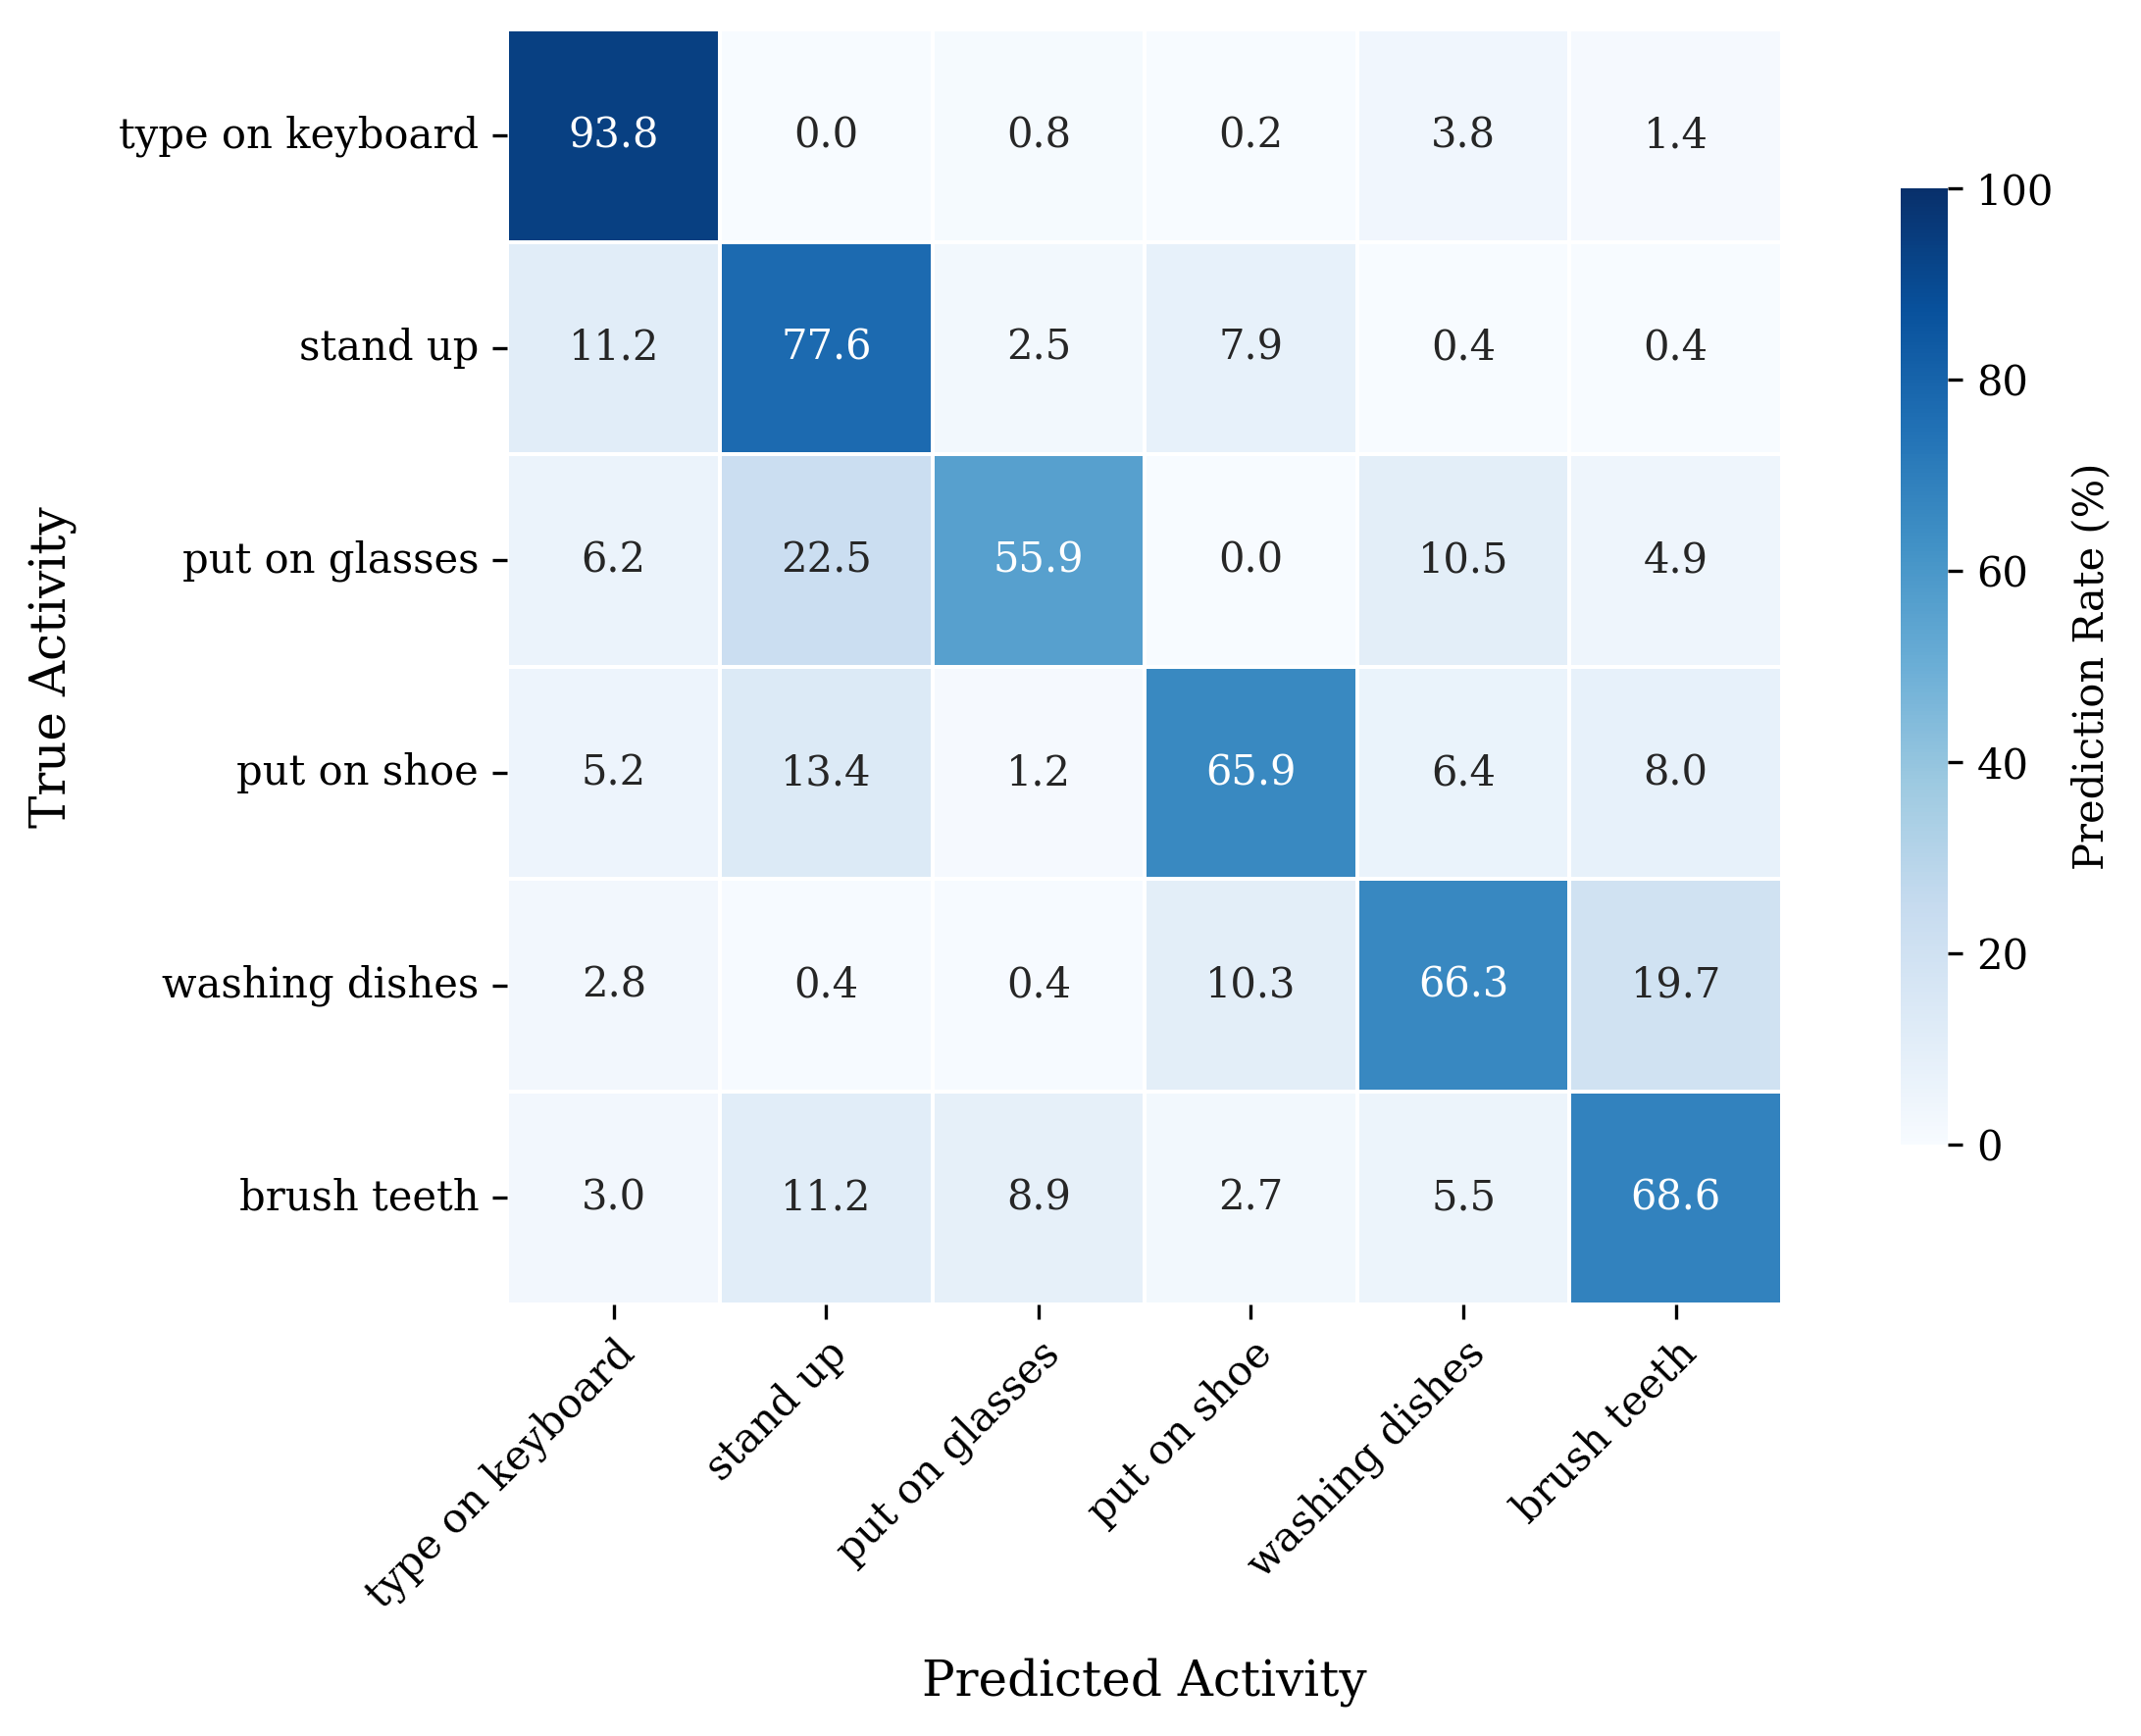

In [25]:
# Generate the confusion matrix plot for the selected K
cm_data = confusion_matrices[K]
cm_raw = cm_data['cm']
unseen_classes = cm_data['unseen_classes']

# Normalize by row (true class) to get percentages
with np.errstate(divide='ignore', invalid='ignore'):
    cm_normalized = cm_raw.astype(float) / cm_raw.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized, nan=0.0) * 100
    
# Get human-readable labels
class_names = [adl_dict_raw.get(str(cls), f"Class {cls}") for cls in unseen_classes]
class_names_short = [name if len(name) < 20 else name[:17] + "..." for name in class_names]

plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    xticklabels=class_names_short,
    yticklabels=class_names_short,
    cbar_kws={'label': 'Prediction Rate (%)', 'shrink': 0.75},
    ax=ax,
    linewidths=0.5,
    linecolor='white'
)
ax.set_xlabel("Predicted Activity", fontsize=12, labelpad=10)
ax.set_ylabel("True Activity", fontsize=12, labelpad=10)
ax.set_aspect('equal')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/Figures/Figure_5_7_2_confusion_matrix_k{K}_new.pdf", bbox_inches='tight')
plt.show()

### 

### Processed vs Raw

In [26]:
RAW_DATA_PATH = r"../Data/UiS4ADL/Processed/UiS4ADL_100hz_inactivity_removed.csv"
raw_data = pd.read_csv(RAW_DATA_PATH)
print(f"Loaded dataset: {raw_data.shape}")

Loaded dataset: (9715653, 28)


In [27]:
sensor_cols = [col for col in data.columns
        if col not in ['timestamp', 'adl', 'session', 'subject', 'fileID']]

X_raw, y_raw, _, _ = feature_extractor.extract_features(
        data=raw_data,
        method=METHOD,
        sensor_columns=sensor_cols,
        window_seconds=WINDOW_SECONDS,
        overlap_ratio=OVERLAP_RATIO,
        fs=FS,
        strategy="retain_short"
    )
y_raw = np.array(y_raw)


Extracting features: temporal_frequency
  Window: 4.0s
  Overlap: 0.0 (400 stride)
  Sampling rate: 100 Hz

Creating windows per fileID...
  Found 902 files that are too short (19.31% of the available files)
  Created 22811 windows

Extracting features using method: temporal_frequency...
  Processing window 0/22811
                    1000/22811
                    2000/22811
                    3000/22811
                    4000/22811
                    5000/22811
                    6000/22811
                    7000/22811
                    8000/22811
                    9000/22811
                    10000/22811
                    11000/22811
                    12000/22811
                    13000/22811
                    14000/22811
                    15000/22811
                    16000/22811
                    17000/22811
                    18000/22811
                    19000/22811
                    20000/22811
                    21000/22811
                   

In [28]:
# Evaluate the raw data variant
experiment_results_raw = {}
confusion_matrices_raw = {}

header = f"{'K':<2} | {'Observed Raw':<12} | {'Observed Main':<12} | {'Main - Raw':<10}"
print(header)
print("-" * len(header))
    
for n_unseen in k_vals:
    unseen_classes = ranking[:n_unseen]
    seen_classes = [cls for cls in all_classes if cls not in unseen_classes]

    seen_mask_raw = np.isin(y_raw, seen_classes)
    unseen_mask_raw = np.isin(y_raw, unseen_classes)

    X_train_raw = X_raw[seen_mask_raw]
    y_train_raw = y_raw[seen_mask_raw]
    X_test_raw = X_raw[unseen_mask_raw]
    y_test_raw = y_raw[unseen_mask_raw]

    unseen_indices = [class_to_embedding_idx[cls] for cls in unseen_classes]

    all_embeddings_indexed = np.zeros((max(all_classes) + 1, embeddings.shape[1]))
    for cls, idx in class_to_embedding_idx.items():
        if cls in all_classes:
            all_embeddings_indexed[cls] = embeddings[idx]

    model_raw = IP_SAE_MODEL(lambda_reg=0.001, scale_features=True)
    model_raw.fit(X_train_raw, y_train_raw, all_embeddings_indexed, verbose=0)
    y_pred_raw = model_raw.predict_zsl(
        X_test_raw,
        embeddings[unseen_indices],
        unseen_classes,
        n_runs=35
    )

    acc_raw = balanced_accuracy_score(y_test_raw, y_pred_raw)

    cm_raw = confusion_matrix(y_test_raw, y_pred_raw, labels=unseen_classes)
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_normalized_raw = cm_raw.astype(float) / cm_raw.sum(axis=1)[:, np.newaxis]
        cm_normalized_raw = np.nan_to_num(cm_normalized_raw, nan=0.0)

    class_recalls_raw = {}
    for i, cls in enumerate(unseen_classes):
        samples = cm_raw[i].sum()
        class_recall = cm_raw[i, i] / samples if samples > 0 else 0.0
        class_recalls_raw[cls] = {
            'recall': class_recall,
            'samples': samples,
            'divergence': divergence[cls]
        }

    experiment_results_raw[n_unseen] = {
        'unseen': unseen_classes,
        'seen': seen_classes,
        'accuracy': acc_raw,
        'n_test': len(y_test_raw),
        'class_recalls': class_recalls_raw
    }

    confusion_matrices_raw[n_unseen] = {
        'cm': cm_raw,
        'cm_normalized': cm_normalized_raw,
        'unseen_classes': unseen_classes
    }

    acc_main = experiment_results[n_unseen]['accuracy']
    main_raw_pp = (acc_main - acc_raw) * 100

    print(f"{n_unseen:<2} | "
          f"{acc_raw:>12.2%} | "
          f"{acc_main:>12.2%} | "
          f"{main_raw_pp:>+10.2f}")

K  | Observed Raw | Observed Main | Main - Raw
----------------------------------------------
3  |       79.96% |       85.39% |      +5.43
4  |       64.25% |       65.38% |      +1.13
5  |       63.35% |       67.25% |      +3.91
6  |       59.23% |       71.34% |     +12.12
7  |       54.98% |       57.16% |      +2.17
8  |       47.04% |       47.32% |      +0.27
9  |       36.83% |       38.86% |      +2.03
10 |       24.80% |       25.92% |      +1.12
11 |       25.83% |       23.17% |      -2.67
12 |       14.11% |       18.00% |      +3.88


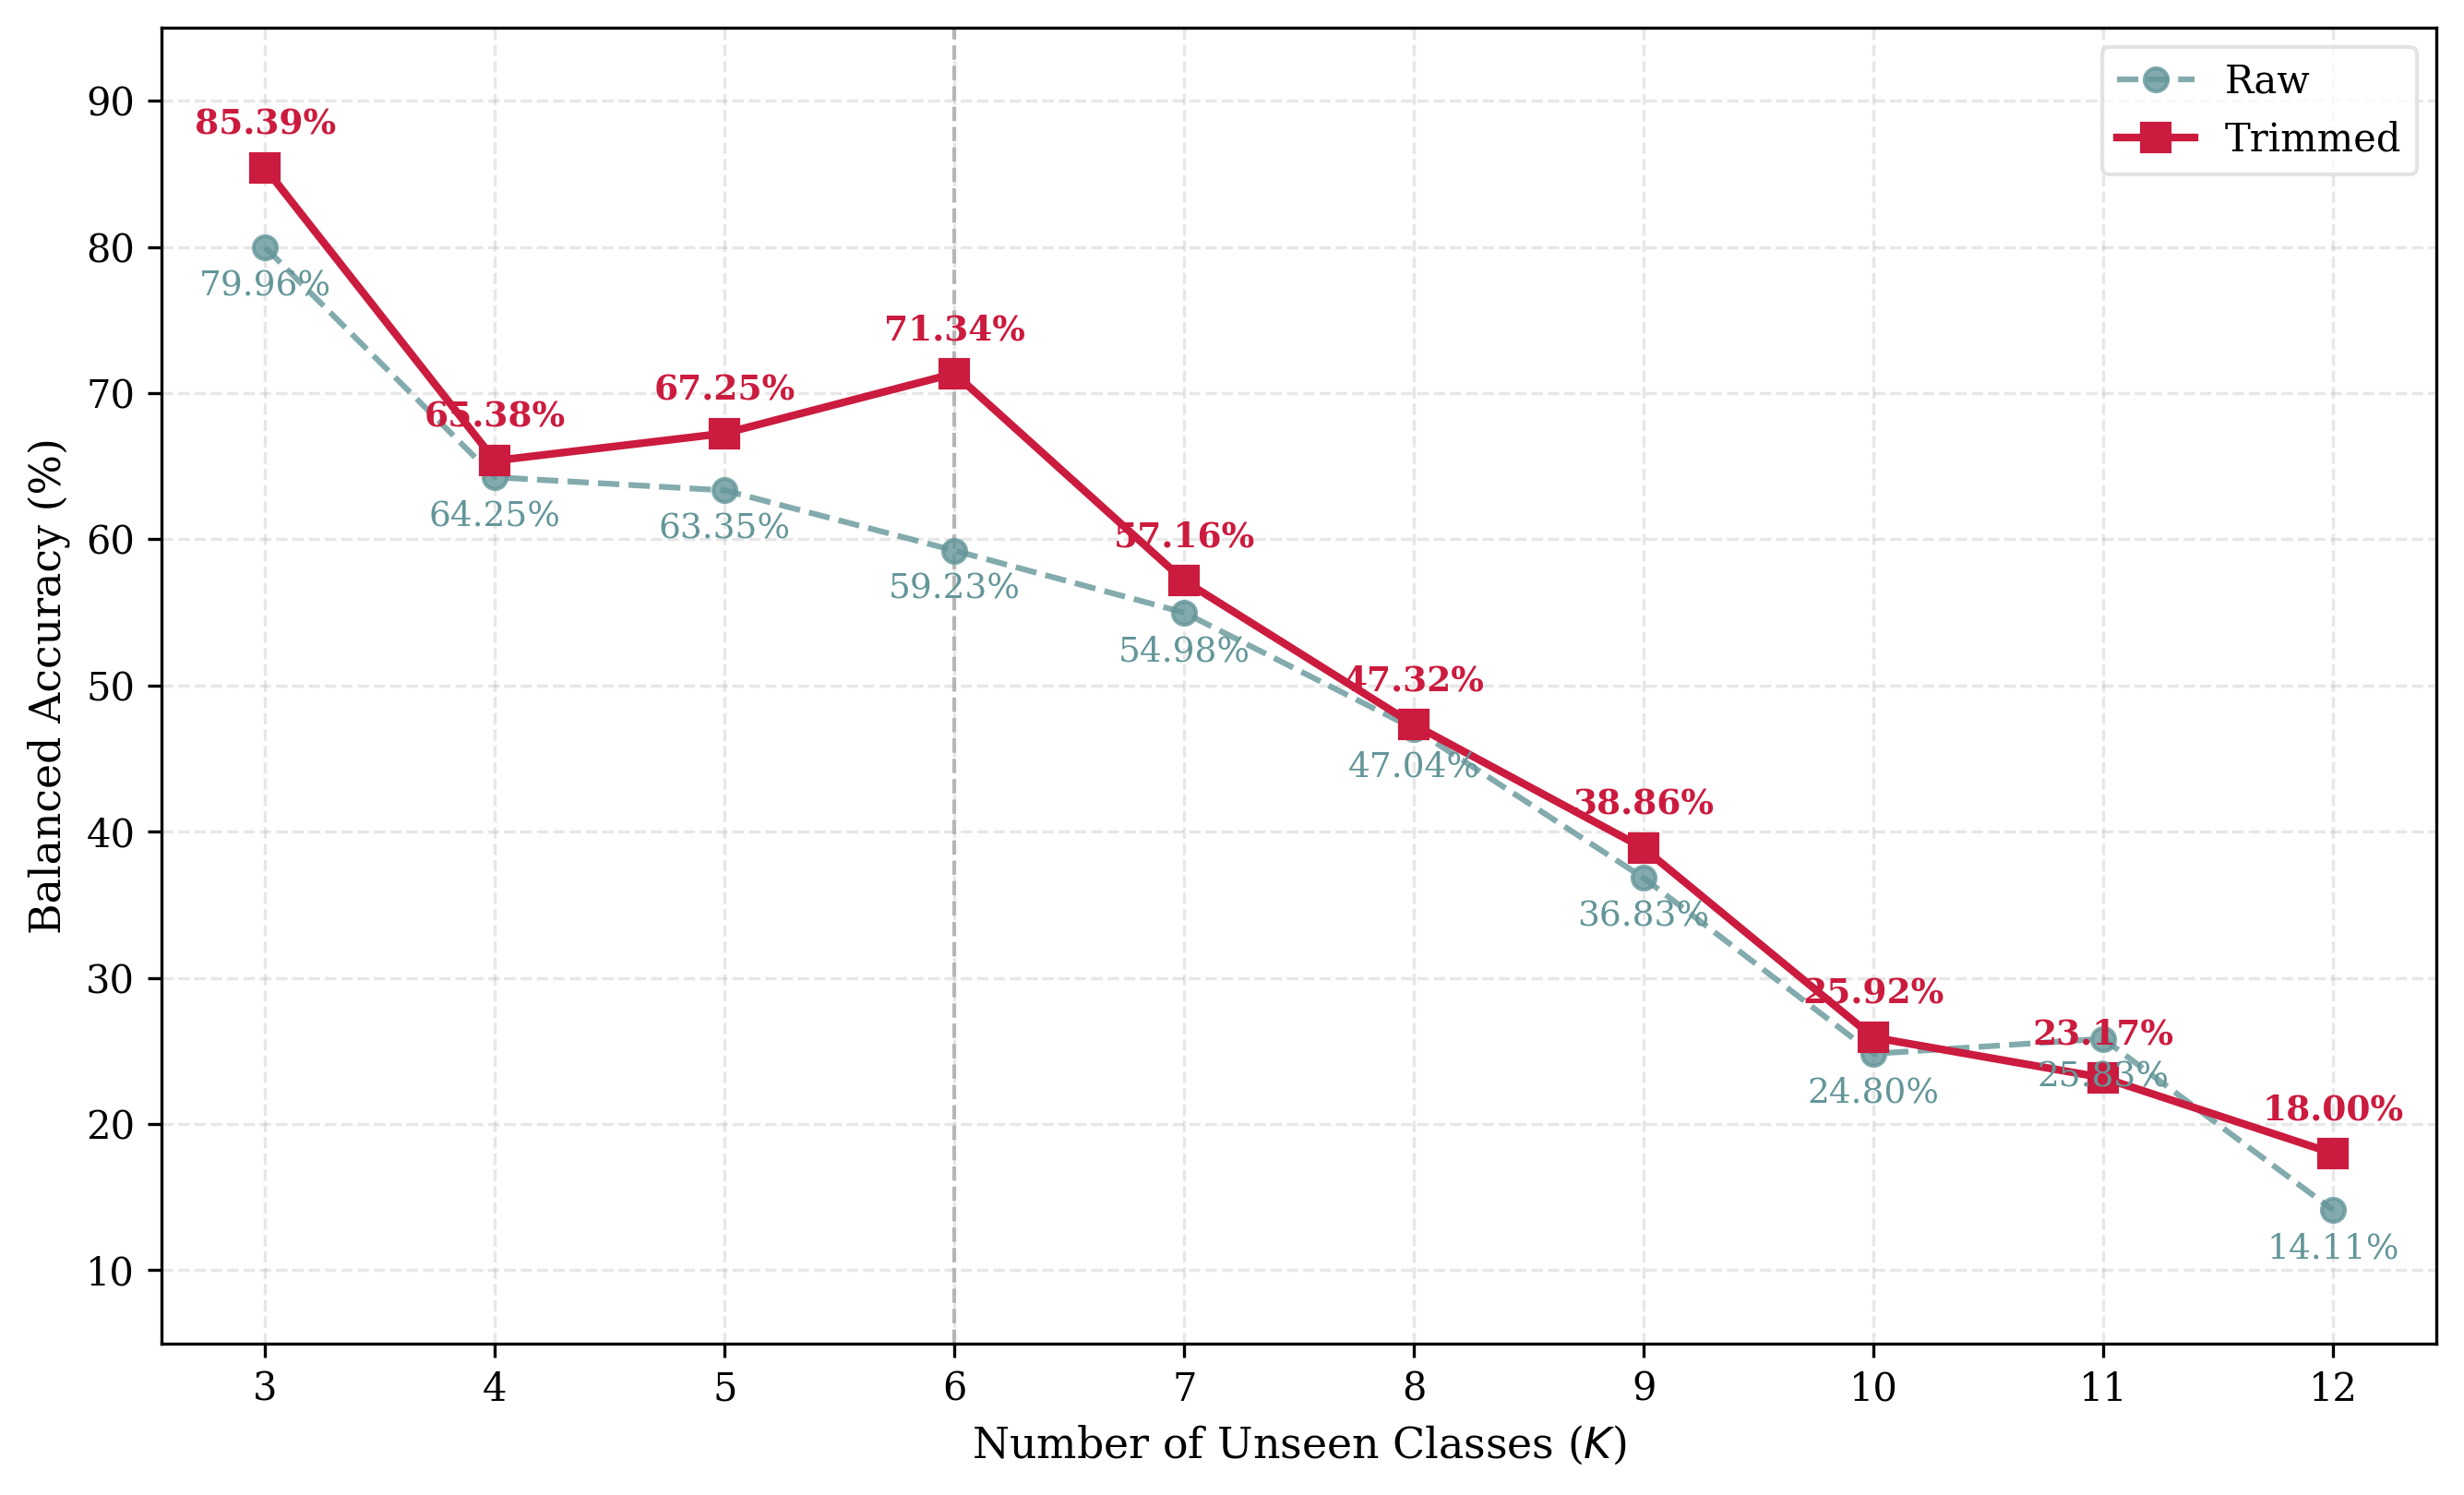

In [31]:
# Compare raw vs trimmed data performance across K
k_vals_plot = k_vals

raw_vals = [experiment_results_raw[k]['accuracy'] * 100 for k in k_vals_plot]
trim_vals = [experiment_results[k]['accuracy'] * 100 for k in k_vals_plot]

color_raw = "#649699"   # Teal
color_trim = "#cb1b3e"  # Crimson

plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)

# Raw Data
ax.plot(
    k_vals_plot, raw_vals,
    'o--',
    color=color_raw,
    linewidth=1.5,
    markersize=6,
    alpha=0.8,
    label='Raw'
)

# Trimmed data
ax.plot(
    k_vals_plot, trim_vals,
    's-',
    color=color_trim,
    linewidth=2.0,
    markersize=7,
    label='Trimmed'
)

ax.set_xlabel('Number of Unseen Classes ($K$)', fontsize=11)
ax.set_ylabel('Balanced Accuracy (%)', fontsize=11)
ax.set_xticks(k_vals_plot)
ax.set_ylim(5, 95)
ax.grid(True, linestyle='--', alpha=0.3)


ax.axvline(x=K, color="#504949", linestyle='--', linewidth=1.0, alpha=0.4, zorder=0)
ax.legend(loc='upper right', frameon=True, fontsize=10, edgecolor='#dcdcdc')

for k, r_acc in zip(k_vals_plot, raw_vals):
    ax.text(
        k, r_acc - 3.8, f'{r_acc:.2f}%',
        ha='center', va='bottom',
        fontsize=9,
        color=color_raw)

for k, t_acc in zip(k_vals_plot, trim_vals):
    ax.text(
        k, t_acc + 1.8, f'{t_acc:.2f}%',
        ha='center', va='bottom',
        fontsize=9,
        color=color_trim,
        fontweight='bold')


plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/Figures/Figure_5_4_Trimming_Effect_new.pdf", bbox_inches='tight')
plt.show()

In [32]:
# Compare per-class recallss for the selected K, and see if the most divergent classes show the biggest improvements after trimming
unseen_classes = experiment_results[K]['unseen']

rows = []
for cls in unseen_classes:
    activity = adl_dict_raw.get(str(cls), f"Class {cls}")[:22]
    raw_recall = experiment_results_raw[K]['class_recalls'][cls]['recall'] * 100
    trim_recall = experiment_results[K]['class_recalls'][cls]['recall'] * 100
    delta_pp = trim_recall - raw_recall
    rows.append((cls, activity, raw_recall, trim_recall, delta_pp))

print(f"{'ID':<4} | {'Activity Name':<22} | {'Raw Recall':<12} | {'Trim Recall':<12} | {'Delta':<5}")
print("-" * 96)
for cls, activity, raw_recall, trim_recall, delta_pp in rows:
    print(f"{cls:<4} | "
          f"{activity:<22} | "
          f"{raw_recall:>9.2f}%   | "
          f"{trim_recall:>9.2f}%   | "
          f"{delta_pp:>+8.2f}")

ID   | Activity Name          | Raw Recall   | Trim Recall  | Delta
------------------------------------------------------------------------------------------------
17   | type on keyboard       |     97.36%   |     93.81%   |    -3.55
14   | stand up               |      0.00%   |     77.62%   |   +77.62
11   | put on glasses         |     66.32%   |     55.86%   |   -10.46
9    | put on shoe            |     78.11%   |     65.88%   |   -12.23
24   | washing dishes         |     64.20%   |     66.27%   |    +2.07
5    | brush teeth            |     49.36%   |     68.62%   |   +19.26


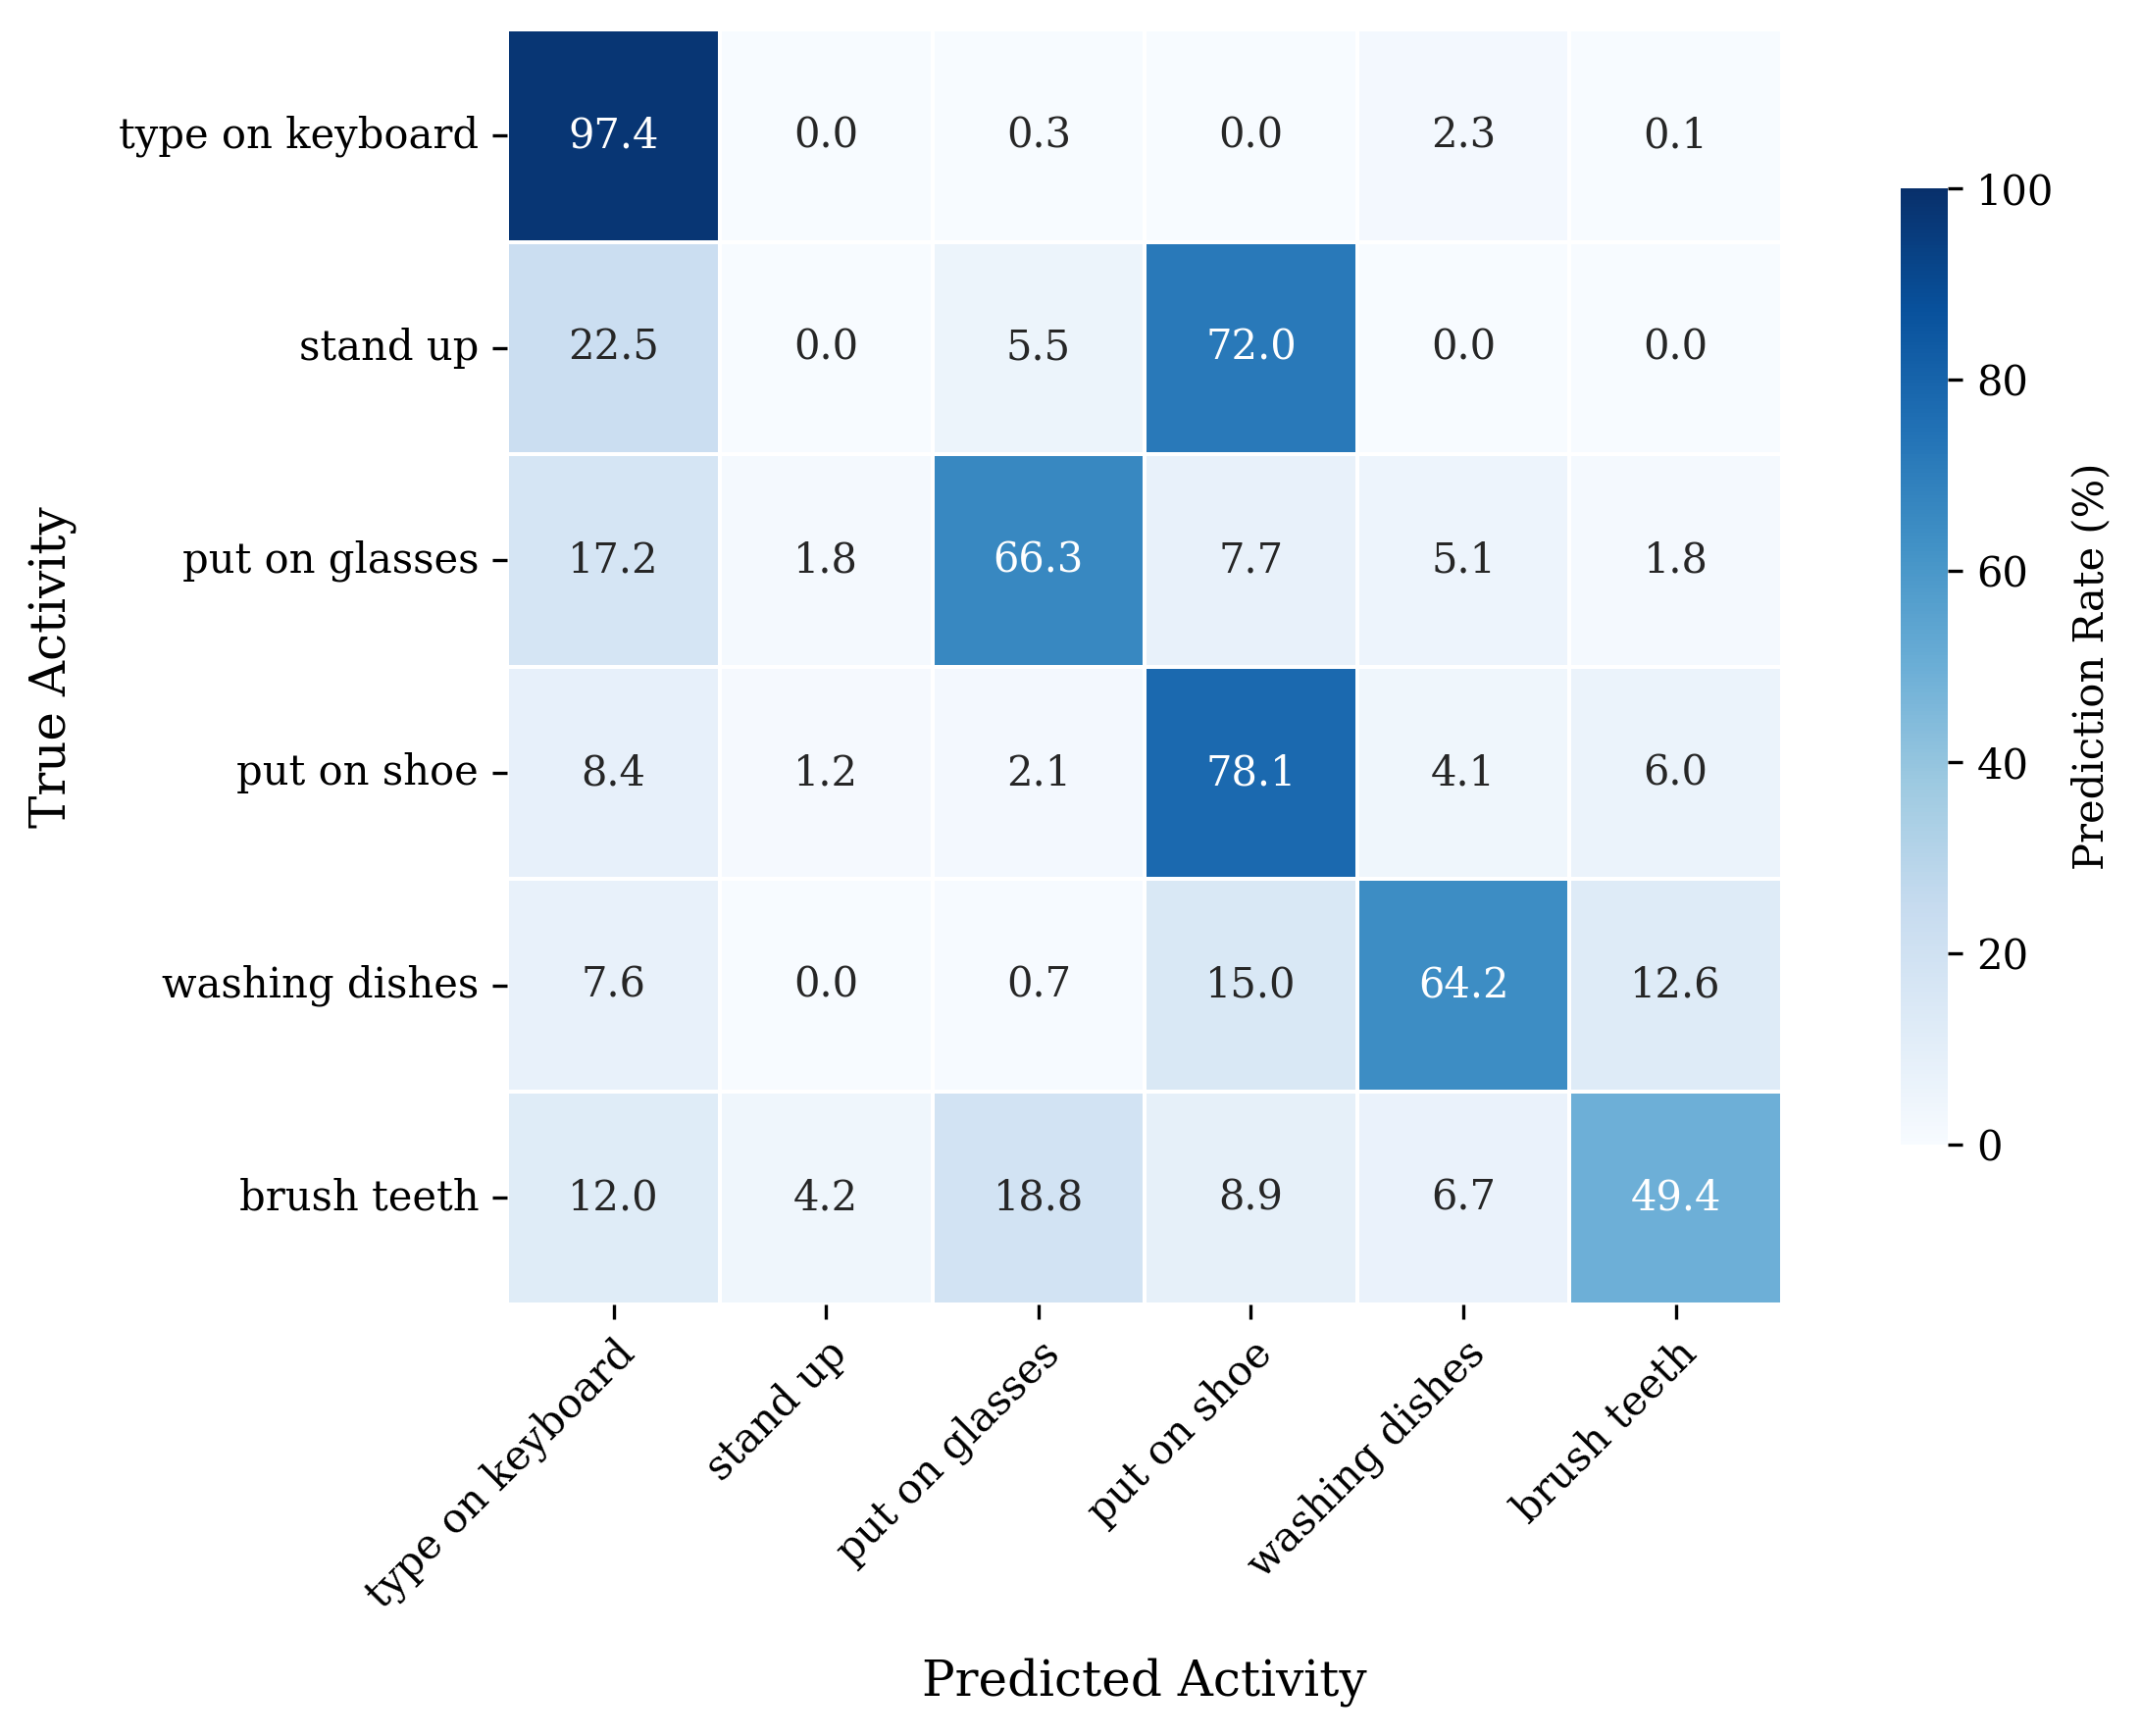

In [33]:
# Generate the confusion matrix for the selected K on the raw-data variant
cm_data_raw = confusion_matrices_raw[K]
cm_raw = cm_data_raw['cm']
unseen_classes_raw = cm_data_raw['unseen_classes']

# Normalize by row (true class) to get percentages
with np.errstate(divide='ignore', invalid='ignore'):
    cm_normalized_raw = cm_raw.astype(float) / cm_raw.sum(axis=1)[:, np.newaxis]
    cm_normalized_raw = np.nan_to_num(cm_normalized_raw, nan=0.0) * 100

# Get human-readable names
class_names_raw = [adl_dict_raw.get(str(cls), f"Class {cls}") for cls in unseen_classes_raw]
class_names_short_raw = [name if len(name) < 20 else name[:17] + "..." for name in class_names_raw]

plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

sns.heatmap(
    cm_normalized_raw,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    xticklabels=class_names_short_raw,
    yticklabels=class_names_short_raw,
    cbar_kws={'label': 'Prediction Rate (%)', 'shrink': 0.75},
    ax=ax,
    linewidths=0.5,
    linecolor='white'
)

ax.set_xlabel("Predicted Activity", fontsize=12, labelpad=10)
ax.set_ylabel("True Activity", fontsize=12, labelpad=10)
ax.set_aspect('equal')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### Activity description experiment

In [34]:
DESC_TYPES_TO_TEST = ['random_unrelated', 'noisy', 'short', 'specific']
BASELINE_DESC_TYPE = 'original_fadi'

PLOT_LABELS = {
    'random_unrelated': 'Random',
    'noisy': 'Noisy',
    'specific': 'Specific',
    'short': 'Short',
    'original_fadi': 'Original\n(Default)'
}

In [51]:
# Fixed split based on the primary evaluation setting
unseen_classes = ranking[:K]
seen_classes = [cls for cls in all_classes if cls not in unseen_classes]

seen_mask = np.isin(y, seen_classes)
unseen_mask = np.isin(y, unseen_classes)

X_train = X[seen_mask]
y_train = np.array(y)[seen_mask]
X_test = X[unseen_mask]
y_test = np.array(y)[unseen_mask]

embedding_generator = EmbeddingGenerator(output_dir="../Data/Embeddings")

results_ba = {}
results_pred = {}
results_cm = {}

for desc_type in DESC_TYPES_TO_TEST:
    print(f"\nRunning description experiment: {desc_type}")
    
    embeddings_dt = embedding_generator.load_embeddings(
        model_name=EMBEDDING_MODEL,
        desc_type=desc_type,
        use_prompt=USE_PROMPT,
        dataset='fadi'
    )
    
    activity_descriptions_dt = get_descriptions(desc_type)
    activity_labels_dt = sorted(activity_descriptions_dt.keys())
    class_to_embedding_idx_dt = {label: idx for idx, label in enumerate(activity_labels_dt)}
    
    unseen_indices_dt = [class_to_embedding_idx_dt[cls] for cls in unseen_classes]
    
    all_embeddings_indexed_dt = np.zeros((max(all_classes) + 1, embeddings_dt.shape[1]))
    for cls, idx in class_to_embedding_idx_dt.items():
        if cls in all_classes:
            all_embeddings_indexed_dt[cls] = embeddings_dt[idx]
    

    model_dt = IP_SAE_MODEL(lambda_reg=LAMBDA, scale_features=True)
    model_dt.fit(X_train, y_train, all_embeddings_indexed_dt, verbose=0)
    
    y_pred_dt = model_dt.predict_zsl(
        X_test,
        embeddings_dt[unseen_indices_dt],
        unseen_classes,
        n_runs=35
    )
    
    ba_dt = balanced_accuracy_score(y_test, y_pred_dt) * 100
    
    results_ba[desc_type] = ba_dt
    results_pred[desc_type] = y_pred_dt
    results_cm[desc_type] = confusion_matrix(y_test, y_pred_dt, labels=unseen_classes)
    
    print(f"  Balanced Accuracy: {ba_dt:.2f}%")


Running description experiment: random_unrelated
Loaded embeddings from: ../Data/Embeddings/all_minilm_l6_v2_random_unrelated_prompt_fadi.npz
Model: all-MiniLM-L6-v2
Shape: (24, 384)
  Balanced Accuracy: 17.80%

Running description experiment: noisy
Loaded embeddings from: ../Data/Embeddings/all_minilm_l6_v2_noisy_prompt_fadi.npz
Model: all-MiniLM-L6-v2
Shape: (24, 384)
  Balanced Accuracy: 49.03%

Running description experiment: short
Loaded embeddings from: ../Data/Embeddings/all_minilm_l6_v2_short_prompt_fadi.npz
Model: all-MiniLM-L6-v2
Shape: (24, 384)
  Balanced Accuracy: 54.36%

Running description experiment: specific
Loaded embeddings from: ../Data/Embeddings/all_minilm_l6_v2_specific_prompt_fadi.npz
Model: all-MiniLM-L6-v2
Shape: (24, 384)
  Balanced Accuracy: 47.52%


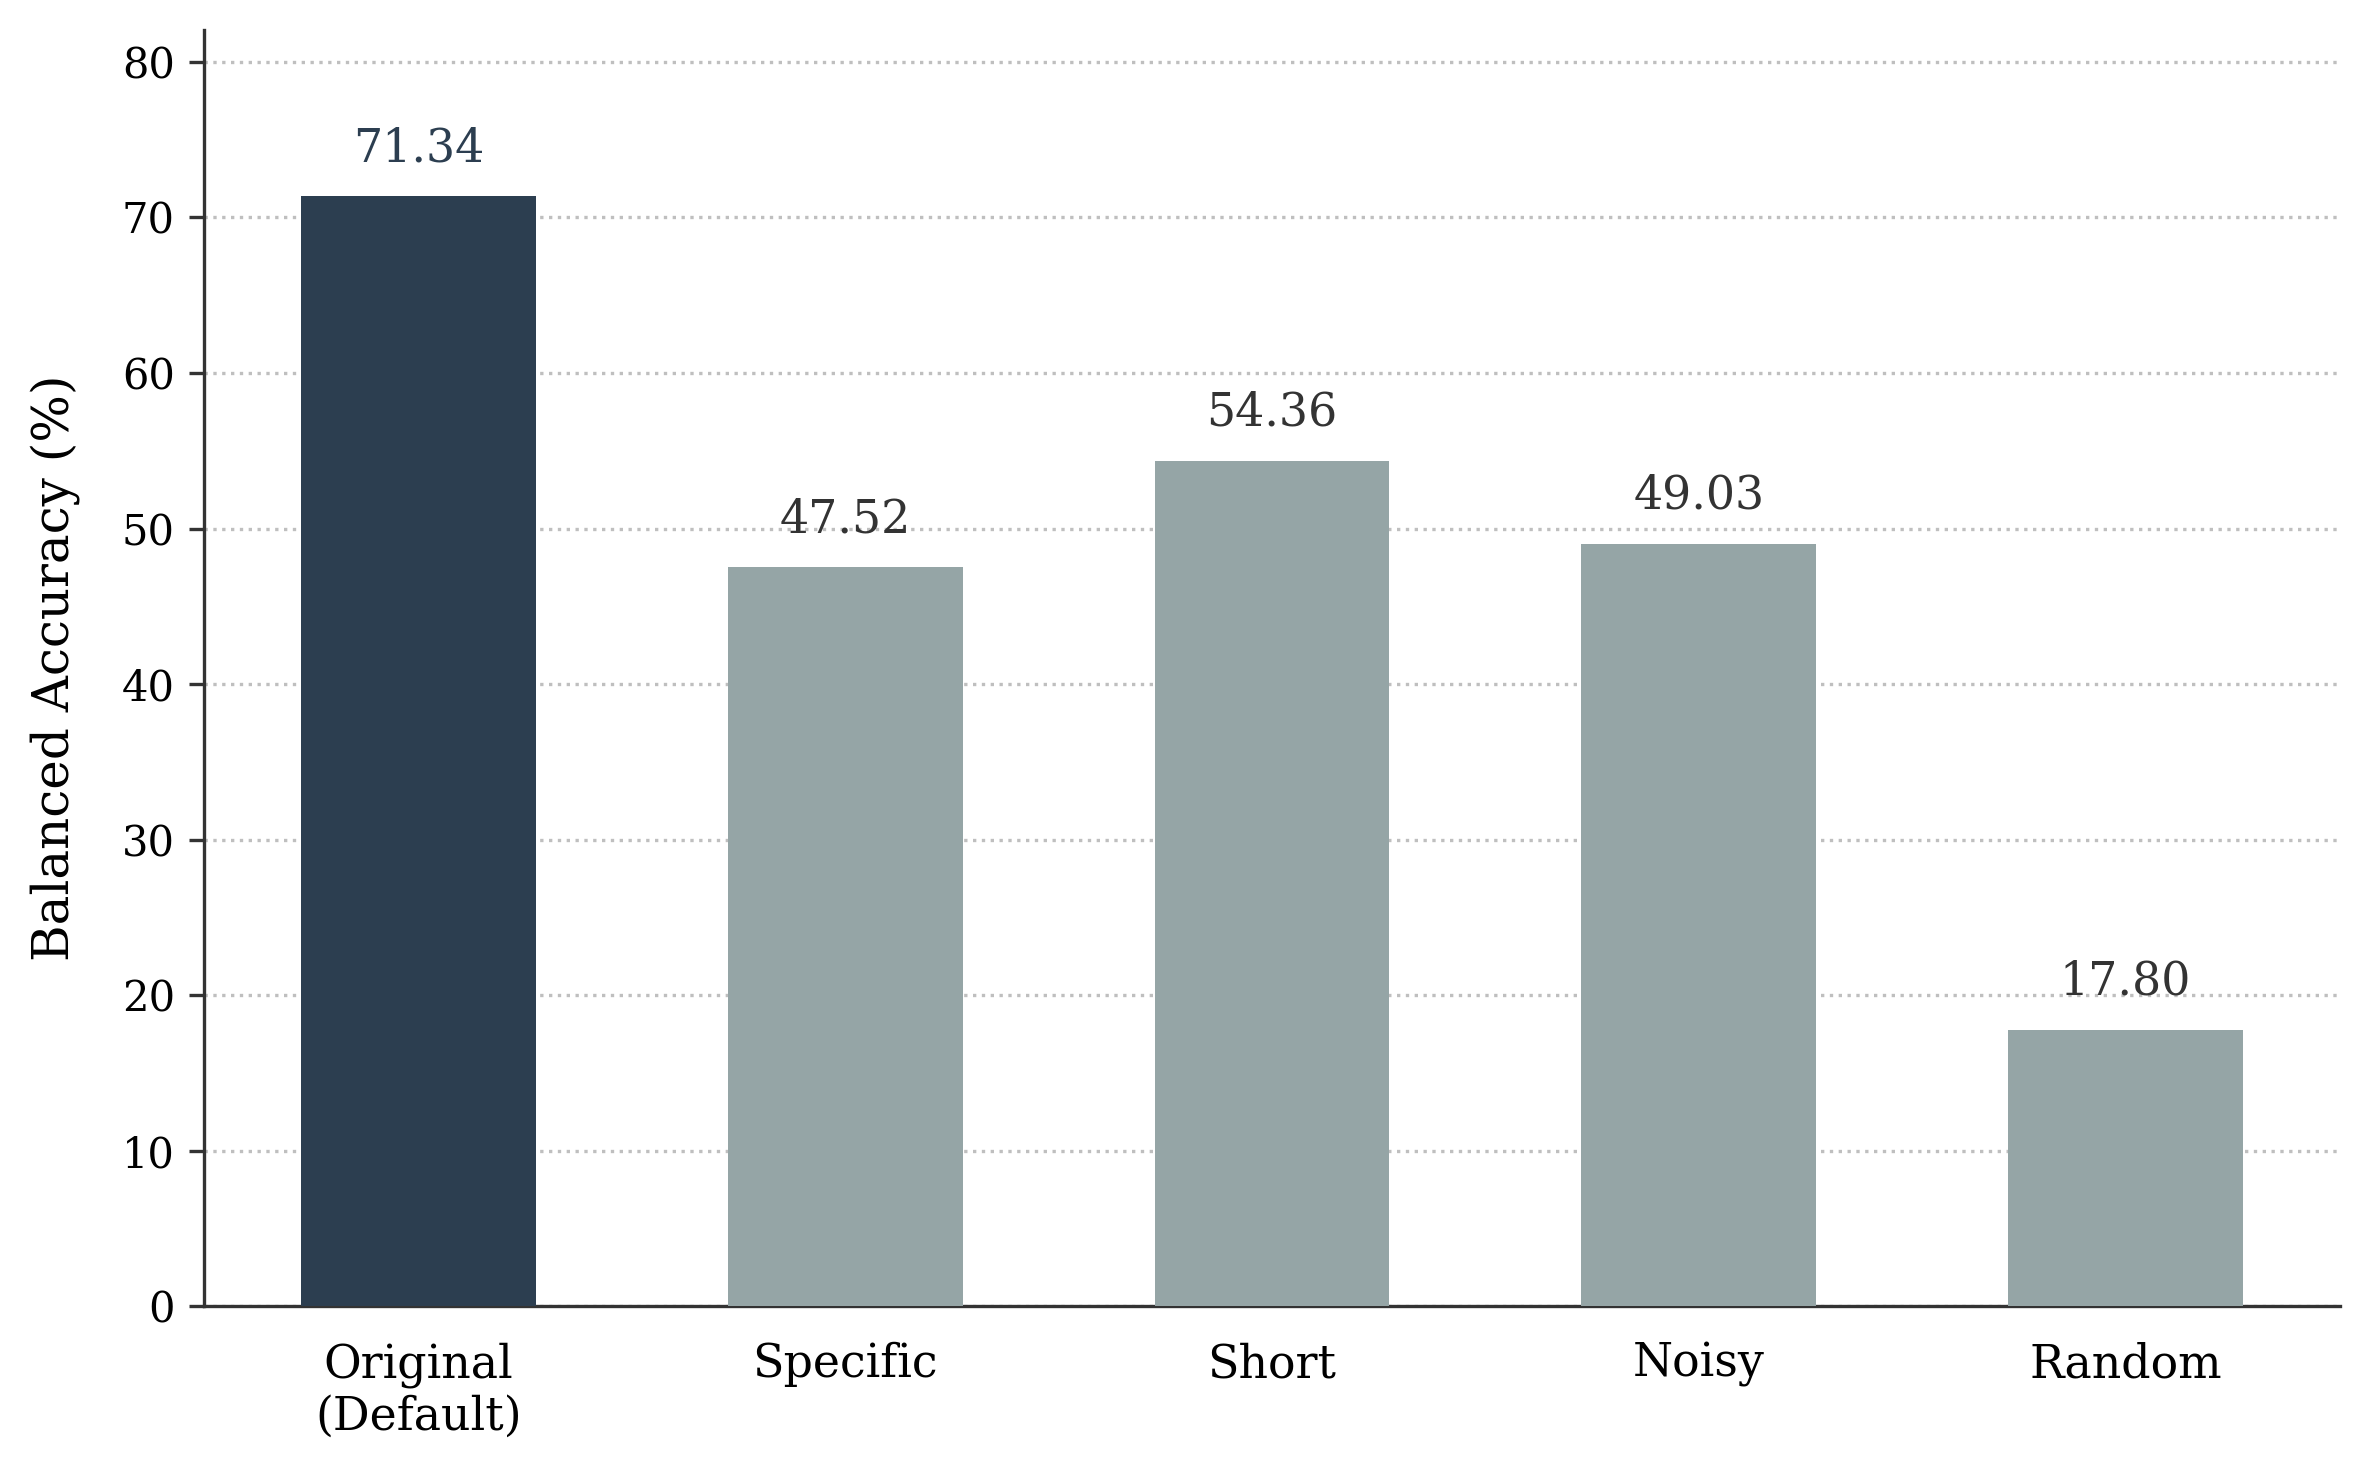

In [52]:
plt.rcParams['font.family'] = 'serif'

plot_variants = ['original_fadi', 'specific', 'short', 'noisy', 'random_unrelated']
labels = ['Original\n(Default)', 'Specific', 'Short', 'Noisy', 'Random']

scores = [
    experiment_results[K]['accuracy'] * 100,  # baseline from previous experiment
    results_ba['specific'],
    results_ba['short'],
    results_ba['noisy'],
    results_ba['random_unrelated']
]

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

default_color = '#2C3E50'
variant_color = '#95A5A6'
colors = [default_color] + [variant_color] * 4

bars = ax.bar(
    labels,
    scores,
    color=colors,
    width=0.55,
    zorder=3,
    edgecolor='none'
)

ax.set_ylabel('Balanced Accuracy (%)', fontsize=12, labelpad=10)
ax.set_ylim(0, max(scores) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')
ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0, color='gray')
ax.tick_params(axis='x', labelsize=11, bottom=False, pad=5)
ax.tick_params(axis='y', labelsize=10, left=True, color='#333333')

for i, bar in enumerate(bars):
    height = bar.get_height()
    text_color = default_color if i == 0 else '#333333'
    
    ax.annotate(
        f'{height:.2f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 6),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=11,
        color=text_color,
    )

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/Figures/Figure_5_4_1_descriptions_new.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Embedding models experiment

In [37]:
BASELINE_MODEL = 'all-MiniLM-L6-v2'

MODELS_TO_TEST = [
    'all-MiniLM-L6-v2',
    'paraphrase-MiniLM-L6-v2',
    'all-mpnet-base-v2',
    'hkunlp/instructor-large',
    'clip-ViT-B/32'
]

PLOT_LABELS = {
    'all-MiniLM-L6-v2': 'all-MiniLM-L6-v2\n(Default)',
    'paraphrase-MiniLM-L6-v2': 'paraphrase-MiniLM',
    'all-mpnet-base-v2': 'all-mpnet-base',
    'hkunlp/instructor-large': 'instructor-large',
    'clip-ViT-B/32': 'CLIP ViT-B/32'
}

In [38]:
# Fixed split based on the primary evaluation setting
unseen_classes = ranking[:K]
seen_classes = [cls for cls in all_classes if cls not in unseen_classes]

seen_mask = np.isin(y, seen_classes)
unseen_mask = np.isin(y, unseen_classes)

X_train = X[seen_mask]
y_train = np.array(y)[seen_mask]
X_test = X[unseen_mask]
y_test = np.array(y)[unseen_mask]

embedding_generator = EmbeddingGenerator(output_dir="../Data/Embeddings")

results_ba_models = {}
results_pred_models = {}
results_cm_models = {}

for model_name in MODELS_TO_TEST:
    print(f"\nRunning embedding model experiment: {model_name}")
    
    embeddings_model = embedding_generator.load_embeddings(
        model_name=model_name,
        desc_type=DESCRIPTION_TYPE,
        use_prompt=USE_PROMPT,
        dataset='fadi'
    )
    
    activity_descriptions_model = get_descriptions(DESCRIPTION_TYPE)
    activity_labels_model = sorted(activity_descriptions_model.keys())
    class_to_embedding_idx_model = {label: idx for idx, label in enumerate(activity_labels_model)}
    
    unseen_indices_model = [class_to_embedding_idx_model[cls] for cls in unseen_classes]
    
    all_embeddings_indexed_model = np.zeros((max(all_classes) + 1, embeddings_model.shape[1]))
    for cls, idx in class_to_embedding_idx_model.items():
        if cls in all_classes:
            all_embeddings_indexed_model[cls] = embeddings_model[idx]
    
    model_exp = IP_SAE_MODEL(lambda_reg=LAMBDA, scale_features=True)
    model_exp.fit(X_train, y_train, all_embeddings_indexed_model, verbose=0)
    
    y_pred_model = model_exp.predict_zsl(
        X_test,
        embeddings_model[unseen_indices_model],
        unseen_classes,
        n_runs=35
    )
    
    ba_model = balanced_accuracy_score(y_test, y_pred_model) * 100
    
    results_ba_models[model_name] = ba_model
    results_pred_models[model_name] = y_pred_model
    results_cm_models[model_name] = confusion_matrix(y_test, y_pred_model, labels=unseen_classes)
    
    print(f"  Balanced Accuracy: {ba_model:.2f}%")


Running embedding model experiment: all-MiniLM-L6-v2
Loaded embeddings from: ../Data/Embeddings/all_minilm_l6_v2_original_fadi_prompt_fadi.npz
Model: all-MiniLM-L6-v2
Shape: (24, 384)
  Balanced Accuracy: 71.34%

Running embedding model experiment: paraphrase-MiniLM-L6-v2
Loaded embeddings from: ../Data/Embeddings/paraphrase_minilm_l6_v2_original_fadi_prompt_fadi.npz
Model: paraphrase-MiniLM-L6-v2
Shape: (24, 384)
  Balanced Accuracy: 66.31%

Running embedding model experiment: all-mpnet-base-v2
Loaded embeddings from: ../Data/Embeddings/all_mpnet_base_v2_original_fadi_prompt_fadi.npz
Model: all-mpnet-base-v2
Shape: (24, 768)
  Balanced Accuracy: 56.46%

Running embedding model experiment: hkunlp/instructor-large
Loaded embeddings from: ../Data/Embeddings/hkunlp_instructor_large_original_fadi_prompt_fadi.npz
Model: hkunlp/instructor-large
Shape: (24, 768)
  Balanced Accuracy: 52.86%

Running embedding model experiment: clip-ViT-B/32
Loaded embeddings from: ../Data/Embeddings/clip_vit_

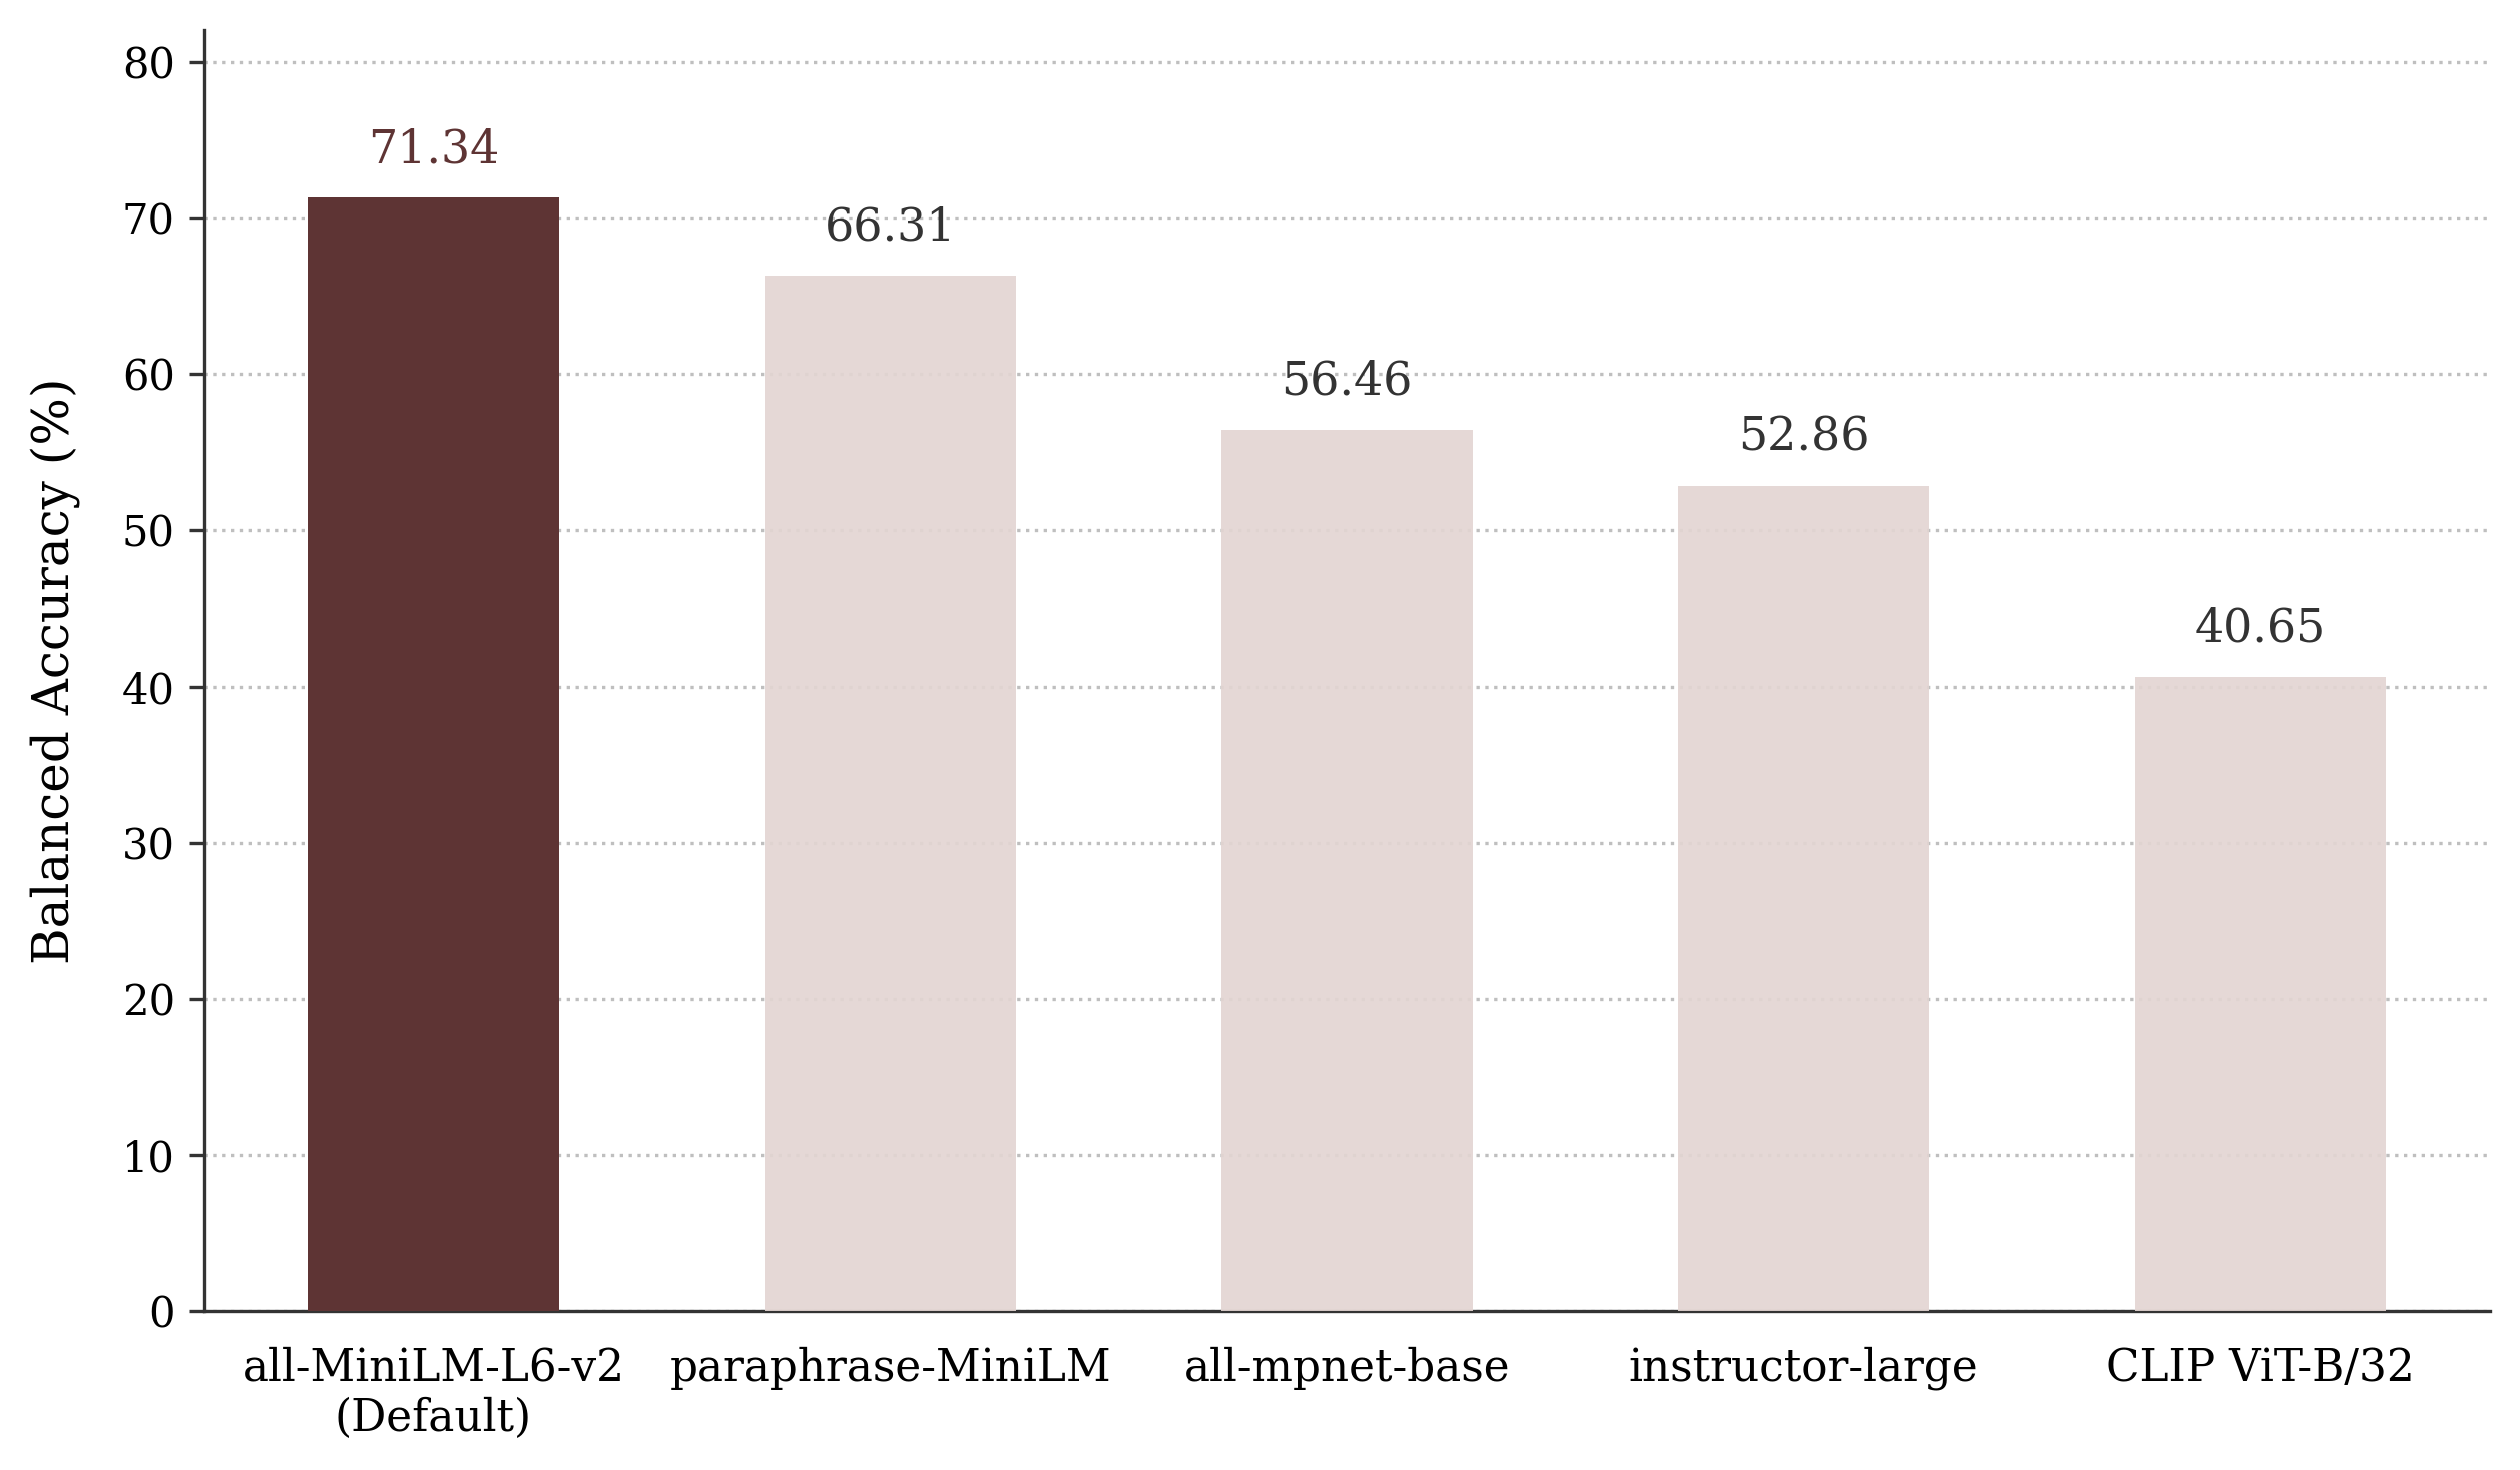

In [39]:
plt.rcParams['font.family'] = 'serif'

plot_models = [
    'all-MiniLM-L6-v2',
    'paraphrase-MiniLM-L6-v2',
    'all-mpnet-base-v2',
    'hkunlp/instructor-large',
    'clip-ViT-B/32'
]

labels = [PLOT_LABELS[m] for m in plot_models]
scores = [results_ba_models[m] for m in plot_models]

fig, ax = plt.subplots(figsize=(8.5, 5), dpi=300)

default_color = '#5E3434'
variant_color = "#E3D5D2E9"
colors = [default_color] + [variant_color] * 4

bars = ax.bar(
    labels,
    scores,
    color=colors,
    width=0.55,
    zorder=3,
    edgecolor='none'
)

ax.set_ylabel('Balanced Accuracy (%)', fontsize=12, labelpad=10)
ax.set_ylim(0, max(scores) * 1.15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0, color='gray')

ax.tick_params(axis='x', labelsize=10.5, bottom=False, pad=5)
ax.tick_params(axis='y', labelsize=10, left=True, color='#333333')

for i, bar in enumerate(bars):
    height = bar.get_height()
    text_color = default_color if i == 0 else '#333333'
    
    ax.annotate(
        f'{height:.2f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 6),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=11,
        color=text_color,
    )

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/Figures/Figure_5_4_2_embedding_models_new.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Sensor configuration and sampling rate experiment

In [40]:
DATASET_PATH_32 = r"../Data/UiS4ADL/Processed/UiS4ADL_32hz.csv"
FS_32 = 32

# Define sensor configurations
SENSOR_CONFIGS = {
    '1_Acc': ['accX[mg]', 'accY[mg]', 'accZ[mg]'],
    '2_Gyro': ['gyroX[mdps]', 'gyroY[mdps]', 'gyroZ[mdps]'],
    '3_Mag': ['magnX[mG]', 'magnY[mG]', 'magnZ[mG]'],
    '4_Acc_Gyro': ['accX[mg]', 'accY[mg]', 'accZ[mg]',
                   'gyroX[mdps]', 'gyroY[mdps]', 'gyroZ[mdps]'],
    '5_Acc_Gyro_Mag': ['accX[mg]', 'accY[mg]', 'accZ[mg]',
                       'gyroX[mdps]', 'gyroY[mdps]', 'gyroZ[mdps]',
                       'magnX[mG]', 'magnY[mG]', 'magnZ[mG]'],
    '9_Acc_Derived': ['accX[mg]', 'accY[mg]', 'accZ[mg]',
                      'fxYaw[deg]', 'fxPitch[deg]', 'fxRoll[deg]',
                      'fxGravityX[g]', 'fxGravityY[g]', 'fxGravityZ[g]',
                      'fxLinAccX[g]', 'fxLinAccY[g]', 'fxLinAccZ[g]'],
    '10_All': None
}

PLOT_LABELS = {
    '1_Acc': 'Acc\n(3 Ch)',
    '2_Gyro': 'Gyro\n(3 Ch)',
    '3_Mag': 'Mag\n(3 Ch)',
    '4_Acc_Gyro': 'Acc+Gyro\n(6 Ch)',
    '5_Acc_Gyro_Mag': 'Acc+Gyro+Mag\n(9 Ch)',
    '9_Acc_Derived': 'Acc+Derived\n(12 Ch)',
    '10_All': 'All\n(23 Ch)'
}

UIS4ADL_32 = pd.read_csv(DATASET_PATH_32)
print(f"Loaded 32 Hz dataset: {UIS4ADL_32.shape}")

Loaded 32 Hz dataset: (2696625, 28)


In [41]:
unseen_classes = ranking[:K]
seen_classes = [cls for cls in all_classes if cls not in unseen_classes]
unseen_indices_sensor = [class_to_embedding_idx[cls] for cls in unseen_classes]

all_embeddings_indexed_sensor = np.zeros((max(all_classes) + 1, embeddings.shape[1]))
for cls, idx in class_to_embedding_idx.items():
    if cls in all_classes:
        all_embeddings_indexed_sensor[cls] = embeddings[idx]

feature_extractor = FeatureExtractor()

def run_sensor_experiment_single(data_df, fs_value, sensor_cols, sensor_name):
    if sensor_cols is None:
        sensor_cols = [col for col in data_df.columns if col not in
                       ['timestamp', 'adl', 'session', 'subject', 'fileID']]
    
    missing_cols = [col for col in sensor_cols if col not in data_df.columns]
    if missing_cols:
        raise ValueError(f"{sensor_name}: missing columns {missing_cols}")
    
    X_cfg, y_cfg, fileIDs_cfg, subjects_cfg = feature_extractor.extract_features(
        data=data_df,
        method=METHOD,
        sensor_columns=sensor_cols,
        window_seconds=WINDOW_SECONDS,
        overlap_ratio=OVERLAP_RATIO,
        fs=fs_value,
        strategy="retain_short"
    )
    
    y_cfg = np.array(y_cfg)
    
    seen_mask_cfg = np.isin(y_cfg, seen_classes)
    unseen_mask_cfg = np.isin(y_cfg, unseen_classes)
    
    X_train_cfg = X_cfg[seen_mask_cfg]
    y_train_cfg = y_cfg[seen_mask_cfg]
    X_test_cfg = X_cfg[unseen_mask_cfg]
    y_test_cfg = y_cfg[unseen_mask_cfg]
    
    model_cfg = IP_SAE_MODEL(lambda_reg=LAMBDA, scale_features=True)
    model_cfg.fit(X_train_cfg, y_train_cfg, all_embeddings_indexed_sensor, verbose=0)
    
    y_pred_cfg = model_cfg.predict_zsl(
        X_test_cfg,
        embeddings[unseen_indices_sensor],
        unseen_classes,
        n_runs=35
    )
    
    acc_cfg = balanced_accuracy_score(y_test_cfg, y_pred_cfg)
    cm_cfg = confusion_matrix(y_test_cfg, y_pred_cfg, labels=unseen_classes)
    
    return {
        'accuracy': acc_cfg,
        'y_test': y_test_cfg,
        'y_pred': y_pred_cfg,
        'cm': cm_cfg,
        'n_train': len(y_train_cfg),
        'n_test': len(y_test_cfg),
        'n_features': X_train_cfg.shape[1] if len(X_train_cfg) > 0 else X_test_cfg.shape[1],
        'sensor_columns': sensor_cols
    }

In [42]:
# Results container
results_sensor = {
    100: {},
    32: {}
}

results_sensor[100]['10_All'] = {
    'accuracy': experiment_results[K]['accuracy'],
    'reused_from_main_experiment': True,
    'n_features': X.shape[1]
}

# Run the remaining 100 Hz configs
for sensor_name, sensor_cols in SENSOR_CONFIGS.items():
    if sensor_name == '10_All':
        continue
    print(f"\n[100 Hz] Sensor config: {sensor_name}")
    res = run_sensor_experiment_single(
        data_df=data,
        fs_value=FS,
        sensor_cols=sensor_cols,
        sensor_name=sensor_name
    )
    results_sensor[100][sensor_name] = res

# Run 32 Hz configs
for sensor_name, sensor_cols in SENSOR_CONFIGS.items():
    print(f"\n[32 Hz] Sensor config: {sensor_name}")
    res = run_sensor_experiment_single(
        data_df=UIS4ADL_32,
        fs_value=FS_32,
        sensor_cols=sensor_cols,
        sensor_name=sensor_name
    )
    results_sensor[32][sensor_name] = res


[100 Hz] Sensor config: 1_Acc

Extracting features: temporal_frequency
  Window: 4.0s
  Overlap: 0.0 (400 stride)
  Sampling rate: 100 Hz

Creating windows per fileID...
  Found 1445 files that are too short (30.94% of the available files)
  Created 20103 windows

Extracting features using method: temporal_frequency...
  Processing window 0/20103
                    1000/20103
                    2000/20103
                    3000/20103
                    4000/20103
                    5000/20103
                    6000/20103
                    7000/20103
                    8000/20103
                    9000/20103
                    10000/20103
                    11000/20103
                    12000/20103
                    13000/20103
                    14000/20103
                    15000/20103
                    16000/20103
                    17000/20103
                    18000/20103
                    19000/20103
                    20000/20103
  Feature shape: (2

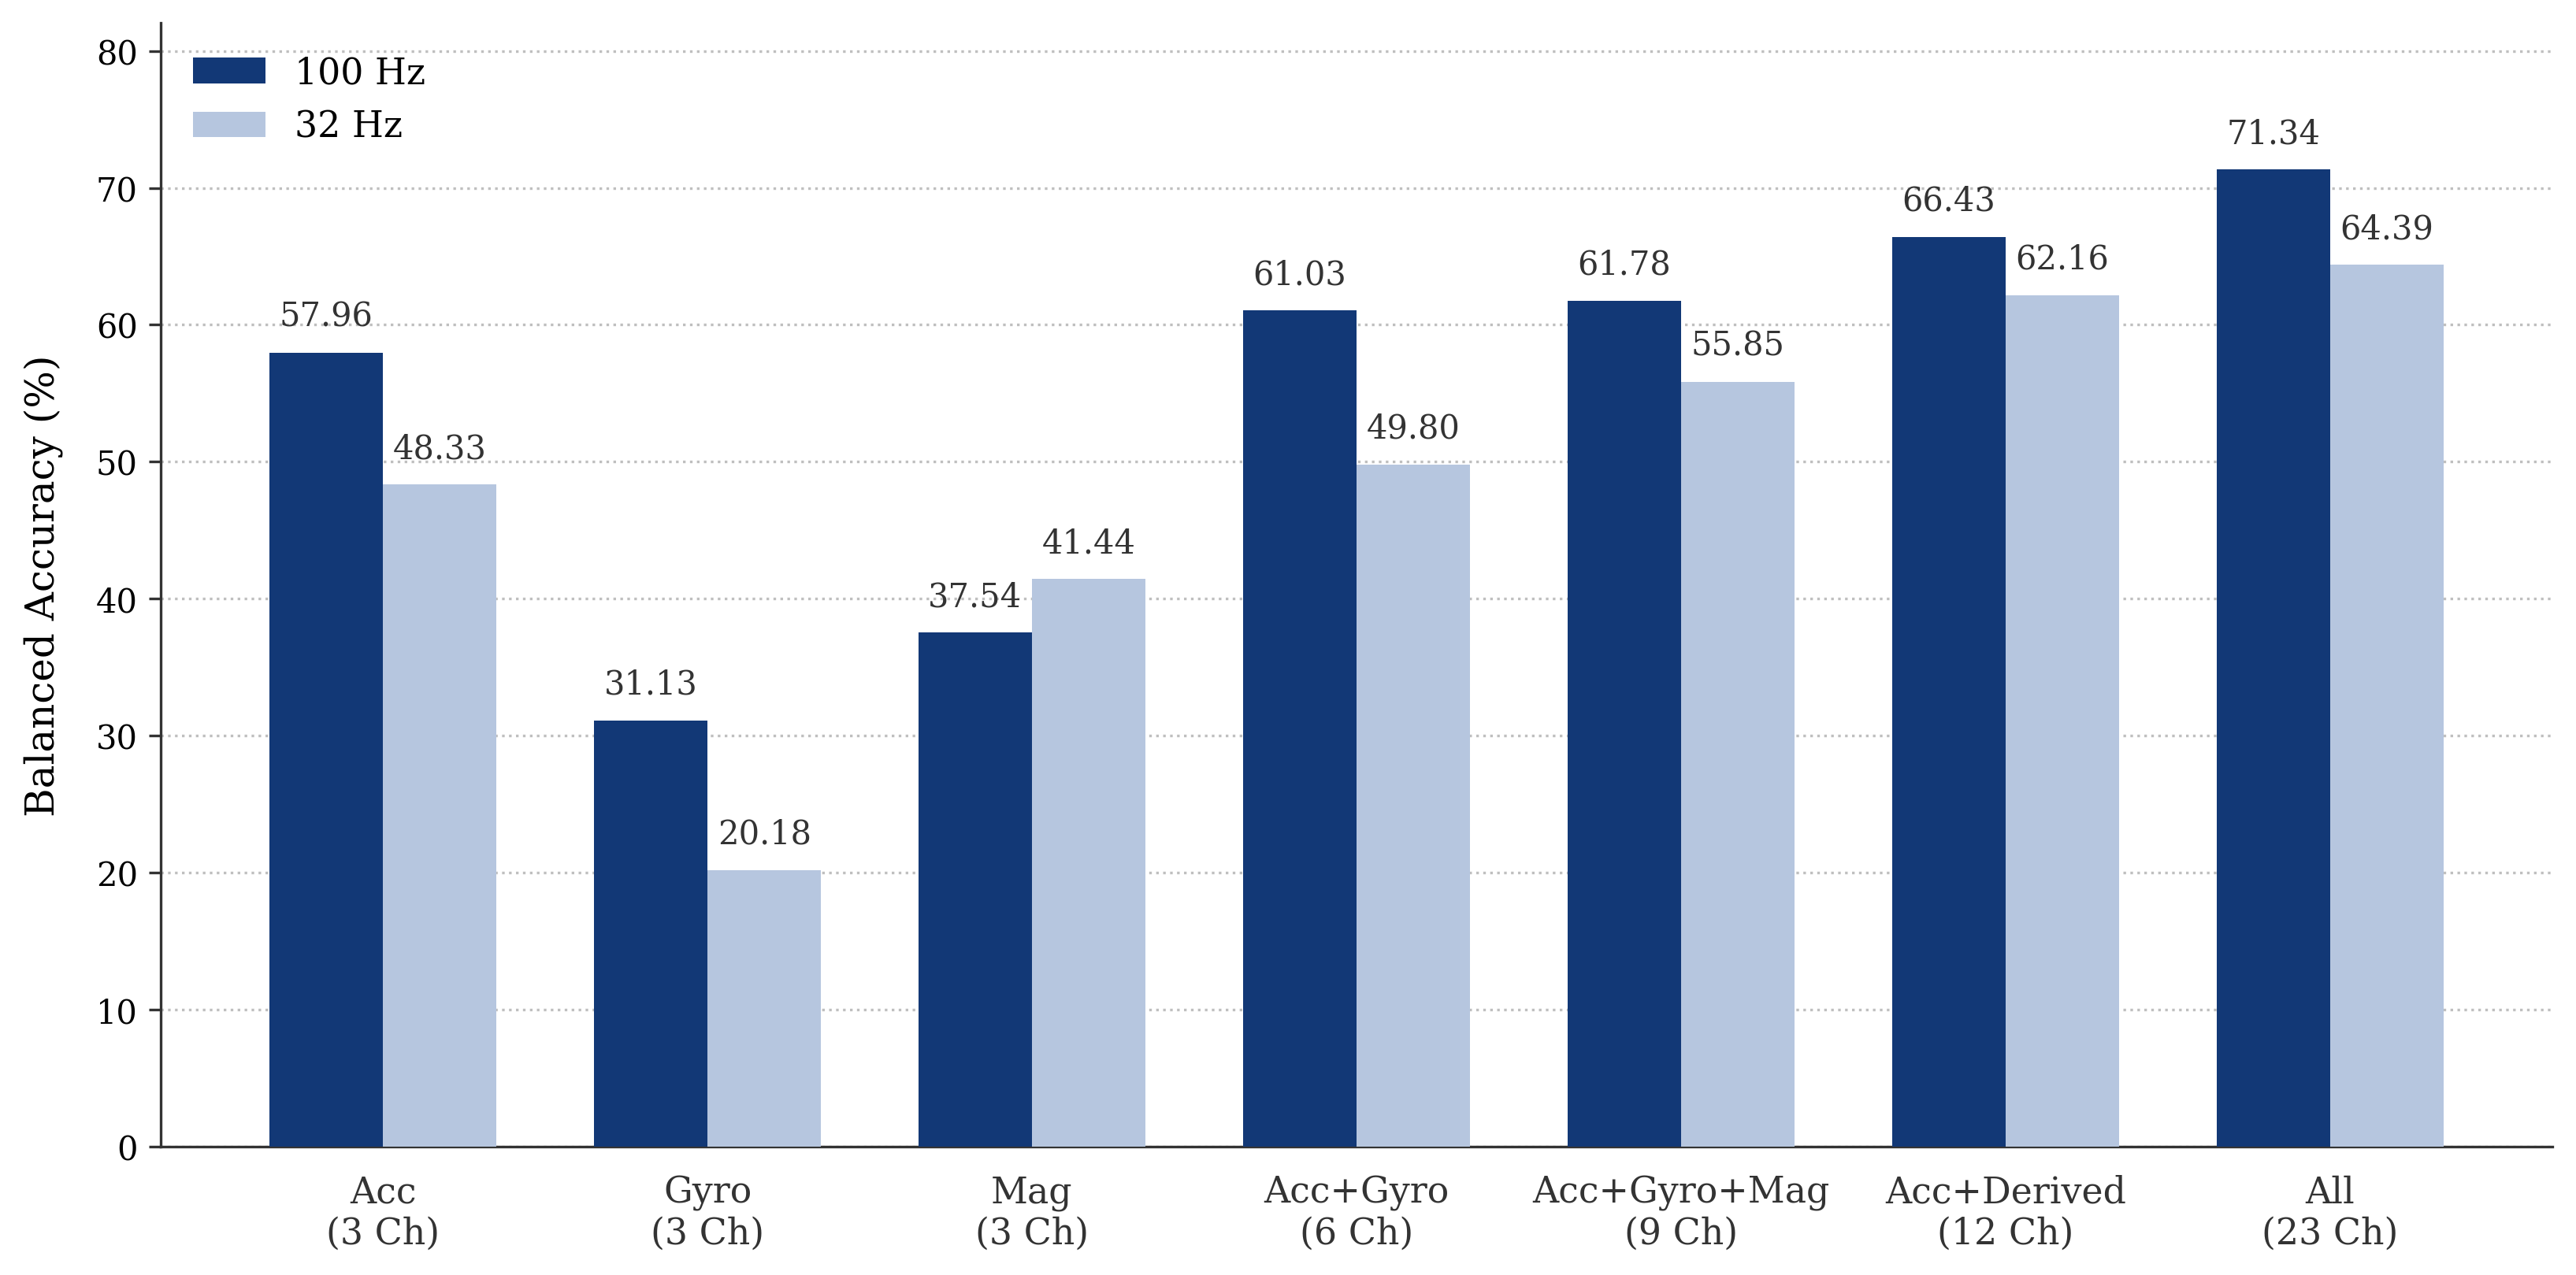

In [43]:
plt.rcParams['font.family'] = 'serif'

config_order = list(SENSOR_CONFIGS.keys())
modality_labels = [PLOT_LABELS[k] for k in config_order]

acc_100 = [results_sensor[100][m]['accuracy'] * 100 for m in config_order]
acc_32 = [results_sensor[32][m]['accuracy'] * 100 for m in config_order]

x = np.arange(len(modality_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 5.5), dpi=300)
color_100 = "#123876"
color_32 = "#B6C6DF"

rects1 = ax.bar(
    x - width/2,
    acc_100,
    width,
    label='100 Hz',
    color=color_100,
    edgecolor='none',
    zorder=3
)
rects2 = ax.bar(
    x + width/2,
    acc_32,
    width,
    label='32 Hz',
    color=color_32,
    edgecolor='none',
    zorder=3
)

ax.set_ylabel('Balanced Accuracy (%)', fontsize=12, labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(modality_labels, fontsize=11, color='#333333')
ax.set_ylim(0, max(max(acc_100), max(acc_32)) * 1.15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0, color='gray')
ax.tick_params(axis='y', labelsize=10, left=True, color='#333333')
ax.tick_params(axis='x', bottom=False, pad=5)

ax.legend(loc='upper left', frameon=False, fontsize=11)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f'{height:.2f}',
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 6),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=10,
            color='#333333'
        )

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/Figures/Figure_5_5_1_sensor_configuration_sampling_new.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Cross-dataset evaluation

Accelometer data only, 32 hz.

In [ ]:
UIS4ADL_PATH_32 = r"../Data/UiS4ADL/Processed/UiS4ADL_acc_32hz.csv"
PAAL_PATH_32 = r"../Data/PAAL_ADL/Processed/PAAL_ADL_32hz.csv"

UIS4ADL_32_df = pd.read_csv(UIS4ADL_PATH_32)
PAAL_32_df = pd.read_csv(PAAL_PATH_32)

print(f"UiS4ADL 32 Hz: {UIS4ADL_32_df.shape}")
print(f"PAAL 32 Hz: {PAAL_32_df.shape}")

acc_cols = ['accX[mg]', 'accY[mg]', 'accZ[mg]']

UiS4ADL 32 Hz: (2696625, 8)
PAAL 32 Hz: (1432173, 8)


In [ ]:
print("\nExtracting UiS4ADL...")
X_uis_acc_32, y_uis_acc_32, _, _ = feature_extractor.extract_features(
    data=UIS4ADL_32_df,
    method=METHOD,
    sensor_columns=acc_cols,
    window_seconds=WINDOW_SECONDS,
    overlap_ratio=OVERLAP_RATIO,
    fs=FS_32,
    strategy="retain_short"
)
y_uis_acc_32 = np.array(y_uis_acc_32)

print("Extracting PAAL...")
X_paal, y_paal, _, _ = feature_extractor.extract_features(
    data=PAAL_32_df,
    method=METHOD,
    sensor_columns=acc_cols,
    window_seconds=WINDOW_SECONDS,
    overlap_ratio=OVERLAP_RATIO,
    fs=FS_32,
    strategy="retain_short"
)
y_paal = np.array(y_paal)

all_embeddings_indexed_cross = np.zeros((max(all_classes) + 1, embeddings.shape[1]))
for cls, idx in class_to_embedding_idx.items():
    all_embeddings_indexed_cross[cls] = embeddings[idx]

# Helper function
def run_eval(X_train_src, y_train_src, X_test_tgt, y_test_tgt, seen_classes, unseen_classes):
    train_mask = np.isin(y_train_src, seen_classes)
    test_mask  = np.isin(y_test_tgt, unseen_classes)

    X_train, y_train = X_train_src[train_mask], y_train_src[train_mask]
    X_test,  y_test  = X_test_tgt[test_mask],  y_test_tgt[test_mask]

    unseen_idx = [class_to_embedding_idx[c] for c in unseen_classes]

    model = IP_SAE_MODEL(lambda_reg=LAMBDA, scale_features=True)
    model.fit(X_train, y_train, all_embeddings_indexed_cross, verbose=0)

    y_pred = model.predict_zsl(
        X_test,
        embeddings[unseen_idx],
        unseen_classes,
        n_runs=35
    )

    ba = balanced_accuracy_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred, labels=unseen_classes)

    class_recalls = {}
    for i, cls in enumerate(unseen_classes):
        n_samples = cm[i].sum()
        recall = cm[i, i] / n_samples if n_samples > 0 else 0.0
        class_recalls[cls] = {
            "recall": recall,
            "samples": int(n_samples)
        }

    return {
        "balanced_accuracy": ba,
        "y_test": y_test,
        "y_pred": y_pred,
        "cm": cm,
        "class_recalls": class_recalls
    }

res_uu, res_pp, res_up, res_pu = {}, {}, {}, {}

for k in k_vals:
    unseen_classes = ranking[:k]
    seen_classes = [c for c in all_classes if c not in unseen_classes]

    print(f"\nK = {k}")

    res_uu[k] = run_eval(
        X_uis_acc_32, y_uis_acc_32,
        X_uis_acc_32, y_uis_acc_32,
        seen_classes, unseen_classes
    )
    print(f"UiS → UiS: {res_uu[k]['balanced_accuracy']*100:.2f}%")

    res_pp[k] = run_eval(
        X_paal, y_paal,
        X_paal, y_paal,
        seen_classes, unseen_classes
    )
    print(f"PAAL → PAAL: {res_pp[k]['balanced_accuracy']*100:.2f}%")

    res_up[k] = run_eval(
        X_uis_acc_32, y_uis_acc_32,
        X_paal, y_paal,
        seen_classes, unseen_classes
    )
    print(f"UiS → PAAL: {res_up[k]['balanced_accuracy']*100:.2f}%")

    res_pu[k] = run_eval(
        X_paal, y_paal,
        X_uis_acc_32, y_uis_acc_32,
        seen_classes, unseen_classes
    )
    print(f"PAAL → UiS: {res_pu[k]['balanced_accuracy']*100:.2f}%")


Extracting UiS4ADL...

Extracting features: temporal_frequency
  Window: 4.0s
  Overlap: 0.0 (128 stride)
  Sampling rate: 32 Hz

Creating windows per fileID...
  Found 1441 files that are too short (30.86% of the available files)
  Created 20119 windows

Extracting features using method: temporal_frequency...
  Processing window 0/20119
                    1000/20119
                    2000/20119
                    3000/20119
                    4000/20119
                    5000/20119
                    6000/20119
                    7000/20119
                    8000/20119
                    9000/20119
                    10000/20119
                    11000/20119
                    12000/20119
                    13000/20119
                    14000/20119
                    15000/20119
                    16000/20119
                    17000/20119
                    18000/20119
                    19000/20119
                    20000/20119
  Feature shape: (20119, 36)

In [47]:
unseen_classes = ranking[:K]

print(f"{'Cls':<4} {'Activity':<22} {'UiS→UiS':>10} {'PAAL→PAAL':>12} {'UiS→PAAL':>11} {'PAAL→UiS':>11}")
print("-" * 78)

for cls in unseen_classes:
    activity = adl_dict_raw.get(str(cls), f"Class {cls}")[:22]

    r_uu = res_uu[K]['class_recalls'][cls]['recall'] * 100
    r_pp = res_pp[K]['class_recalls'][cls]['recall'] * 100
    r_up = res_up[K]['class_recalls'][cls]['recall'] * 100
    r_pu = res_pu[K]['class_recalls'][cls]['recall'] * 100

    print(f"{cls:<4} {activity:<22} {r_uu:>9.2f}% {r_pp:>11.2f}% {r_up:>10.2f}% {r_pu:>10.2f}%")

Cls  Activity                  UiS→UiS    PAAL→PAAL    UiS→PAAL    PAAL→UiS
------------------------------------------------------------------------------
17   type on keyboard           49.51%       93.95%      24.76%      36.45%
14   stand up                    8.63%        0.00%      54.02%       0.00%
11   put on glasses             67.90%       76.45%      79.15%      50.31%
9    put on shoe                77.65%       90.59%      50.10%      44.00%
24   washing dishes             60.58%       37.82%       4.11%      30.45%
5    brush teeth                33.62%        1.22%       8.15%       1.36%


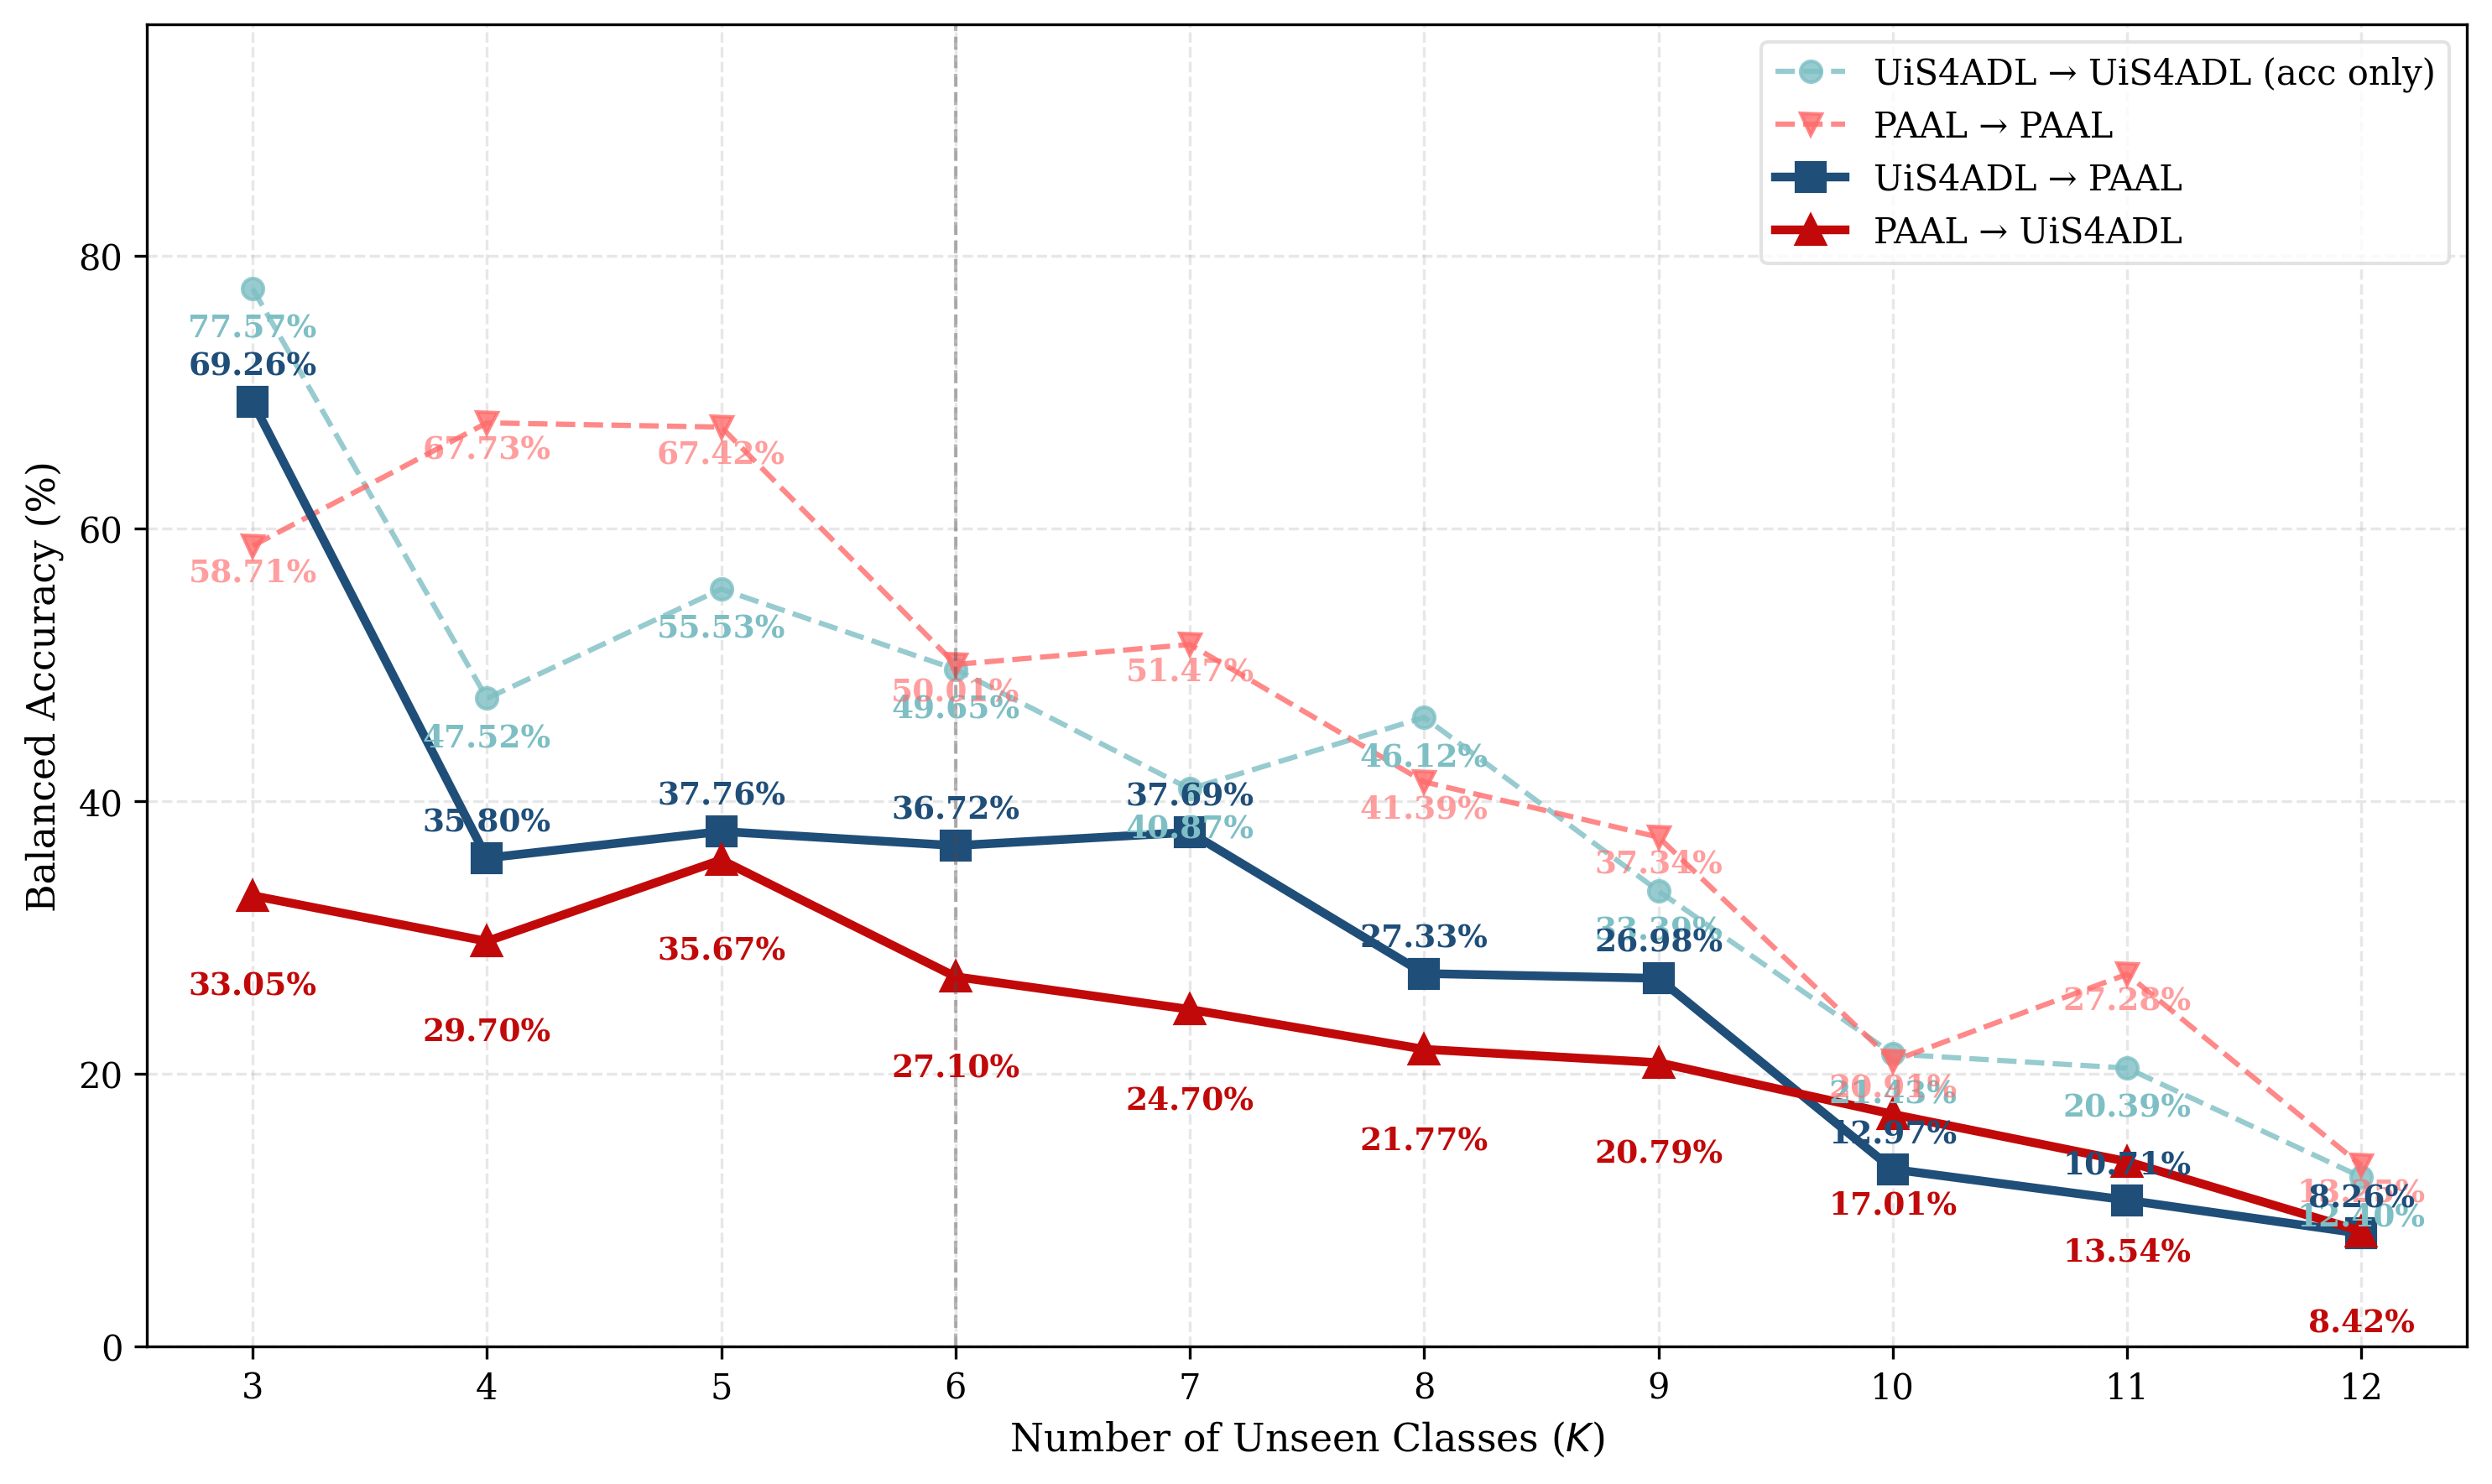

In [74]:
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

v_uu = [res_uu[k]['balanced_accuracy'] * 100 for k in k_vals]
v_pp = [res_pp[k]['balanced_accuracy'] * 100 for k in k_vals]
v_up = [res_up[k]['balanced_accuracy'] * 100 for k in k_vals]
v_pu = [res_pu[k]['balanced_accuracy'] * 100 for k in k_vals]

# Baselines (dashed, lighter)
ax.plot(k_vals, v_uu, 'o--', color="#7dbfc4", linewidth=1.5, markersize=6,
        alpha=0.8, label='UiS4ADL → UiS4ADL (acc only)')
ax.plot(k_vals, v_pp, 'v--', color="#FF6B6BA6", linewidth=1.5, markersize=6,
        alpha=0.8, label='PAAL → PAAL')

# Cross-dataset (solid, stronger)
ax.plot(k_vals, v_up, 's-', color='#1f4e79', linewidth=2.5, markersize=8,
        label='UiS4ADL → PAAL')
ax.plot(k_vals, v_pu, '^-', color="#c10909", linewidth=2.5, markersize=8,
        label='PAAL → UiS4ADL')

# Axes
ax.set_xlabel('Number of Unseen Classes ($K$)', fontsize=11)
ax.set_ylabel('Balanced Accuracy (%)', fontsize=11)
ax.set_xticks(k_vals)
ax.set_ylim(0, max(max(v_uu), max(v_pp), max(v_up), max(v_pu)) * 1.25)

# Grid
ax.grid(True, linestyle='--', alpha=0.3)

# Highlight K
ax.axvline(x=K, color="#504949", linestyle='--', linewidth=1.0, alpha=0.4)

# Legend
ax.legend(loc='upper right', frameon=True, fontsize=10, edgecolor='#dcdcdc')

# Value annotations
for k, val in zip(k_vals, v_uu):
    ax.text(k, val - 4.0, f'{val:.2f}%', ha='center', va='bottom',
            fontsize=9, color='#7dbfc4', fontweight='bold')

for k, val in zip(k_vals, v_pp):
    ax.text(k, val - 0.8, f'{val:.2f}%', ha='center', va='top',
            fontsize=9, color='#FF6B6BA6', fontweight='bold')

for k, val in zip(k_vals, v_up):
    ax.text(k, val + 1.5, f'{val:.2f}%', ha='center', va='bottom',
            fontsize=9, color='#1f4e79', fontweight='bold')

for k, val in zip(k_vals, v_pu):
    ax.text(k, val - 5.5, f'{val:.2f}%', ha='center', va='top',
            fontsize=9, color='#c10909', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/Figures/Figure_5_6_1_cross_dataset_new.pdf", bbox_inches='tight')
plt.show()

### Recording-level evaluation for the cross-dataset

In [ ]:
UIS4ADL_32_df_rec = pd.read_csv(UIS4ADL_PATH_32)
PAAL_32_df_rec = pd.read_csv(PAAL_PATH_32)


X_uis_rec, y_uis_rec, fileIDs_uis_rec, _ = feature_extractor.extract_features(
    data=UIS4ADL_32_df_rec,
    method=METHOD,
    sensor_columns=acc_cols,
    window_seconds=WINDOW_SECONDS,
    overlap_ratio=OVERLAP_RATIO,
    fs=FS_32,
    strategy="retain_short"
)
y_uis_rec = np.array(y_uis_rec)
fileIDs_uis_rec = np.array(fileIDs_uis_rec)

X_paal_rec, y_paal_rec, fileIDs_paal_rec, _ = feature_extractor.extract_features(
    data=PAAL_32_df_rec,
    method=METHOD,
    sensor_columns=acc_cols,
    window_seconds=WINDOW_SECONDS,
    overlap_ratio=OVERLAP_RATIO,
    fs=FS_32,
    strategy="retain_short"
)
y_paal_rec = np.array(y_paal_rec)
fileIDs_paal_rec = np.array(fileIDs_paal_rec)

all_embeddings_indexed_rec = np.zeros((max(all_classes) + 1, embeddings.shape[1]))
for cls, idx in class_to_embedding_idx.items():
    if cls in all_classes:
        all_embeddings_indexed_rec[cls] = embeddings[idx]



Extracting features: temporal_frequency
  Window: 4.0s
  Overlap: 0.0 (128 stride)
  Sampling rate: 32 Hz

Creating windows per fileID...
  Found 1441 files that are too short (30.86% of the available files)
  Created 20119 windows

Extracting features using method: temporal_frequency...
  Processing window 0/20119
                    1000/20119
                    2000/20119
                    3000/20119
                    4000/20119
                    5000/20119
                    6000/20119
                    7000/20119
                    8000/20119
                    9000/20119
                    10000/20119
                    11000/20119
                    12000/20119
                    13000/20119
                    14000/20119
                    15000/20119
                    16000/20119
                    17000/20119
                    18000/20119
                    19000/20119
                    20000/20119
  Feature shape: (20119, 36)

Extracting features: 

In [54]:
# Get segment predictions + averaged class scores without changing IP_SAE_MODEL
def predict_zsl_with_scores(model, X_test, unseen_embeddings, unseen_class_labels, n_runs=35, fixed_seed=True):
    if n_runs < 1:
        raise ValueError("n_runs must be at least 1.")

    if model.scale_features:
        X_test_scaled = model.scaler.transform(X_test)
    else:
        X_test_scaled = X_test

    S_projected = unseen_embeddings @ model.W

    avg_similarities = np.zeros((X_test_scaled.shape[0], len(unseen_class_labels)))

    for run in range(n_runs):
        rng = np.random.default_rng(seed=run) if fixed_seed else np.random.default_rng()

        random_indices = rng.choice(
            len(unseen_embeddings),
            size=X_test_scaled.shape[0],
            replace=True
        )
        random_semantics = unseen_embeddings[random_indices]

        X_test_aug = np.concatenate([X_test_scaled, random_semantics], axis=1)
        similarities = 1 - spatial.distance.cdist(X_test_aug, S_projected, 'cosine')
        avg_similarities += similarities

    avg_similarities /= n_runs

    pred_idx = np.argmax(avg_similarities, axis=1)
    y_pred = np.array([unseen_class_labels[idx] for idx in pred_idx])

    return y_pred, avg_similarities

In [ ]:
def get_file_level_predictions_score_avg(y_true, y_scores, fileIDs, class_labels):
    y_true_file = []
    y_pred_file = []

    for fid in np.unique(fileIDs):
        mask = (fileIDs == fid)

        true_label = Counter(y_true[mask]).most_common(1)[0][0]
        file_scores = y_scores[mask].mean(axis=0)

        pred_idx = np.argmax(file_scores)
        pred_label = class_labels[pred_idx]

        y_true_file.append(true_label)
        y_pred_file.append(pred_label)

    return np.array(y_true_file), np.array(y_pred_file)


def run_eval_cross_dataset_levels(X_train_src, y_train_src,
                                  X_test_tgt, y_test_tgt, fileIDs_tgt,
                                  seen_classes, unseen_classes):
    train_mask = np.isin(y_train_src, seen_classes)
    test_mask = np.isin(y_test_tgt, unseen_classes)

    X_train = X_train_src[train_mask]
    y_train = y_train_src[train_mask]

    X_test = X_test_tgt[test_mask]
    y_test = y_test_tgt[test_mask]
    fileIDs_test = fileIDs_tgt[test_mask]

    unseen_idx = [class_to_embedding_idx[c] for c in unseen_classes]
    unseen_embeddings = embeddings[unseen_idx]

    model = IP_SAE_MODEL(lambda_reg=LAMBDA, scale_features=True)
    model.fit(X_train, y_train, all_embeddings_indexed_rec, verbose=0)

    y_pred_seg, y_scores_seg = predict_zsl_with_scores(
        model,
        X_test,
        unseen_embeddings,
        unseen_classes,
        n_runs=35
    )

    ba_seg = balanced_accuracy_score(y_test, y_pred_seg)

    y_true_file, y_pred_file = get_file_level_predictions_score_avg(
        y_test,
        y_scores_seg,
        fileIDs_test,
        unseen_classes
    )
    ba_file = balanced_accuracy_score(y_true_file, y_pred_file)

    cm_seg = confusion_matrix(y_test, y_pred_seg, labels=unseen_classes)
    cm_file = confusion_matrix(y_true_file, y_pred_file, labels=unseen_classes)

    recalls_seg = {}
    recalls_file = {}

    for i, cls in enumerate(unseen_classes):
        n_seg = cm_seg[i].sum()
        n_file = cm_file[i].sum()

        recalls_seg[cls] = {
            'recall': cm_seg[i, i] / n_seg if n_seg > 0 else 0.0,
            'samples': int(n_seg)
        }
        recalls_file[cls] = {
            'recall': cm_file[i, i] / n_file if n_file > 0 else 0.0,
            'samples': int(n_file)
        }

    return {
        'balanced_accuracy_segment': ba_seg,
        'balanced_accuracy_file': ba_file,
        'class_recalls_segment': recalls_seg,
        'class_recalls_file': recalls_file,
        'cm_segment': cm_seg,
        'cm_file': cm_file,
        'y_test_segment': y_test,
        'y_pred_segment': y_pred_seg,
        'y_test_file': y_true_file,
        'y_pred_file': y_pred_file
    }

In [56]:
res_uu_levels = {}
res_pp_levels = {}
res_up_levels = {}
res_pu_levels = {}

for k in k_vals:
    unseen_classes = ranking[:k]
    seen_classes = [c for c in all_classes if c not in unseen_classes]

    print(f"\nK = {k}")

    res_uu_levels[k] = run_eval_cross_dataset_levels(
        X_uis_rec, y_uis_rec,
        X_uis_rec, y_uis_rec, fileIDs_uis_rec,
        seen_classes, unseen_classes
    )
    print(f"UiS → UiS: segment={res_uu_levels[k]['balanced_accuracy_segment']*100:.2f}% | "
          f"recording={res_uu_levels[k]['balanced_accuracy_file']*100:.2f}%")

    res_pp_levels[k] = run_eval_cross_dataset_levels(
        X_paal_rec, y_paal_rec,
        X_paal_rec, y_paal_rec, fileIDs_paal_rec,
        seen_classes, unseen_classes
    )
    print(f"PAAL → PAAL: segment={res_pp_levels[k]['balanced_accuracy_segment']*100:.2f}% | "
          f"recording={res_pp_levels[k]['balanced_accuracy_file']*100:.2f}%")

    res_up_levels[k] = run_eval_cross_dataset_levels(
        X_uis_rec, y_uis_rec,
        X_paal_rec, y_paal_rec, fileIDs_paal_rec,
        seen_classes, unseen_classes
    )
    print(f"UiS → PAAL: segment={res_up_levels[k]['balanced_accuracy_segment']*100:.2f}% | "
          f"recording={res_up_levels[k]['balanced_accuracy_file']*100:.2f}%")

    res_pu_levels[k] = run_eval_cross_dataset_levels(
        X_paal_rec, y_paal_rec,
        X_uis_rec, y_uis_rec, fileIDs_uis_rec,
        seen_classes, unseen_classes
    )
    print(f"PAAL → UiS: segment={res_pu_levels[k]['balanced_accuracy_segment']*100:.2f}% | "
          f"recording={res_pu_levels[k]['balanced_accuracy_file']*100:.2f}%")


K = 3
UiS → UiS: segment=77.57% | recording=84.34%
PAAL → PAAL: segment=55.17% | recording=56.63%
UiS → PAAL: segment=69.26% | recording=70.34%
PAAL → UiS: segment=32.00% | recording=34.06%

K = 4
UiS → UiS: segment=47.52% | recording=47.97%
PAAL → PAAL: segment=68.28% | recording=68.79%
UiS → PAAL: segment=35.80% | recording=36.72%
PAAL → UiS: segment=29.96% | recording=32.41%

K = 5
UiS → UiS: segment=55.53% | recording=57.87%
PAAL → PAAL: segment=68.16% | recording=69.24%
UiS → PAAL: segment=37.76% | recording=37.71%
PAAL → UiS: segment=35.74% | recording=37.74%

K = 6
UiS → UiS: segment=49.65% | recording=53.22%
PAAL → PAAL: segment=51.57% | recording=52.37%
UiS → PAAL: segment=36.72% | recording=35.66%
PAAL → UiS: segment=28.34% | recording=31.38%

K = 7
UiS → UiS: segment=40.87% | recording=43.94%
PAAL → PAAL: segment=51.16% | recording=52.72%
UiS → PAAL: segment=37.69% | recording=37.17%
PAAL → UiS: segment=25.02% | recording=28.67%

K = 8
UiS → UiS: segment=46.12% | recording=

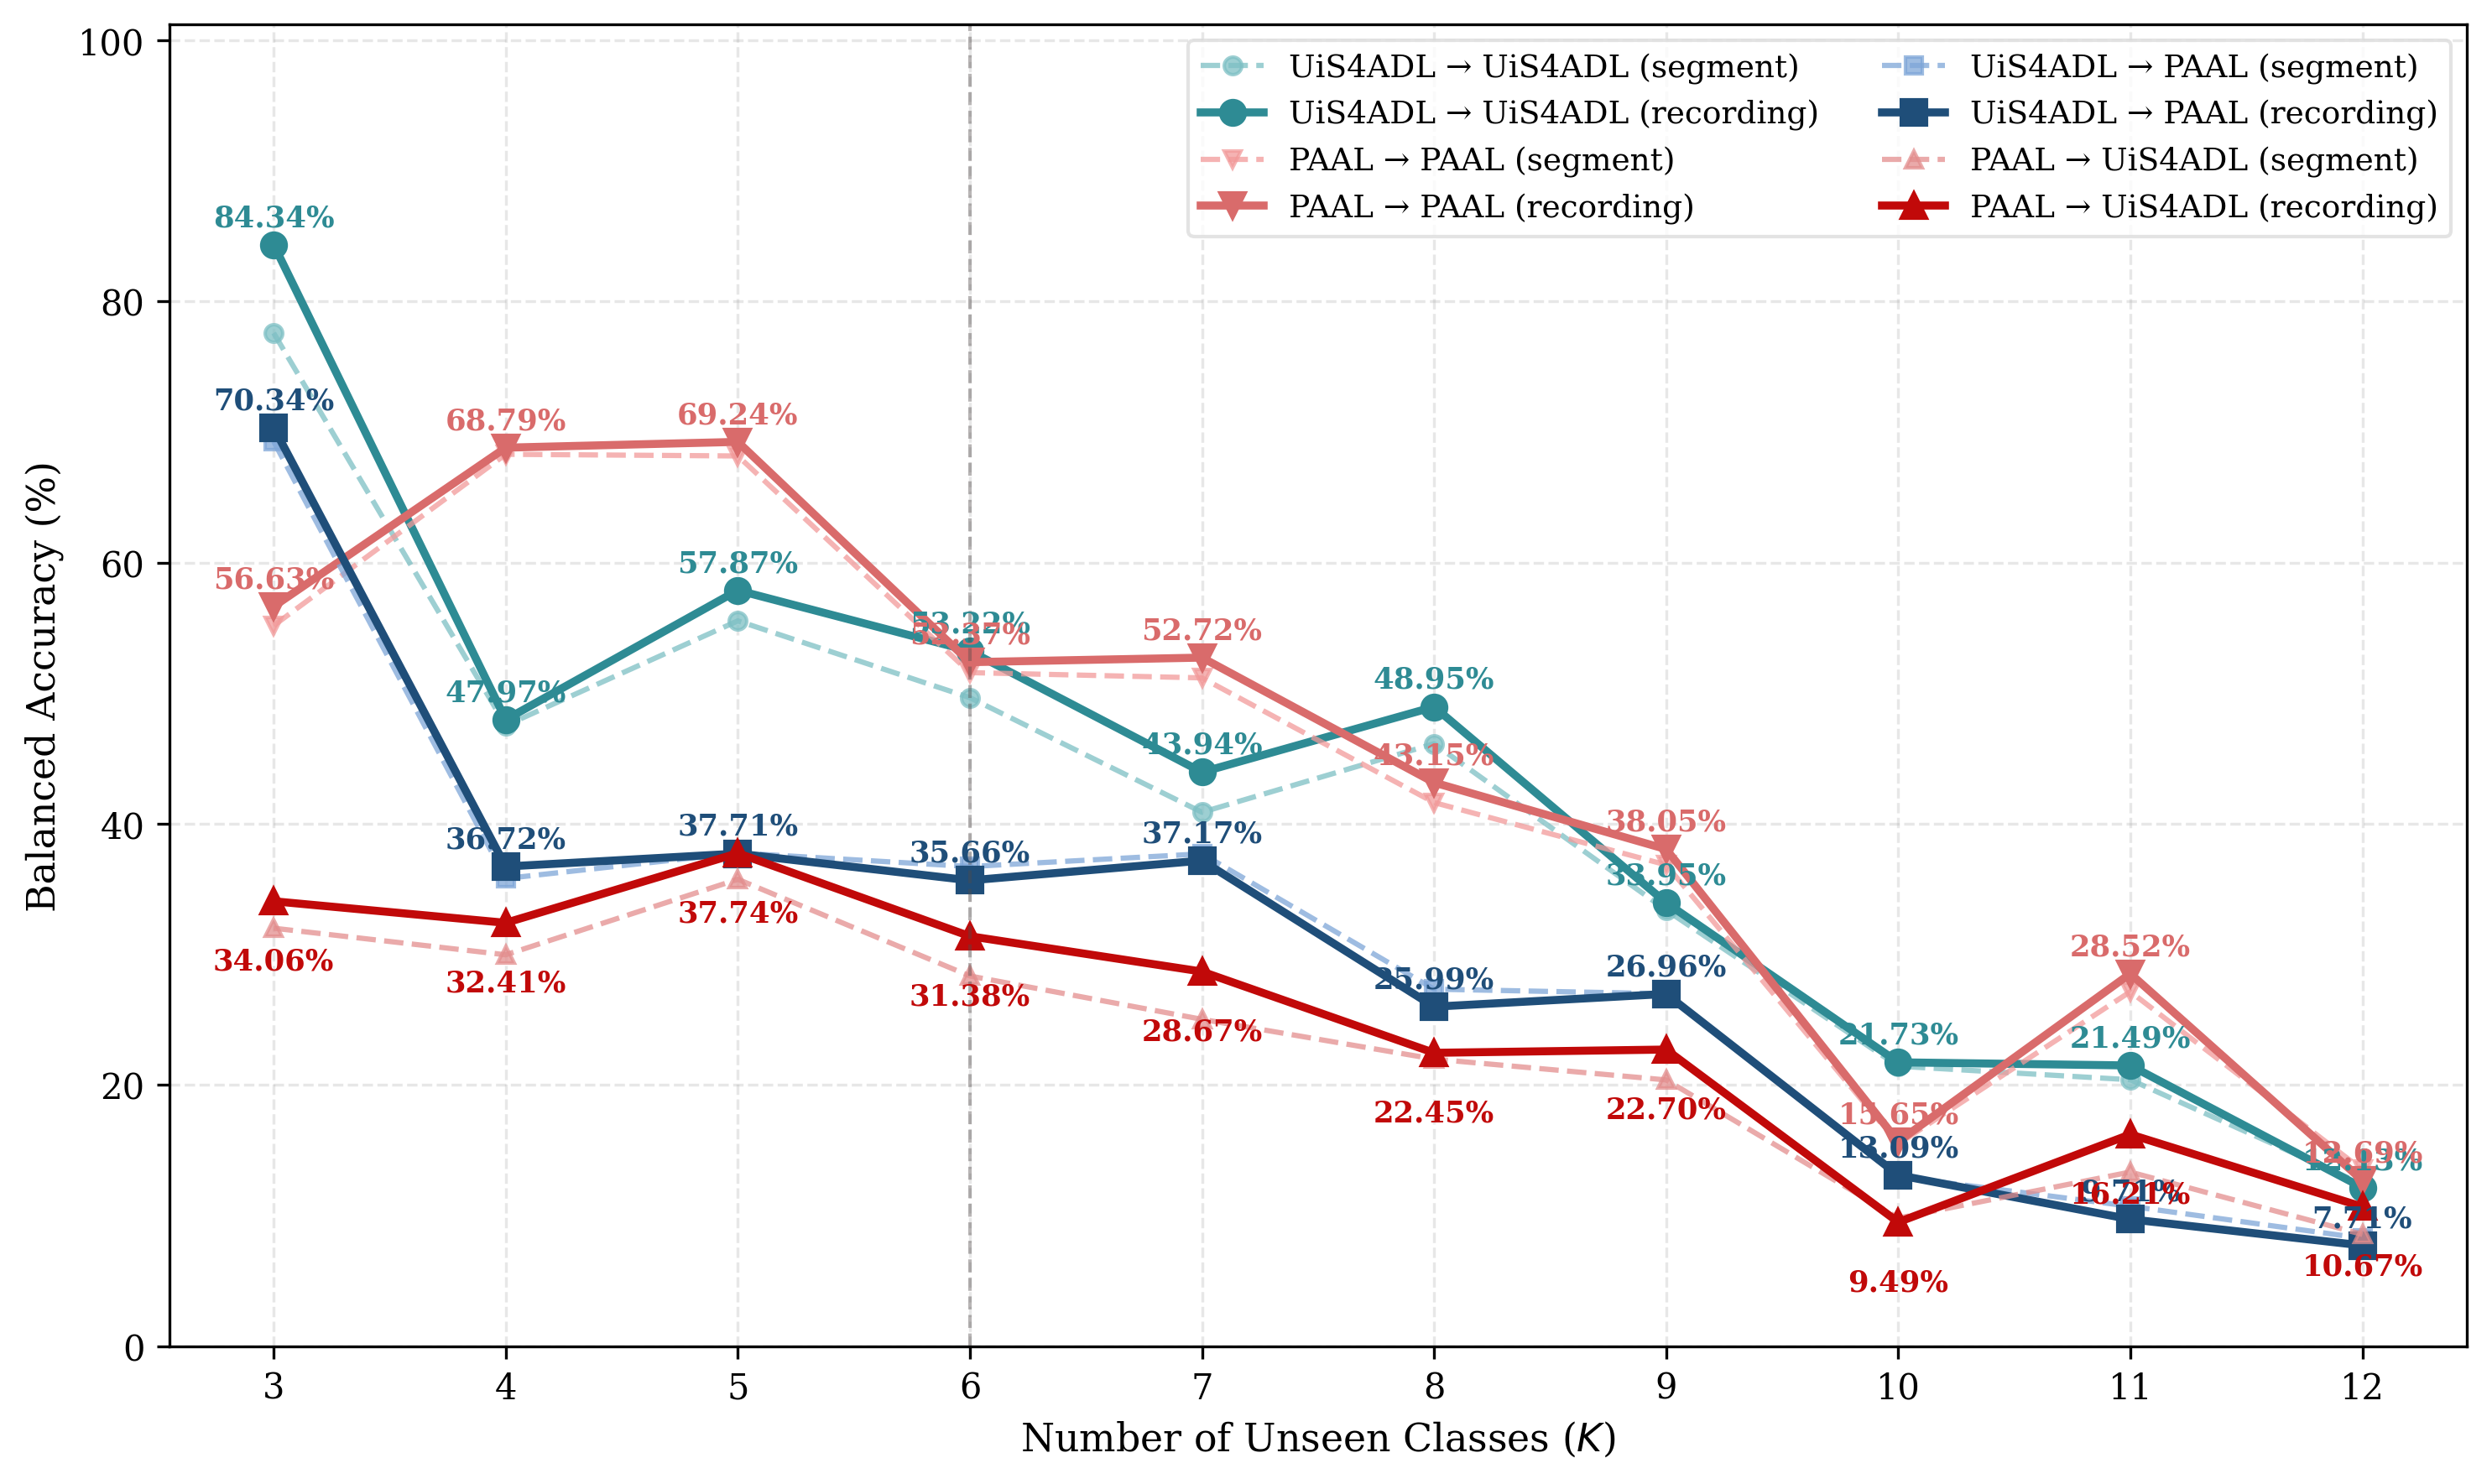

In [75]:
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

v_uu_seg  = [res_uu_levels[k]['balanced_accuracy_segment'] * 100 for k in k_vals]
v_pp_seg  = [res_pp_levels[k]['balanced_accuracy_segment'] * 100 for k in k_vals]
v_up_seg  = [res_up_levels[k]['balanced_accuracy_segment'] * 100 for k in k_vals]
v_pu_seg  = [res_pu_levels[k]['balanced_accuracy_segment'] * 100 for k in k_vals]

v_uu_file = [res_uu_levels[k]['balanced_accuracy_file'] * 100 for k in k_vals]
v_pp_file = [res_pp_levels[k]['balanced_accuracy_file'] * 100 for k in k_vals]
v_up_file = [res_up_levels[k]['balanced_accuracy_file'] * 100 for k in k_vals]
v_pu_file = [res_pu_levels[k]['balanced_accuracy_file'] * 100 for k in k_vals]

ax.plot(k_vals, v_uu_seg, 'o--', color="#7dbfc4", linewidth=1.5, markersize=5,
        alpha=0.75, label='UiS4ADL → UiS4ADL (segment)')
ax.plot(k_vals, v_uu_file, 'o-', color="#2e8b94", linewidth=2.3, markersize=7,
        label='UiS4ADL → UiS4ADL (recording)')

ax.plot(k_vals, v_pp_seg, 'v--', color="#f29a9a", linewidth=1.5, markersize=5,
        alpha=0.75, label='PAAL → PAAL (segment)')
ax.plot(k_vals, v_pp_file, 'v-', color="#d96b6b", linewidth=2.3, markersize=7,
        label='PAAL → PAAL (recording)')

ax.plot(k_vals, v_up_seg, 's--', color="#7ea6d8", linewidth=1.5, markersize=5,
        alpha=0.75, label='UiS4ADL → PAAL (segment)')
ax.plot(k_vals, v_up_file, 's-', color='#1f4e79', linewidth=2.3, markersize=7,
        label='UiS4ADL → PAAL (recording)')

ax.plot(k_vals, v_pu_seg, '^--', color="#e38e8e", linewidth=1.5, markersize=5,
        alpha=0.75, label='PAAL → UiS4ADL (segment)')
ax.plot(k_vals, v_pu_file, '^-', color="#c10909", linewidth=2.3, markersize=7,
        label='PAAL → UiS4ADL (recording)')

ax.set_xlabel('Number of Unseen Classes ($K$)', fontsize=11)
ax.set_ylabel('Balanced Accuracy (%)', fontsize=11)
ax.set_xticks(k_vals)
ax.set_ylim(
    0,
    max(
        max(v_uu_seg), max(v_pp_seg), max(v_up_seg), max(v_pu_seg),
        max(v_uu_file), max(v_pp_file), max(v_up_file), max(v_pu_file)
    ) * 1.20
)

ax.grid(True, linestyle='--', alpha=0.3)

ax.axvline(x=K, color="#504949", linestyle='--', linewidth=1.0, alpha=0.4)

ax.legend(loc='upper right', frameon=True, fontsize=9, edgecolor='#dcdcdc', ncol=2)

for k, val in zip(k_vals, v_uu_file):
    ax.text(k, val + 1.0, f'{val:.2f}%', ha='center', va='bottom',
            fontsize=8.5, color='#2e8b94', fontweight='bold')

for k, val in zip(k_vals, v_pp_file):
    ax.text(k, val + 1.0, f'{val:.2f}%', ha='center', va='bottom',
            fontsize=8.5, color='#d96b6b', fontweight='bold')

for k, val in zip(k_vals, v_up_file):
    ax.text(k, val + 1.0, f'{val:.2f}%', ha='center', va='bottom',
            fontsize=8.5, color='#1f4e79', fontweight='bold')

for k, val in zip(k_vals, v_pu_file):
    ax.text(k, val - 3.5, f'{val:.2f}%', ha='center', va='top',
            fontsize=8.5, color='#c10909', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/Figures/Figure_5_7_1_2_cross_dataset_file_level_new.pdf", bbox_inches='tight')
plt.show()

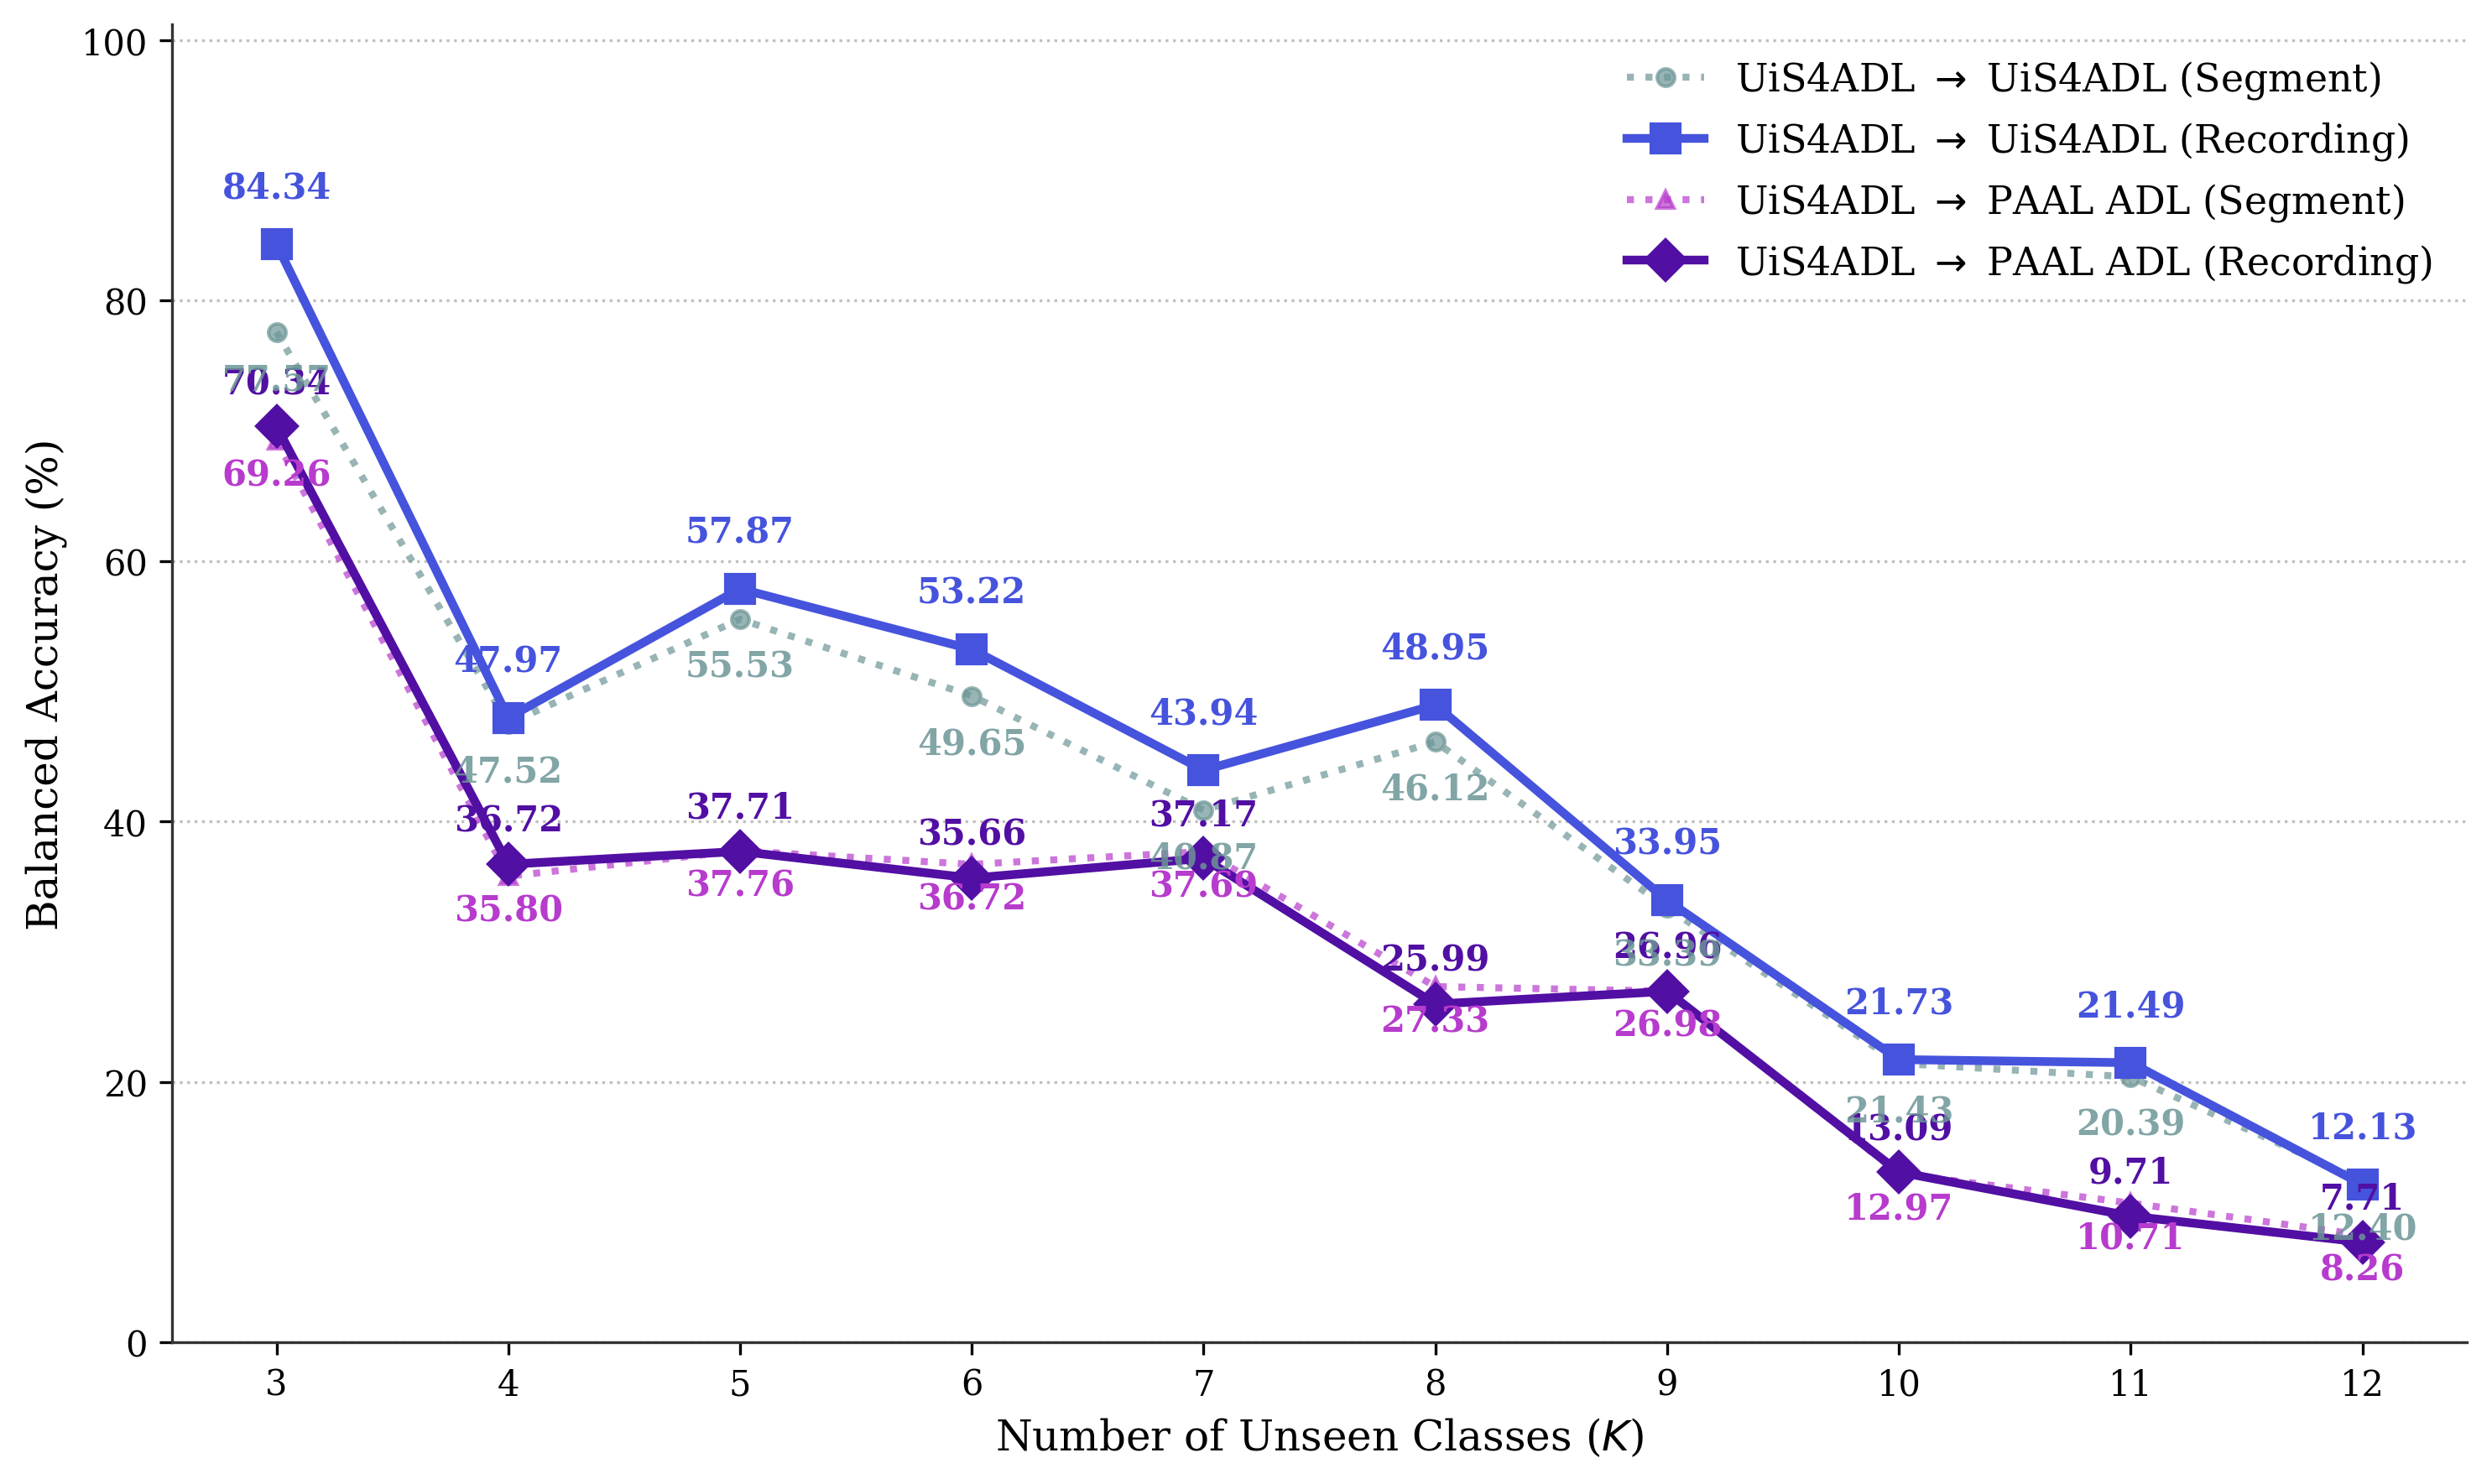

In [73]:
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Extract arrays
v_uu_seg = [res_uu_levels[k]['balanced_accuracy_segment'] * 100 for k in k_vals]
v_uu_file = [res_uu_levels[k]['balanced_accuracy_file'] * 100 for k in k_vals]
v_up_seg = [res_up_levels[k]['balanced_accuracy_segment'] * 100 for k in k_vals]
v_up_file = [res_up_levels[k]['balanced_accuracy_file'] * 100 for k in k_vals]

# Palette
color_uu_dark = "#4653DDFF"
color_uu_light = "#6C9596D8"
color_up_dark = "#520FA3"
color_up_light = "#B73BCD"

# UiS -> UiS
ax.plot(
    k_vals, v_uu_seg,
    'o:', color=color_uu_light, linewidth=2, markersize=5,
    alpha=0.7, label='UiS4ADL $\\rightarrow$ UiS4ADL (Segment)'
)
ax.plot(
    k_vals, v_uu_file,
    's-', color=color_uu_dark, linewidth=2.5, markersize=8,
    label='UiS4ADL $\\rightarrow$ UiS4ADL (Recording)'
)

# UiS -> PAAL
ax.plot(
    k_vals, v_up_seg,
    '^:', color=color_up_light, linewidth=2, markersize=5,
    alpha=0.7, label='UiS4ADL $\\rightarrow$ PAAL ADL (Segment)'
)
ax.plot(
    k_vals, v_up_file,
    'D-', color=color_up_dark, linewidth=2.5, markersize=8,
    label='UiS4ADL $\\rightarrow$ PAAL ADL (Recording)'
)

ax.set_xlabel('Number of Unseen Classes ($K$)', fontsize=12)
ax.set_ylabel('Balanced Accuracy (%)', fontsize=12)
ax.set_xticks(k_vals)
ax.set_ylim(0, max(max(v_uu_file), max(v_up_file)) * 1.2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')
ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0, color='gray')

ax.legend(loc='upper right', frameon=False, fontsize=11)

for k, val in zip(k_vals, v_uu_file):
    ax.text(
        k, val + 3, f'{val:.2f}',
        ha='center', va='bottom',
        fontsize=10, color=color_uu_dark, fontweight='bold'
    )

for k, val in zip(k_vals, v_up_file):
    ax.text(
        k, val + 2, f'{val:.2f}',
        ha='center', va='bottom',
        fontsize=10, color=color_up_dark, fontweight='bold'
    )

for k, val in zip(k_vals, v_uu_seg):
    ax.text(
        k, val - 5, f'{val:.2f}',
        ha='center', va='bottom',
        fontsize=10, color=color_uu_light, fontweight='bold'
    )

for k, val in zip(k_vals, v_up_seg):
    ax.text(
        k, val - 4, f'{val:.2f}',
        ha='center', va='bottom',
        fontsize=10, color=color_up_light, fontweight='bold'
    )

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/Figures/Figure_5_7_1_2_recording_level_with_mv_new.pdf", bbox_inches='tight')
plt.show()

### Recording-level evaluation

Comparing:
- Segment-level BA
- Recording-level BA by score averaging
- Recording-level BA by majority voting

In [60]:
UIS4ADL_100_df_rec = pd.read_csv(DATASET_PATH)
PAAL_32_df_rec = pd.read_csv(PAAL_PATH_32)

X_uis_rec, y_uis_rec, fileIDs_uis_rec, _ = feature_extractor.extract_features(
    data=UIS4ADL_100_df_rec,
    method=METHOD,
    sensor_columns=None,
    window_seconds=WINDOW_SECONDS,
    overlap_ratio=OVERLAP_RATIO,
    fs=FS,                         # 100 Hz UiS4ADL
    strategy="retain_short"
)
y_uis_rec = np.array(y_uis_rec)
fileIDs_uis_rec = np.array(fileIDs_uis_rec)

X_paal_rec, y_paal_rec, fileIDs_paal_rec, _ = feature_extractor.extract_features(
    data=PAAL_32_df_rec,
    method=METHOD,
    sensor_columns=None,
    window_seconds=WINDOW_SECONDS,
    overlap_ratio=OVERLAP_RATIO,
    fs=FS_32,                      # 32 Hz PAAL
    strategy="retain_short"
)
y_paal_rec = np.array(y_paal_rec)
fileIDs_paal_rec = np.array(fileIDs_paal_rec)

all_embeddings_indexed_within = np.zeros((max(all_classes) + 1, embeddings.shape[1]))
for cls, idx in class_to_embedding_idx.items():
    if cls in all_classes:
        all_embeddings_indexed_within[cls] = embeddings[idx]


Extracting features: temporal_frequency
  Window: 4.0s
  Overlap: 0.0 (400 stride)
  Sampling rate: 100 Hz

Creating windows per fileID...
  Found 1445 files that are too short (30.94% of the available files)
  Created 20103 windows

Extracting features using method: temporal_frequency...
  Processing window 0/20103
                    1000/20103
                    2000/20103
                    3000/20103
                    4000/20103
                    5000/20103
                    6000/20103
                    7000/20103
                    8000/20103
                    9000/20103
                    10000/20103
                    11000/20103
                    12000/20103
                    13000/20103
                    14000/20103
                    15000/20103
                    16000/20103
                    17000/20103
                    18000/20103
                    19000/20103
                    20000/20103
  Feature shape: (20103, 276)

Extracting features

In [ ]:
def get_file_level_predictions_majority_vote(y_true, y_pred_seg, fileIDs):
    y_true_file = []
    y_pred_file = []

    for fid in np.unique(fileIDs):
        mask = (fileIDs == fid)

        true_label = Counter(y_true[mask]).most_common(1)[0][0]
        pred_label = Counter(y_pred_seg[mask]).most_common(1)[0][0]

        y_true_file.append(true_label)
        y_pred_file.append(pred_label)

    return np.array(y_true_file), np.array(y_pred_file)


def run_eval_within_dataset_recording(X_all, y_all, fileIDs_all, unseen_classes):
    seen_classes = [c for c in all_classes if c not in unseen_classes]

    train_mask = np.isin(y_all, seen_classes)
    test_mask = np.isin(y_all, unseen_classes)

    X_train = X_all[train_mask]
    y_train = y_all[train_mask]

    X_test = X_all[test_mask]
    y_test = y_all[test_mask]
    fileIDs_test = fileIDs_all[test_mask]

    unseen_idx = [class_to_embedding_idx[c] for c in unseen_classes]
    unseen_embeddings = embeddings[unseen_idx]

    model = IP_SAE_MODEL(lambda_reg=LAMBDA, scale_features=True)
    model.fit(X_train, y_train, all_embeddings_indexed_within, verbose=0)

    y_pred_seg, y_scores_seg = predict_zsl_with_scores(
        model,
        X_test,
        unseen_embeddings,
        unseen_classes,
        n_runs=35
    )

    ba_seg = balanced_accuracy_score(y_test, y_pred_seg)

    y_true_file_score, y_pred_file_score = get_file_level_predictions_score_avg(
        y_test, y_scores_seg, fileIDs_test, unseen_classes
    )
    ba_file_score = balanced_accuracy_score(y_true_file_score, y_pred_file_score)

    y_true_file_mv, y_pred_file_mv = get_file_level_predictions_majority_vote(
        y_test, y_pred_seg, fileIDs_test
    )
    ba_file_mv = balanced_accuracy_score(y_true_file_mv, y_pred_file_mv)

    return {
        'balanced_accuracy_segment': ba_seg,
        'balanced_accuracy_file_score': ba_file_score,
        'balanced_accuracy_file_mv': ba_file_mv
    }

In [62]:
# Run within-dataset evaluation for UiS4ADL and PAAL
res_within_recording = {
    'UiS4ADL': {},
    'PAAL_ADL': {}
}

for k in k_vals:
    unseen_classes = ranking[:k]

    res_within_recording['UiS4ADL'][k] = run_eval_within_dataset_recording(
        X_uis_rec, y_uis_rec, fileIDs_uis_rec, unseen_classes
    )

    res_within_recording['PAAL_ADL'][k] = run_eval_within_dataset_recording(
        X_paal_rec, y_paal_rec, fileIDs_paal_rec, unseen_classes
    )

    print(
        f"K={k:<2} | "
        f"UiS seg={res_within_recording['UiS4ADL'][k]['balanced_accuracy_segment']*100:6.2f}% | "
        f"UiS score={res_within_recording['UiS4ADL'][k]['balanced_accuracy_file_score']*100:6.2f}% | "
        f"UiS mv={res_within_recording['UiS4ADL'][k]['balanced_accuracy_file_mv']*100:6.2f}% || "
        f"PAAL seg={res_within_recording['PAAL_ADL'][k]['balanced_accuracy_segment']*100:6.2f}% | "
        f"PAAL score={res_within_recording['PAAL_ADL'][k]['balanced_accuracy_file_score']*100:6.2f}% | "
        f"PAAL mv={res_within_recording['PAAL_ADL'][k]['balanced_accuracy_file_mv']*100:6.2f}%"
    )

K=3  | UiS seg= 85.39% | UiS score= 88.11% | UiS mv= 86.86% || PAAL seg= 58.52% | PAAL score= 59.86% | PAAL mv= 58.79%
K=4  | UiS seg= 65.38% | UiS score= 67.50% | UiS mv= 67.15% || PAAL seg= 67.22% | PAAL score= 68.19% | PAAL mv= 66.92%
K=5  | UiS seg= 67.25% | UiS score= 70.23% | UiS mv= 68.48% || PAAL seg= 71.80% | PAAL score= 72.66% | PAAL mv= 71.49%
K=6  | UiS seg= 71.34% | UiS score= 75.16% | UiS mv= 74.62% || PAAL seg= 52.12% | PAAL score= 52.94% | PAAL mv= 51.77%
K=7  | UiS seg= 57.16% | UiS score= 59.28% | UiS mv= 58.55% || PAAL seg= 51.20% | PAAL score= 52.91% | PAAL mv= 51.36%
K=8  | UiS seg= 47.32% | UiS score= 48.78% | UiS mv= 48.89% || PAAL seg= 40.61% | PAAL score= 41.82% | PAAL mv= 39.53%
K=9  | UiS seg= 38.86% | UiS score= 39.40% | UiS mv= 39.52% || PAAL seg= 36.57% | PAAL score= 37.75% | PAAL mv= 36.19%
K=10 | UiS seg= 25.92% | UiS score= 27.27% | UiS mv= 27.17% || PAAL seg= 10.98% | PAAL score=  9.93% | PAAL mv= 11.43%
K=11 | UiS seg= 23.17% | UiS score= 24.39% | UiS

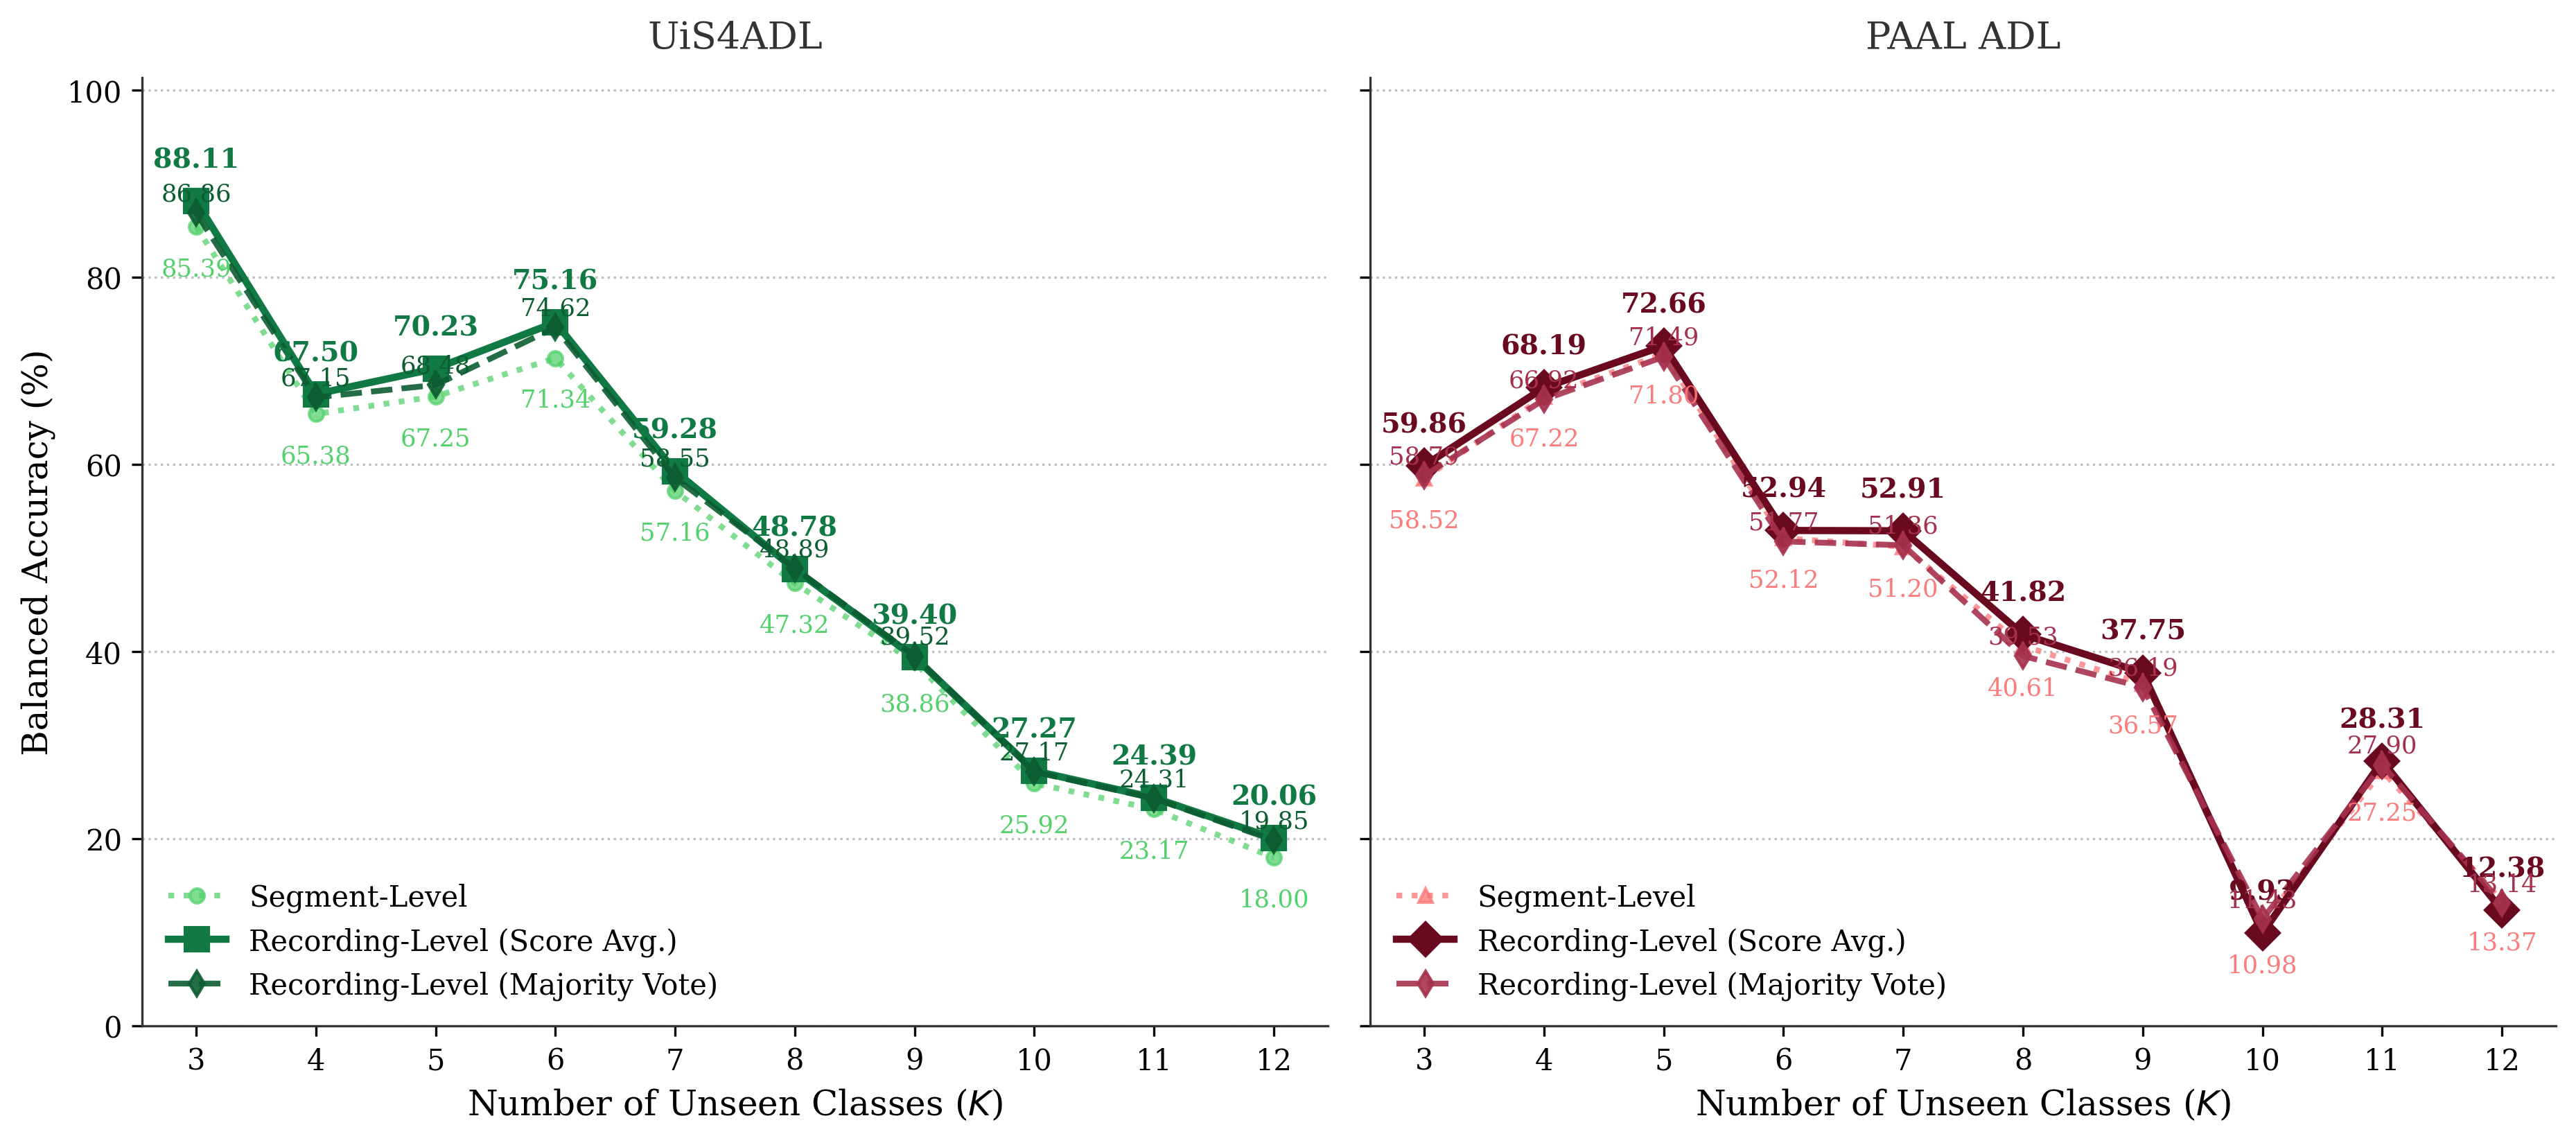

In [ ]:
plt.rcParams['font.family'] = 'serif'

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6), sharey=True, dpi=300)
ax1, ax2 = axes

uis_seg = [res_within_recording['UiS4ADL'][k]['balanced_accuracy_segment'] * 100 for k in k_vals]
uis_score = [res_within_recording['UiS4ADL'][k]['balanced_accuracy_file_score'] * 100 for k in k_vals]
uis_mv = [res_within_recording['UiS4ADL'][k]['balanced_accuracy_file_mv'] * 100 for k in k_vals]

paal_seg = [res_within_recording['PAAL_ADL'][k]['balanced_accuracy_segment'] * 100 for k in k_vals]
paal_score = [res_within_recording['PAAL_ADL'][k]['balanced_accuracy_file_score'] * 100 for k in k_vals]
paal_mv = [res_within_recording['PAAL_ADL'][k]['balanced_accuracy_file_mv'] * 100 for k in k_vals]

color_uis_dark = "#117943"
color_uis_light = "#54D16D"
color_uis_mid = "#0C5D31"

color_paal_dark = "#6A0A21"
color_paal_light = "#FB7575F2"
color_paal_mid = "#A6314E"

# UiS4ADL
ax1.plot(k_vals, uis_seg, 'o:', color=color_uis_light, linewidth=2, markersize=5,
         alpha=0.75, label='Segment-Level')
ax1.plot(k_vals, uis_score, 's-', color=color_uis_dark, linewidth=2.5, markersize=8,
         label='Recording-Level (Score Avg.)')
ax1.plot(k_vals, uis_mv, 'd--', color=color_uis_mid, linewidth=2.0, markersize=6,
         alpha=0.9, label='Recording-Level (Majority Vote)')

ax1.set_title('UiS4ADL', fontsize=13, color='#333333', pad=10)
ax1.set_xlabel('Number of Unseen Classes ($K$)', fontsize=12)
ax1.set_ylabel('Balanced Accuracy (%)', fontsize=12)

for k, val in zip(k_vals, uis_score):
    ax1.text(k, val + 3.0, f'{val:.2f}', ha='center', va='bottom',
             fontsize=9.5, color=color_uis_dark, fontweight='bold')
for k, val in zip(k_vals, uis_mv):
    ax1.text(k, val + 0.8, f'{val:.2f}', ha='center', va='bottom',
             fontsize=8.5, color=color_uis_mid)
for k, val in zip(k_vals, uis_seg):
    ax1.text(k, val - 3.2, f'{val:.2f}', ha='center', va='top',
             fontsize=8.5, color=color_uis_light)

# PAAL ADL
ax2.plot(k_vals, paal_seg, '^:', color=color_paal_light, linewidth=2, markersize=5,
         alpha=0.75, label='Segment-Level')
ax2.plot(k_vals, paal_score, 'D-', color=color_paal_dark, linewidth=2.5, markersize=8,
         label='Recording-Level (Score Avg.)')
ax2.plot(k_vals, paal_mv, 'd--', color=color_paal_mid, linewidth=2.0, markersize=6,
         alpha=0.9, label='Recording-Level (Majority Vote)')

ax2.set_title('PAAL ADL', fontsize=13, color='#333333', pad=10)
ax2.set_xlabel('Number of Unseen Classes ($K$)', fontsize=12)

for k, val in zip(k_vals, paal_score):
    ax2.text(k, val + 3.0, f'{val:.2f}', ha='center', va='bottom',
             fontsize=9.5, color=color_paal_dark, fontweight='bold')
for k, val in zip(k_vals, paal_mv):
    ax2.text(k, val + 0.8, f'{val:.2f}', ha='center', va='bottom',
             fontsize=8.5, color=color_paal_mid)
for k, val in zip(k_vals, paal_seg):
    ax2.text(k, val - 3.2, f'{val:.2f}', ha='center', va='top',
             fontsize=8.5, color=color_paal_light)

ymax = max(max(uis_score), max(uis_mv), max(paal_score), max(paal_mv)) * 1.15

for ax in axes:
    ax.set_xticks(k_vals)
    ax.set_ylim(0, ymax)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0, color='gray')
    ax.legend(loc='lower left', frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/Figures/Figure_5_7_1_3_within_dataset_score_vs_mv_new.pdf", bbox_inches='tight')
plt.show()

### GZSL experiment

Measure the effect of calibration parameter

In [66]:
all_embeddings_indexed_gzsl = np.zeros((max(all_classes) + 1, embeddings.shape[1]))
for cls, idx in class_to_embedding_idx.items():
    if cls in all_classes:
        all_embeddings_indexed_gzsl[cls] = embeddings[idx]

valid_all_class_indices_gzsl = [class_to_embedding_idx[cls] for cls in all_classes]
valid_all_embeddings_gzsl = embeddings[valid_all_class_indices_gzsl]

In [67]:
# Metric helper
def calculate_gzsl_metrics(y_true, y_pred, seen_classes, unseen_classes):
    mask_s = np.isin(y_true, seen_classes)
    mask_u = np.isin(y_true, unseen_classes)

    acc_s = balanced_accuracy_score(y_true[mask_s], y_pred[mask_s]) if np.any(mask_s) else 0.0
    acc_u = balanced_accuracy_score(y_true[mask_u], y_pred[mask_u]) if np.any(mask_u) else 0.0
    hm = (2 * acc_s * acc_u) / (acc_s + acc_u) if (acc_s + acc_u) > 0 else 0.0

    return acc_s, acc_u, hm


# Dataset config for this experiment
DATASETS_CONFIG_GZSL = {
    'UiS4ADL': {
        'path': DATASET_PATH,   # ../Data/UiS4ADL/Processed/UiS4ADL_100hz.csv
        'fs': FS,               # 100
    },
    'PAAL_ADL': {
        'path': PAAL_PATH_32,   # ../Data/PAAL_ADL/Processed/PAAL_ADL_32hz.csv
        'fs': FS_32,            # 32
    }
}

final_results_gzsl = {}

for ds_key, ds_info in DATASETS_CONFIG_GZSL.items():
    print(f"Processing dataset: {ds_key} (GZSL)")

    data_gzsl = pd.read_csv(ds_info['path'])

    X_gzsl, y_gzsl, fileIDs_gzsl, _ = feature_extractor.extract_features(
        data=data_gzsl,
        method=METHOD,
        sensor_columns=None,
        window_seconds=WINDOW_SECONDS,
        overlap_ratio=OVERLAP_RATIO,
        fs=ds_info['fs'],
        strategy="retain_short"
    )

    X_all_gzsl = np.array(X_gzsl)
    y_all_gzsl = np.array(y_gzsl)
    fileIDs_all_gzsl = np.array(fileIDs_gzsl)

    results_hm_0 = []
    results_hm_4 = []

    for k in k_vals:
        unseen_classes = ranking[:k]
        seen_classes = [c for c in all_classes if c not in unseen_classes]

        unseen_mask = np.isin(y_all_gzsl, unseen_classes)
        X_test_unseen = X_all_gzsl[unseen_mask]
        y_test_unseen = y_all_gzsl[unseen_mask]

        seen_mask = np.isin(y_all_gzsl, seen_classes)
        X_seen = X_all_gzsl[seen_mask]
        y_seen = y_all_gzsl[seen_mask]
        fileIDs_seen = fileIDs_all_gzsl[seen_mask]

        sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

        folds_hm_0 = []
        folds_hm_4 = []

        for train_idx, test_seen_idx in sgkf.split(X_seen, y_seen, groups=fileIDs_seen):
            X_train = X_seen[train_idx]
            y_train = y_seen[train_idx]
            X_test_seen = X_seen[test_seen_idx]
            y_test_seen = y_seen[test_seen_idx]

            X_test = np.vstack((X_test_seen, X_test_unseen))
            y_test = np.concatenate((y_test_seen, y_test_unseen))
            
            model_gzsl = IP_SAE_MODEL(lambda_reg=LAMBDA, scale_features=True)
            model_gzsl.fit(X_train, y_train, all_embeddings_indexed_gzsl, verbose=0)

            # Uncalibrated
            y_pred_0 = model_gzsl.predict_gzsl(
                X_test,
                valid_all_embeddings_gzsl,
                all_classes,
                seen_classes,
                gamma=0.0,
                n_runs=35
            )
            _, _, hm_0 = calculate_gzsl_metrics(y_test, y_pred_0, seen_classes, unseen_classes)
            folds_hm_0.append(hm_0)

            # Calibrated
            y_pred_4 = model_gzsl.predict_gzsl(
                X_test,
                valid_all_embeddings_gzsl,
                all_classes,
                seen_classes,
                gamma=0.4,
                n_runs=35
            )
            _, _, hm_4 = calculate_gzsl_metrics(y_test, y_pred_4, seen_classes, unseen_classes)
            folds_hm_4.append(hm_4)

        avg_hm_0 = np.mean(folds_hm_0)
        avg_hm_4 = np.mean(folds_hm_4)

        results_hm_0.append(avg_hm_0)
        results_hm_4.append(avg_hm_4)

        print(f"K={k:<2} | Uncalibrated (γ=0.0): {avg_hm_0*100:.2f}% | Calibrated (γ=0.4): {avg_hm_4*100:.2f}%")

    final_results_gzsl[ds_key] = {
        'hm_0': results_hm_0,
        'hm_4': results_hm_4
    }

Processing dataset: UiS4ADL (GZSL)

Extracting features: temporal_frequency
  Window: 4.0s
  Overlap: 0.0 (400 stride)
  Sampling rate: 100 Hz

Creating windows per fileID...
  Found 1445 files that are too short (30.94% of the available files)
  Created 20103 windows

Extracting features using method: temporal_frequency...
  Processing window 0/20103
                    1000/20103
                    2000/20103
                    3000/20103
                    4000/20103
                    5000/20103
                    6000/20103
                    7000/20103
                    8000/20103
                    9000/20103
                    10000/20103
                    11000/20103
                    12000/20103
                    13000/20103
                    14000/20103
                    15000/20103
                    16000/20103
                    17000/20103
                    18000/20103
                    19000/20103
                    20000/20103
  Feature shape

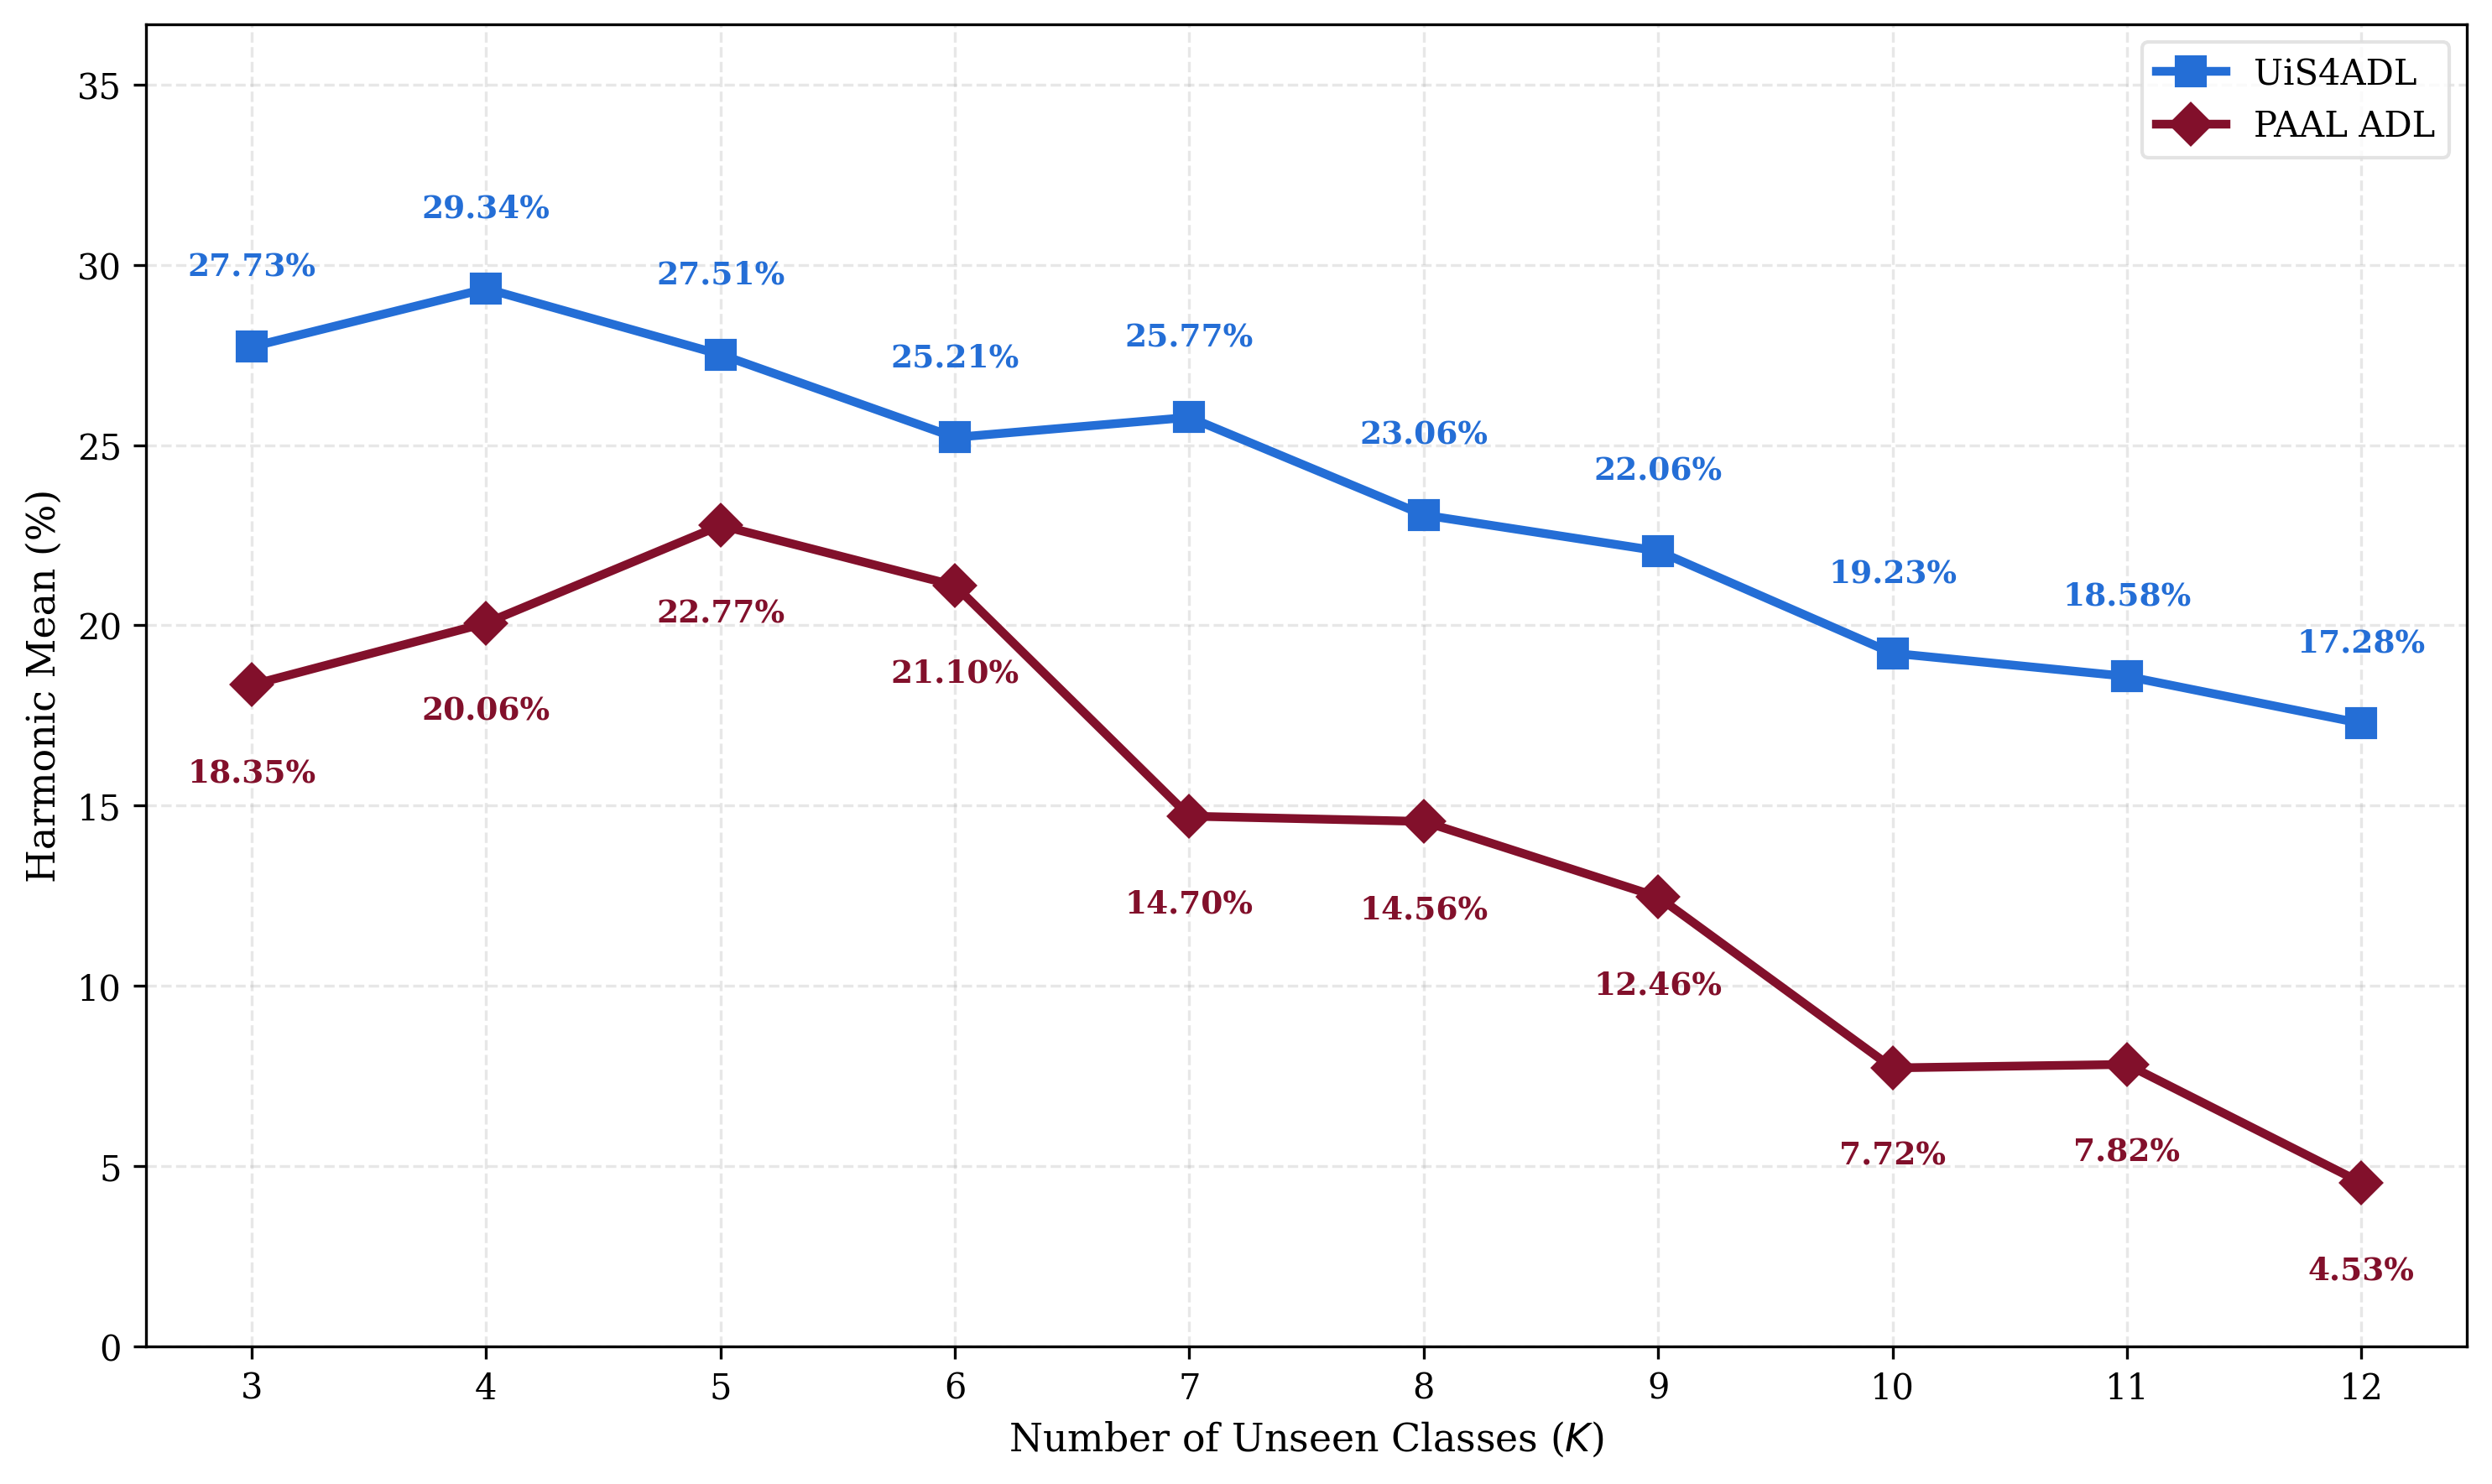

In [69]:
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

color_uis_dark = "#246ED6"
color_paal_dark = "#82102B"

uis_4 = [val * 100 for val in final_results_gzsl['UiS4ADL']['hm_4']]
paal_4 = [val * 100 for val in final_results_gzsl['PAAL_ADL']['hm_4']]

ax.plot(
    k_vals, uis_4,
    's-', color=color_uis_dark, linewidth=2.5, markersize=8,
    label='UiS4ADL'
)
ax.plot(
    k_vals, paal_4,
    'D-', color=color_paal_dark, linewidth=2.5, markersize=8,
    label='PAAL ADL'
)

ax.set_xlabel('Number of Unseen Classes ($K$)', fontsize=11)
ax.set_ylabel('Harmonic Mean (%)', fontsize=11)
ax.set_xticks(k_vals)
ax.set_ylim(0, max(max(uis_4), max(paal_4)) * 1.25)

ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper right', frameon=True, fontsize=10, edgecolor='#dcdcdc')

for k, val in zip(k_vals, uis_4):
    ax.text(
        k, val + 1.8, f'{val:.2f}%',
        ha='center', va='bottom',
        fontsize=9, color=color_uis_dark, fontweight='bold'
    )

for k, val in zip(k_vals, paal_4):
    ax.text(
        k, val - 2.0, f'{val:.2f}%',
        ha='center', va='top',
        fontsize=9, color=color_paal_dark, fontweight='bold'
    )

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/Figures/Figure_5_7_3_gzsl_calibrated_new.pdf", bbox_inches='tight')
plt.show()